## 미션 6 소개
- 이번 미션에서는 흉부 X-Ray 사진을 바탕으로 폐렴 환자를 구분하는 작업을 수행합니다. 
- 목표는 X-Ray 사진을 입력으로 받아 폐렴 여부를 구분하는 분류(Classification) 모델을 만드는 것입니다. 
- 캐글의 데이터셋을 활용하여 다양한 이미지 전처리 및 증강 기법과 Transfer Learning과 Fine-Tuning 기법을 실험해보고, 모델의 성능을 평가해 보세요.

### 데이터 소개
- Chest X-Ray Images (Pneumonia) 
    - https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/discussion?sort=recent-comments
    - train: 훈련 데이터
    - test: 테스트 데이터
    - val: 검증 데이터

### 요구 사항
1. 분석 과정과 결과:
- 데이터 로드, 전처리, 모델 학습, 예측, 성능 평가 등의 모든 과정을 포함해야 합니다.
- 사전 학습된 모델을 활용한 Transfer Learning을 적용해 보세요.
- Fine-Tuning을 적용해 보세요. Frozen 모델, Partial Fine-Tuning, Full Fine-Tuning을 비교하며 실험을 진행해 봅시다.
- 모델별 성능 비교, 분석 결과를 코드와 함께 정리해 주세요.
    - 평가 지표(Accuracy, Precision, Recall, F1-score 등)를 활용해 모델 성능을 분석하고 비교 
- 제공된 데이터셋의 테스트 파일을 사용하여 모델을 테스트

### Kagglehub 데이터 다운로드 

In [ ]:
# %pip install -q kagglehub opencv-python-headless scikit-learn seaborn pandas matplotlib

In [1]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.29G/2.29G [01:13<00:00, 33.5MB/s]

Extracting files...


Dataset path: C:\Users\dsbang\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [4]:
print(path)

C:\Users\dsbang\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [ ]:
## 데이터 이동해서 타켓 폴더에 데이터 풀기
# !unzip -o -q {path}/train.zip -d data/denoising-dirty-doc
# !unzip -o -q {path}/test.zip -d data/denoising-dirty-doc
# !unzip -o -q {path}/train_cleaned.zip -d data/denoising-dirty-doc

## 데이터 이동 
# Force Jupyter to execute the move command using Git Bash
!"C:\Program Files\Git\bin\bash.exe" -c "mv '{path}'/* data/"

---
## 1. 환경 설정
- 필요 라이브러리를 설치하고 불러온다.

In [22]:
%pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ------- -------------------------------- 8.1/44.0 MB 40.9 MB/s eta 0:00:01
   ---------------- ----------------------- 18.1/44.0 MB 44.4 MB/s eta 0:00:01
   ------------------------- -------------- 28.6/44.0 MB 45.5 MB/s eta 0:00:01
   ---------------------------------- ----- 37.7/44.0 MB 44.8 MB/s eta 0:00:01
   ---------------------------------------  43.8/44.0 MB 45.0 MB/s eta 0:00:01
   ---------------------------------------- 44.0/44.0 MB 40.1 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [49]:
import os, re, gc, json, time, copy, pickle, random, warnings, getpass
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms as T

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve)

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
sns.set_theme(style="whitegrid")
print("torch", torch.__version__, "| torchvision", __import__("torchvision").__version__)

torch 2.14.0+cpu | torchvision 0.29.0+cpu


### 1-1. 글로벌 상수 및 함수 - 실험 설정 & 재현성 -

- 모든 하이퍼파라미터를 `CFG` 한 곳에 모아 실험 조건을 명확히 한다.
- `seed_everything` 으로 난수를 고정해 **실험 간 비교가 공정**하도록 한다(각 실험 시작 시 다시 호출).
- Windows + Jupyter 에서는 DataLoader 멀티프로세싱이 노트북 내 클래스 pickling 문제를 일으키므로 `num_workers=0` 으로 둔다.
- CPU 설정

In [43]:
QUICK_MODE = False      # True: 모든 실험 2 epoch (흐름 확인용)
PRETRAINED = True       # ImageNet 사전학습 가중치 사용

CFG = {
    "seed": 42,
    "cache_size": 256,          # 디스크 → 메모리 캐시할 때의 해상도
    "img_size": 224,            # 모델 입력 해상도 (ImageNet 표준)
    "batch_size": 32,
    "num_workers": 0 if os.name == "nt" else 2,
    "patience": 4,              # EarlyStopping patience (val loss 기준)
    "epochs": {"baseline": 15, "aug": 8, "frozen": 10, "partial": 12, "full": 12, "improved": 15},
}
if QUICK_MODE:
    CFG["epochs"] = {k: 2 for k in CFG["epochs"]}

OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
CLASSES = {"NORMAL": 0, "PNEUMONIA": 1}
CLASS_NAMES = list(CLASSES)

def seed_everything(seed=CFG["seed"]):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything()
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
USE_AMP = device.type == "cuda"
print("device:", device, "| AMP:", USE_AMP)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

device: cpu | AMP: False


---
## 2. 데이터 경로 확인

In [5]:
DATA_ROOT = Path("data") 
print("데이터 위치:", DATA_ROOT)
for split in ["train", "val", "test"]:
    print(f"  {split:5s}:", sorted(os.listdir(DATA_ROOT / split)))

데이터 위치: data
  train: ['NORMAL', 'PNEUMONIA']
  val  : ['NORMAL', 'PNEUMONIA']
  test : ['NORMAL', 'PNEUMONIA']


---
## 3. 데이터 탐색 (EDA) 

### 3-1. 파일 목록 정리 → DataFrame 

파일명에는 **환자 ID** 정보가 들어 있다. 같은 환자의 여러 장이 train/val 에 나뉘어 들어가면 모델이 "환자"를 외워 검증 점수가 부풀려지는 **데이터 누수(leakage)** 가 생기므로, 파일명에서 환자 ID 를 추출해 둔다.

- PNEUMONIA : `person1234_bacteria_3000.jpeg` → 환자 `person1234`, 세부유형 `bacteria` / `virus`
- NORMAL : `IM-0115-0001.jpeg`, `NORMAL2-IM-1427-0001.jpeg` → 끝의 일련번호를 뗀 `IM-0115` 를 환자 ID 로 사용

In [ ]:
IMG_EXT = {".jpeg", ".jpg", ".png"} #이미지 파일만 보기 위함 .DS_Store 같은 시스템 파일 제외

def parse_patient(fname):
    m = re.match(r"(person\d+)_", fname) #PNEUMONIA 폴더의 파일이름 형식
    if m:
        return m.group(1) #패턴 "person으로 시작하는 단어뒤에 숫자"가 있는 ()부분만 group으로 추출
    return re.sub(r"-\d+\.(jpe?g|png)$", "", fname, flags=re.I) #NORMAL 폴더의 파일이름 형식
                #파일이름에 "-숫자.확장자" 제외 후 남은 앞이름 리턴 
                                                #flags=re.I : 대소문자 구분 없음             
def parse_subtype(fname):
    f = fname.lower()
    return "bacteria" if "bacteria" in f else "virus" if "virus" in f else "normal" #EDA 분포 확인용

rows = []
for split in ["train", "val", "test"]:
    for cls, label in CLASSES.items():
        for f in sorted((DATA_ROOT / split / cls).iterdir()):
            if f.suffix.lower() in IMG_EXT:
                rows.append({"path": str(f), "split": split, "class_name": cls, "label": label,
                             "subtype": parse_subtype(f.name),
                             "patient": f"{cls}_{parse_patient(f.name)}"}) #환자 단위로 묶어서 학습,검증 분할할 준비
df = pd.DataFrame(rows)
print("전체 이미지 수:", len(df))
df.head()

전체 이미지 수: 5856


,path,split,class_name,label,subtype,patient
0,data\train\NORMAL\IM-0115-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0115
1,data\train\NORMAL\IM-0117-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0117
2,data\train\NORMAL\IM-0119-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0119
3,data\train\NORMAL\IM-0122-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0122
4,data\train\NORMAL\IM-0125-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0125


In [95]:
display(df[df['class_name']=='PNEUMONIA' ].head())
display(df[df['class_name']=='NORMAL'].head())

,path,split,class_name,label,subtype,patient
1341,data\train\PNEUMONIA\person1000_bacteria_2931....,train,PNEUMONIA,1,bacteria,PNEUMONIA_person1000
1342,data\train\PNEUMONIA\person1000_virus_1681.jpeg,train,PNEUMONIA,1,virus,PNEUMONIA_person1000
1343,data\train\PNEUMONIA\person1001_bacteria_2932....,train,PNEUMONIA,1,bacteria,PNEUMONIA_person1001
1344,data\train\PNEUMONIA\person1002_bacteria_2933....,train,PNEUMONIA,1,bacteria,PNEUMONIA_person1002
1345,data\train\PNEUMONIA\person1003_bacteria_2934....,train,PNEUMONIA,1,bacteria,PNEUMONIA_person1003


,path,split,class_name,label,subtype,patient
0,data\train\NORMAL\IM-0115-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0115
1,data\train\NORMAL\IM-0117-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0117
2,data\train\NORMAL\IM-0119-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0119
3,data\train\NORMAL\IM-0122-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0122
4,data\train\NORMAL\IM-0125-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0125


class_name,NORMAL,PNEUMONIA,All,PNEUMONIA 비율
split,,,,
train,1341,3875,5216,0.7429
val,8,8,16,0.5000
test,234,390,624,0.6250
All,1583,4273,5856,0.7297


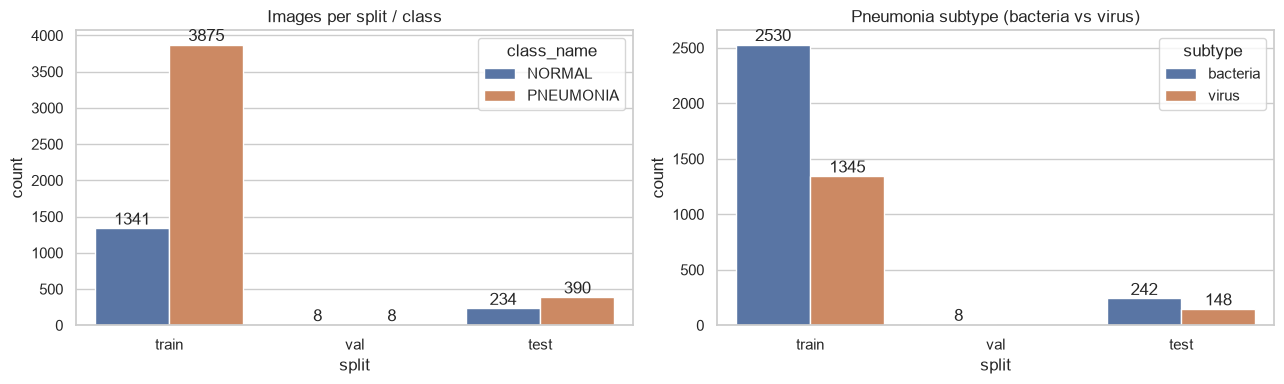

In [ ]:
##############################################################################
#데이터 분포 빈도수 표(교차표) 생성 및 비율 계산 
##############################################################################
# - margins=True 추가하여 합계 All 행 및 컬럼 생성
# - ) 하여 행의 순서 정의
count_tbl = pd.crosstab(df.split, df.class_name, margins=True).reindex(["train", "val", "test", "All"])
count_tbl["PNEUMONIA 비율"] = count_tbl["PNEUMONIA"] / count_tbl["All"] # 비율 컬럼 추가
display(count_tbl)

##############################################################################
#데이터 분포 그래프 시각화 및 수치 표시
##############################################################################
##도화지 준비: 1행 2열 형태의 그래프 공간(axes[0], axes[1])이 나란히 있는 가로 13인치, 세로 4인치 크기의 그림 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))  
#Seaborn 라이브러리의 countplot을 사용해 빈도수 막대그래프 그리기
## 왼쪽 그래프
sns.countplot(data=df, x="split", hue="class_name", order=["train", "val", "test"], ax=axes[0])
# - x="split": X축을 train, val, test 분할 기준
# - hue="class_name": 각 분할 안에서 클래스별로 색상을 다르게 하여 막대를 쪼개어 보여줍니다
# - order=[...]: X축에 표시될 항목의 순서를 지정합니다.
# - ax=axes[0] 두 개의 칸 중 첫 번째 칸(좌측)에 이 그래프를 그리도록 지정
axes[0].set_title("Images per split / class") # 칸(좌측)에 이 그래프 이름
for c in axes[0].containers: #숫자 라벨 달기: 
    axes[0].bar_label(c)     #- 그래프의 막대들 위에 실제 데이터 개수가 몇 개인지 숫자로 표시해 주는 반복문
## 오른쪽 그래프    
sns.countplot(data=df[df.label == 1], x="split", hue="subtype", order=["train", "val", "test"], ax=axes[1])
axes[1].set_title("Pneumonia subtype (bacteria vs virus)")
for c in axes[1].containers:
    axes[1].bar_label(c)
plt.tight_layout(); plt.show()

**관찰 & 시사점**

1. **클래스 불균형** : train 에서 PNEUMONIA 가 약 74%, NORMAL 이 약 26%(약 3:1). 그냥 학습하면 모델이 "대부분 폐렴"으로 예측해도 Accuracy 가 높게 나오므로 **Accuracy 만으로 평가하면 안 되고**, 손실함수에 **클래스 가중치**를 준다.
2. **공식 val 셋이 16장뿐** : 조기 종료·모델 선택에 쓰기에는 너무 작아 지표가 크게 흔들린다 → 4장에서 train+val 을 합쳐 **검증셋을 새로 구성**한다.
3. **test 셋 분포가 다름** : test 는 PNEUMONIA 비율이 약 62.5% 로 train(74%)보다 낮다. 검증셋 성능과 test 성능 사이에 차이가 생길 수 있음을 염두에 둔다.

### 3-2. 샘플 이미지와 이미지 크기 분포 확인

- 엑스레이 샘플을 통해 정상 폐는 검고 투명하게, 폐렴 폐는 **뿌연 음영(흰색 영역)**이 보이는지 직접 확인합니다.
- 촬영 자세, 밝기, 글자 마커, 가장자리 여백처럼 모델이 엉뚱하게 배울 수 있는 요소가 있는지 미리 봅니다

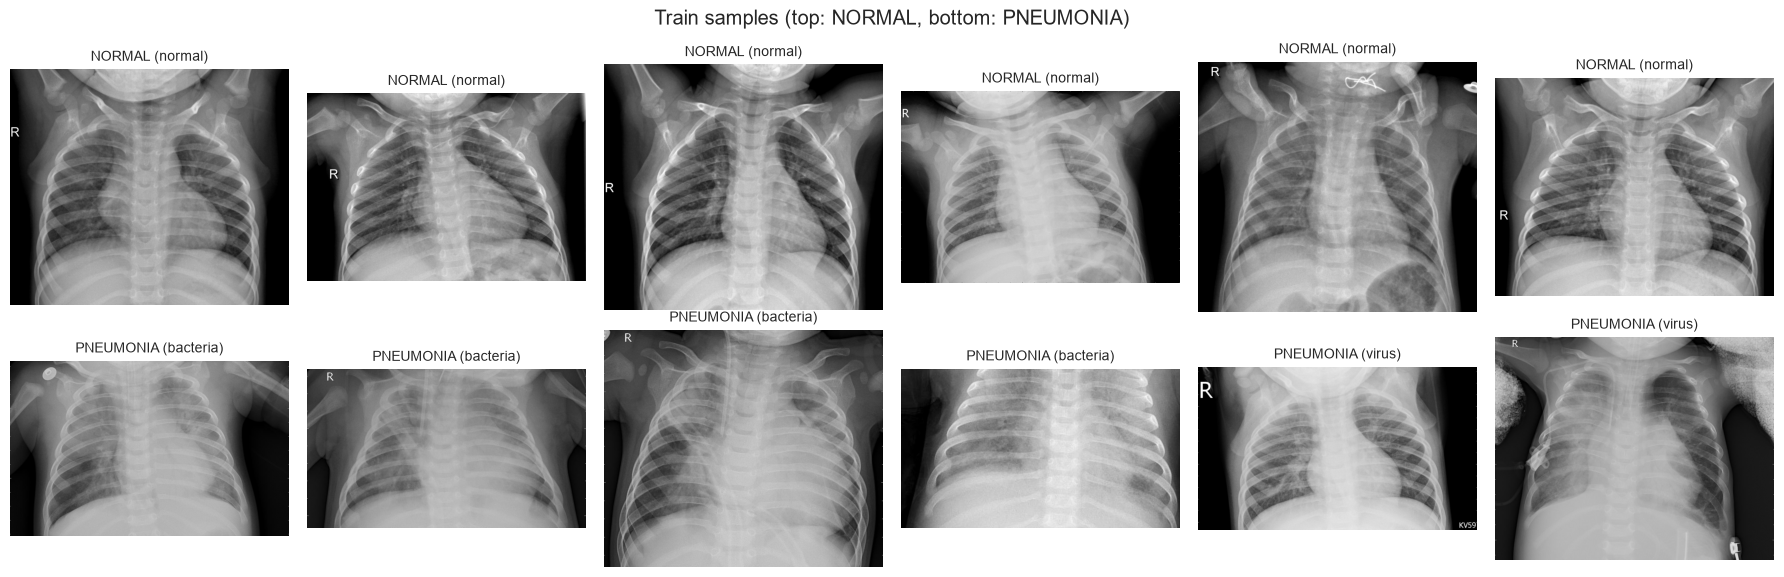

class_name      NORMAL  PNEUMONIA
width  count  300.0000   300.0000
       mean  1674.0000  1176.4000
       std    300.8000   269.6000
       min    984.0000   438.0000
       25%   1465.5000   988.5000
       50%   1640.0000  1140.0000
       75%   1841.2000  1360.0000
       max   2752.0000  2088.0000
height count  300.0000   300.0000
       mean  1359.5000   791.3000
       std    335.2000   257.5000
       min    496.0000   190.0000
       25%   1136.0000   624.0000
       50%   1287.0000   760.0000
       75%   1523.8000   912.0000
       max   2625.0000  1768.0000
aspect count  300.0000   300.0000
       mean     1.3000     1.5000
       std      0.2000     0.2000
       min      0.9000     1.0000
       25%      1.1000     1.4000
       50%      1.2000     1.5000
       75%      1.3000     1.7000
       max      2.1000     2.9000

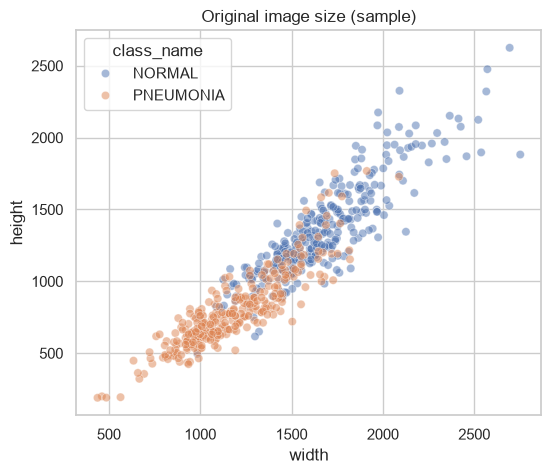

In [ ]:
##############################################################################
## 엑스레이 샘플을 통해 정상과 폐렴 영상 차이 및 모델이 엉뚱하게 배울 수 있는 요소 확인 
##############################################################################
# 2행 6열, 총 12칸의 그림판 생성. axes[0]이 윗줄, axes[1]이 아랫줄
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
#CLASS_NAMES = ["NORMAL", "PNEUMONIA"]이므로 r=0이면 NORMAL(윗줄), r=1이면 PNEUMONIA(아랫줄)
for r, cls in enumerate(CLASS_NAMES): #CLASS_NAMES 2가지 종류의 값이라 2회 반복
    samples = df[(df.split == "train") & (df.class_name == cls)].sample(6, random_state=r) #무작위로 6장 선택. random_state를 고정해서 다시 실행해도 같은 사진이 나옴(재현성)
    for ax, (_, row) in zip(axes[r], samples.iterrows()): #샘플 6개라서 6회 반복
        ax.imshow(Image.open(row.path).convert("L"), cmap="gray")
        ax.set_title(f"{cls} ({row.subtype})", fontsize=10); ax.axis("off")
plt.suptitle("Train samples (top: NORMAL, bottom: PNEUMONIA)"); plt.tight_layout(); plt.show()

##############################################################################
## 원본 이미지 크기 통계
##############################################################################
#df.groupby("class_name") 클래스별 300장 .sample 표본 추출
size_sample = pd.concat([g.sample(min(len(g), 300), random_state=0) for _, g in df.groupby("class_name")])
#.size 이미지 크기 읽기
sizes = np.array([Image.open(p).size for p in size_sample.path])
size_sample = size_sample.assign(width=sizes[:, 0], height=sizes[:, 1], aspect=sizes[:, 0] / sizes[:, 1])
#df.groupby("class_name")은 표를 NORMAL 묶음과 PNEUMONIA 묶음으로 나누고
#.describe(): 
# - 클래스마다 개수(count), 평균(mean), 표준편차(std), 최솟값(min), 사분위수(25%, 50%, 75%), 최댓값(max)을 계산
display(size_sample.groupby("class_name")[["width", "height", "aspect"]].describe().T.round(1))

##############################################################################
## 그래프로 이미지 크기 분포 검토
##############################################################################
fig, ax = plt.subplots(figsize=(6, 5))
#산점도의 점 하나가 이미지 한 장이고, x축은 가로, y축은 세로입니다.
sns.scatterplot(data=size_sample, x="width", y="height", hue="class_name", alpha=.5, ax=ax)
ax.set_title("Original image size (sample)")
plt.show()

**관찰** : 원본 해상도가 수백~2천 px 이상으로 제각각이고, 가로가 더 긴 이미지가 많다. 대부분 흑백(1채널)이다. NORMAL 과 PNEUMONIA 의 평균 해상도가 다르기도 한데, 모델이 **해상도 같은 부수 정보로 클래스를 맞히지 않도록** 모든 이미지를 같은 크기로 통일한다.

→ 전처리 방침 : **흑백 로드 → 256×256 리사이즈(캐시) → 학습 시 224×224 로 crop/resize → 3채널 복제 → ImageNet 평균/표준편차 정규화**

- 해상도가 수백~수천 px로 제각각: 모델 입력은 크기가 같아야 하므로 모두 같은 크기로 리사이즈 필요
- aspect가 1보다 큰 경우가 많음 (가로로 김): 정사각형으로 리사이즈하면 약간 찌그러짐. 모든 이미지에 똑같이 적용되므로 학습에 큰 문제는 없지만, 한계로 기록해 둘 점
- 클래스별 평균 해상도 차이: 차이가 크다면 모델이 **병변 대신 "사진 크기"로 클래스를 맞히는 지름길(shortcut)**을 배울 수 있음 → 크기 통일로 그 단서를 없앰
- 대부분 흑백: 흑백을 3채널로 복제해 ImageNet 모델 입력 형식에 맞춤

---
## 4. 데이터 분할 전략 — 환자 단위 분할

- 공식 `val`(16장)은 너무 작으므로 **train + val 을 합친 뒤** 약 85% / 15% 로 다시 나눈다.
- `StratifiedGroupKFold` 를 사용해
  - **Stratified** : train과 val 셋의 클래스 비율을 비슷하게 유지
  - **Group(환자)** : 같은 환자의 이미지는 한쪽에만 들어가게 해서 누수를 막는다
- 공식 `test`(624장)는 **최종 평가 전까지 한 번도 사용하지 않는다** (모델 선택·임계값 조정 모두 검증셋으로만 수행).
- 기타 데이터 누수 방지
    - 모든 이미지를 같은 크기로 리사이즈해서 해상도 단서를 제거 (5장)


In [ ]:
##########################################################################
## 학습, 검증, 테스트 데이터 나누기
## 목적: 검증셋이 학습셋과 같은 분포를 갖도록 해서 검증 점수 신뢰도를 만드는 것
##########################################################################
# dev_df: 원래 train 폴더와 val 폴더(16장)를 합친 것. 
# 이것을 새로 나눠 학습용과 검증용을 만듭니다.
dev_df = df[df.split.isin(["train", "val"])].reset_index(drop=True) #행 번호를 0부터 다시 매김
# 테스트 폴더의 자료는 다시 나누지 않고 그대로 최종 평가에만 사용
test_df = df[df.split == "test"].reset_index(drop=True) #행 번호를 0부터 다시 매깁니다. 다음 단계에서 행 번호(위치)로 데이터를 골라내기 때문입니다.

## StratifiedGroupKFold 클래스 이용하여 나누기
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=CFG["seed"])
# - 객체생성 시 n_splits=7	-> 데이터를 7조각(fold)으로 나누는 파라미터 적용. 한 조각은 1/7 ≈ 14%
tr_idx, va_idx = next(sgkf.split(dev_df, dev_df.label, groups=dev_df.patient))
# - split(X, y, groups): y=label로 클래스 비율을 맞추고, groups=patient로 같은 환자는 같은 그룹처리
train_df = dev_df.iloc[tr_idx].reset_index(drop=True)
# - iloc[행 번호]로 실제 학습표와 검증표를 만듭니다.
val_df = dev_df.iloc[va_idx].reset_index(drop=True)

overlap = set(train_df.patient) & set(val_df.patient)
# - 두 표의 환자 ID 집합의 **교집합(&)**이 비어 있는지 확인합니다.
assert len(overlap) == 0, "환자 누수 발생!"
# - 겹치면 assert가 에러를 내고 멈춥니다.

split_summary = pd.DataFrame({
    # 1. 딕셔너리 키-값 형태를 정의하고
    name: {"images": len(data), "patients": data.patient.nunique(),
           "NORMAL": (data.label == 0).sum(), "PNEUMONIA": (data.label == 1).sum(),
           "PNEUMONIA 비율": data.label.mean()
           }
    # 2. 그 뒤에 for문이 돕니다.
    for name, data in [("train", train_df), ("val(new)", val_df), ("test", test_df)]
}).T
# -split_summary: 세 셋의 이미지 수, 환자 수, 클래스별 개수, 폐렴 비율을 한 표로 보여 줍니다.
display(split_summary)
print("train/val 환자 중복:", len(overlap), "명 → 누수 없음")

## 각 데이터셋의 y 정답값만 저장
y_train, y_val, y_test = (d.label.values.astype(np.int64) for d in (train_df, val_df, test_df))
# - d.label: 데이터프레임에서 label 열(Column)을 선택합니다. (판다스 Series 형태)
# - .values: 판다스(Pandas)의 인덱스나 부가 정보를 걷어내고, 오직 숫자 데이터만 들어있는 넘파이(NumPy) 배열(Array)로 변환

,images,patients,NORMAL,PNEUMONIA,PNEUMONIA 비율
train,4484.0000,2509.0000,1156.0000,3328.0000,0.7422
val(new),748.0000,419.0000,193.0000,555.0000,0.7420
test,624.0000,431.0000,234.0000,390.0000,0.6250


train/val 환자 중복: 0 명 → 누수 없음


- 분할 전 dev 데이터: NORMAL 약 26%, PNEUMONIA 약 74%
- 분할 후 train_df: 약 26% : 74% (PNEUMONIA 비율 기존 74% 동일)
- 분할 후 val_df: 약 26% : 74% (PNEUMONIA 비율 기존 50%에서 74%로 학습데이터와 동일하게 적용)

In [122]:
display(val_df) 
display(y_val)

,path,split,class_name,label,subtype,patient
0,data\train\NORMAL\IM-0117-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0117
1,data\train\NORMAL\IM-0127-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0127
2,data\train\NORMAL\IM-0129-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0129
3,data\train\NORMAL\IM-0135-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0135
4,data\train\NORMAL\IM-0149-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0149
...,...,...,...,...,...,...
743,data\train\PNEUMONIA\person990_bacteria_2917.jpeg,train,PNEUMONIA,1,bacteria,PNEUMONIA_person990
744,data\train\PNEUMONIA\person994_bacteria_2922.jpeg,train,PNEUMONIA,1,bacteria,PNEUMONIA_person994
745,data\train\PNEUMONIA\person994_virus_1672.jpeg,train,PNEUMONIA,1,virus,PNEUMONIA_person994
746,data\val\NORMAL\NORMAL2-IM-1436-0001.jpeg,val,NORMAL,0,normal,NORMAL_NORMAL2-IM-1436


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [101]:
display(train_df)
display(val_df)
dev_df[dev_df['split']=='val']


,path,split,class_name,label,subtype,patient
0,data\train\NORMAL\IM-0115-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0115
1,data\train\NORMAL\IM-0119-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0119
2,data\train\NORMAL\IM-0122-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0122
3,data\train\NORMAL\IM-0125-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0125
4,data\train\NORMAL\IM-0128-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0128
...,...,...,...,...,...,...
4479,data\val\PNEUMONIA\person1949_bacteria_4880.jpeg,val,PNEUMONIA,1,bacteria,PNEUMONIA_person1949
4480,data\val\PNEUMONIA\person1950_bacteria_4881.jpeg,val,PNEUMONIA,1,bacteria,PNEUMONIA_person1950
4481,data\val\PNEUMONIA\person1951_bacteria_4882.jpeg,val,PNEUMONIA,1,bacteria,PNEUMONIA_person1951
4482,data\val\PNEUMONIA\person1952_bacteria_4883.jpeg,val,PNEUMONIA,1,bacteria,PNEUMONIA_person1952


,path,split,class_name,label,subtype,patient
0,data\train\NORMAL\IM-0117-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0117
1,data\train\NORMAL\IM-0127-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0127
2,data\train\NORMAL\IM-0129-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0129
3,data\train\NORMAL\IM-0135-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0135
4,data\train\NORMAL\IM-0149-0001.jpeg,train,NORMAL,0,normal,NORMAL_IM-0149
...,...,...,...,...,...,...
743,data\train\PNEUMONIA\person990_bacteria_2917.jpeg,train,PNEUMONIA,1,bacteria,PNEUMONIA_person990
744,data\train\PNEUMONIA\person994_bacteria_2922.jpeg,train,PNEUMONIA,1,bacteria,PNEUMONIA_person994
745,data\train\PNEUMONIA\person994_virus_1672.jpeg,train,PNEUMONIA,1,virus,PNEUMONIA_person994
746,data\val\NORMAL\NORMAL2-IM-1436-0001.jpeg,val,NORMAL,0,normal,NORMAL_NORMAL2-IM-1436


,path,split,class_name,label,subtype,patient
5216,data\val\NORMAL\NORMAL2-IM-1427-0001.jpeg,val,NORMAL,0,normal,NORMAL_NORMAL2-IM-1427
5217,data\val\NORMAL\NORMAL2-IM-1430-0001.jpeg,val,NORMAL,0,normal,NORMAL_NORMAL2-IM-1430
5218,data\val\NORMAL\NORMAL2-IM-1431-0001.jpeg,val,NORMAL,0,normal,NORMAL_NORMAL2-IM-1431
5219,data\val\NORMAL\NORMAL2-IM-1436-0001.jpeg,val,NORMAL,0,normal,NORMAL_NORMAL2-IM-1436
5220,data\val\NORMAL\NORMAL2-IM-1437-0001.jpeg,val,NORMAL,0,normal,NORMAL_NORMAL2-IM-1437
5221,data\val\NORMAL\NORMAL2-IM-1438-0001.jpeg,val,NORMAL,0,normal,NORMAL_NORMAL2-IM-1438
5222,data\val\NORMAL\NORMAL2-IM-1440-0001.jpeg,val,NORMAL,0,normal,NORMAL_NORMAL2-IM-1440
5223,data\val\NORMAL\NORMAL2-IM-1442-0001.jpeg,val,NORMAL,0,normal,NORMAL_NORMAL2-IM-1442
5224,data\val\PNEUMONIA\person1946_bacteria_4874.jpeg,val,PNEUMONIA,1,bacteria,PNEUMONIA_person1946
5225,data\val\PNEUMONIA\person1946_bacteria_4875.jpeg,val,PNEUMONIA,1,bacteria,PNEUMONIA_person1946


**결과** : 새 검증셋은 수백 장 규모로 커져 조기 종료·모델 선택 지표가 안정되고, train 과 비슷한 클래스 비율을 가진다. 환자 중복이 0 이므로 검증 점수가 누수로 부풀려지지 않는다.

---
## 5. 이미지 전처리 & 증강

### 5-1. 메모리 캐시 + CLAHE 전처리
- 원본 JPEG 는 크고 디코딩이 느리므로, **흑백으로 한 번만 읽어 256×256 으로 줄인 뒤 메모리에 캐시**한다(약 6천 장 × 64KB ≈ 0.4GB). 매 epoch 디스크 I/O 가 사라져 여러 실험을 빠르게 반복할 수 있다.
- **CLAHE(Contrast Limited Adaptive Histogram Equalization)** : 이미지를 작은 타일로 나눠 타일별로 대비를 높인다. X-ray 는 촬영 장비·노출에 따라 밝기/대비 편차가 크고, 폐렴은 폐 영역의 **음영(opacity)** 으로 나타나므로 국소 대비를 높이면 도움이 되는지 실험 2에서 확인한다.

In [ ]:
## 이미지 한 장 읽기: load_gray
def load_gray(path, size=CFG["cache_size"]):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    # - JPEG를 열어 흑백 1채널 배열로 읽음 (값 0~255, uint8)(X-ray는 원래 흑백이라 정보 손실 없음)
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA) 
    # - 원본(1,000~2,000px 이상)을 상수에서 정한 값 256×256으로 축소( 크기 통일 및 메모리 절약)
    # - interpolation=cv2.INTER_AREA : 축소할 때 주변 픽셀을 평균 내는 방식

## load_gray를 이용해 여러 장을 병렬로 읽기: load_all
def load_all(paths):
    with ThreadPoolExecutor(max_workers=8) as ex: #스레드 8개가 동시에 파일을 읽고 줄입니다
        return np.stack(list(ex.map(load_gray, paths)))
        #경로마다 load_gray를 실행합니다. 결과는 입력 순서 그대로 돌려줍니다.

t0 = time.time()
## 3개의 DataFrame 표의 경로정보를 통해 이미지를 load_gray로 읽어 메모리에 캐시로 저장합니다.
# 메모리 사용량: 한 장은 256×256 = 65,536바이트(약 64KB, uint8 1바이트 × 픽셀 수)입니다. 
# 약 5,900장이면 약 380MB이고, 아래 CLAHE 사본까지 합치면 약 770MB입니다.
X_train_raw = load_all(train_df.path.tolist())
X_val_raw = load_all(val_df.path.tolist())
X_test_raw = load_all(test_df.path.tolist())
print(f"캐시 완료 {time.time()-t0:.1f}s | train {X_train_raw.shape}, val {X_val_raw.shape}, test {X_test_raw.shape}")
print(f"메모리: {(X_train_raw.nbytes + X_val_raw.nbytes + X_test_raw.nbytes)/1e6:.0f} MB")


## CLAHE 버전 만들기 
# Contrast Limited Adaptive Histogram Equalization : 대비 제한 적응형 히스토그램 평활화
# 설명: 의료 영상(X-ray, CT 등)이나 어두운 이미지의 명암 대비(Contrast)를 자연스럽게 개선
# 목적: 입력 품질 개선, 밝기 편차 통일
# 시점: 학습 전 한 번 (오프라인)
# 대상: train, val, test 모두
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# - 256×256 이미지를 8×8 = 64개 타일(각 32×32px)로 나눠 타일별로 대비를 높이되, 증폭 상한은 2.0
def apply_clahe(arr):
    return np.stack([_clahe.apply(a) for a in arr])
    # - _clahe.apply(a)	이미지 한 장에 CLAHE 적용
    # - 리스트 컴프리헨션 + np.stack : 모든 이미지에 적용한 뒤 다시 (N, 256, 256) 배열로 쌓음

X_train_clahe, X_val_clahe, X_test_clahe = map(apply_clahe, (X_train_raw, X_val_raw, X_test_raw))
#  -      # - map(apply_clahe, (...)): train, val, test 세 셋 모두에 똑같이 적용

# 전처리 방식별 (train, val, test) 이미지 묶음
IMAGES = {"raw": (X_train_raw, X_val_raw, X_test_raw),
          "clahe": (X_train_clahe, X_val_clahe, X_test_clahe)}

캐시 완료 13.2s | train (4484, 256, 256), val (748, 256, 256), test (624, 256, 256)
메모리: 384 MB


- 왜 일반 히스토그램 평활화(HE) 대신 CLAHE를 쓸까요?
    - 기존 방식 (Histogram Equalization): 이미지 전체의 밝기 분포를 분석해 골고루 펼쳐줍니다. 하지만 이미지의 특정 부분만 너무 밝거나 어두우면, 사진 전체가 하얗게 타버리거나(Over-amplification) 노이즈가 심해지는 치명적인 단점이 있습니다.
    - CLAHE 방식: 이 문제를 해결하기 위해 이미지를 작은 구역(정사각형 타일)으로 쪼개서 각 구역별로 명암을 맞추고, 대비가 너무 심하게 튀는 부분은 강제로 제한(Contrast Limited)하여 부드럽고 자연스러운 이미지를 만들어 줍니다.
- 폐렴(X-ray) 데이터셋에서 CLAHE가 필수적인 이유
    - 흉부 엑스레이 사진은 촬영 장비나 환자의 체격, 호흡 정도에 따라 하얗게 흐리거나 너무 어둡게 찍히는 경우가 많습니다.
    - CLAHE를 적용하면 갈비뼈 뒷면에 숨어있는 미세한 폐렴 염증(Infiltration)이나 음영 변화를 선명하게 부각시킬 수 있어, AI 모델의 분류 성능을 올리는 데 매우 효과적입니다.

In [117]:
print(train_df.path.tolist()[:5])
print(X_train_raw[:3])

['data\\train\\NORMAL\\IM-0115-0001.jpeg', 'data\\train\\NORMAL\\IM-0119-0001.jpeg', 'data\\train\\NORMAL\\IM-0122-0001.jpeg', 'data\\train\\NORMAL\\IM-0125-0001.jpeg', 'data\\train\\NORMAL\\IM-0128-0001.jpeg']
[[[ 23  20  19 ...  95  95  95]
  [ 22  22  19 ...  94  95  95]
  [ 23  22  20 ...  94  94  94]
  ...
  [ 30  29  29 ...  66  67  66]
  [ 36  36  36 ...  85  86  87]
  [ 47  47  47 ... 112 114 114]]

 [[  0   0   0 ...  12   0   0]
  [  0   0   0 ...   7   0   0]
  [  0   0   0 ...   3   0   0]
  ...
  [  0   0   0 ...   0   1   1]
  [  0   0   0 ...   0   1   1]
  [  0   0   0 ...   0   0   2]]

 [[ 39  44  47 ...  20  21  22]
  [ 39  43  48 ...  20  20  21]
  [ 37  43  46 ...  20  20  22]
  ...
  [ 16  17  18 ...  11  11  11]
  [ 15  15  15 ...  11  11  12]
  [ 15  16  15 ...  11  12  11]]]


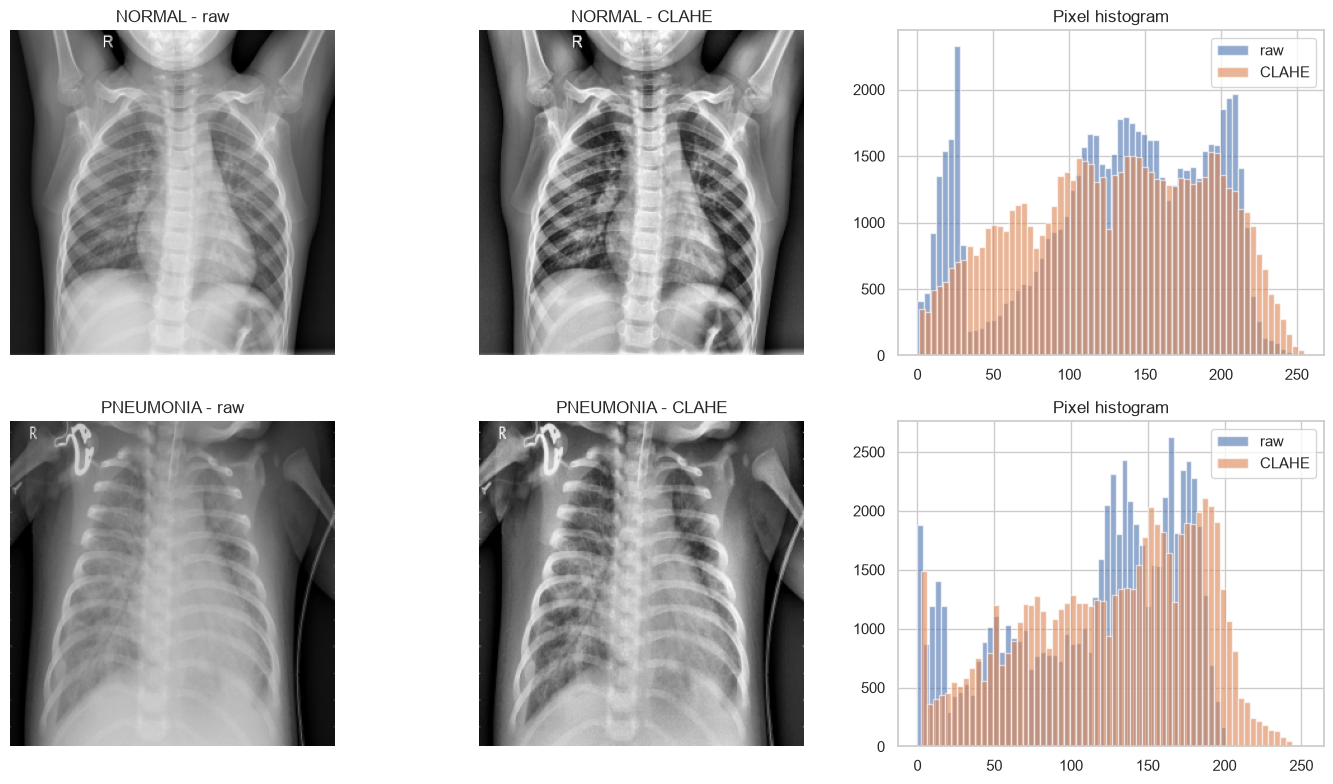

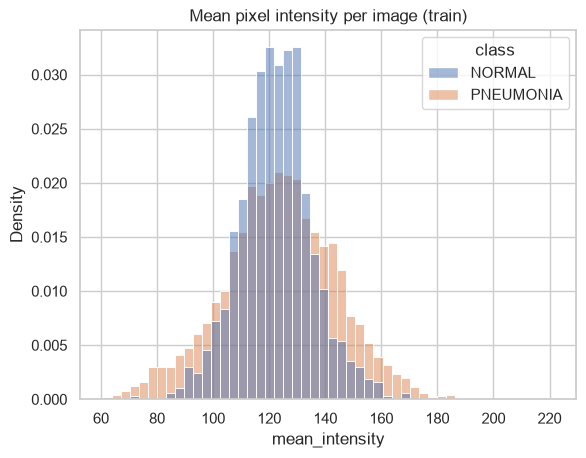

In [ ]:
#################################################################################
## 원본과 CLAHE 비교 그림
#################################################################################

idx = [int(np.where(y_train == 0)[0][0]), int(np.where(y_train == 1)[0][0])]
# - np.where(y_train == 0)은 정답이 NORMAL인 위치 목록이고, [0][0]은 그중 첫 번째 위치입니다. 
# - 결과는 NORMAL 1장과 PNEUMONIA 1장의 위치입니다.

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
# - 2행(NORMAL, PNEUMONIA) × 3열(원본 / CLAHE / 히스토그램)입니다.
for r, i in enumerate(idx):
    axes[r, 0].imshow(X_train_raw[i], cmap="gray"); axes[r, 0].set_title(f"{CLASS_NAMES[y_train[i]]} - raw")
    axes[r, 1].imshow(X_train_clahe[i], cmap="gray"); axes[r, 1].set_title(f"{CLASS_NAMES[y_train[i]]} - CLAHE")
    axes[r, 2].hist(X_train_raw[i].ravel(), bins=64, alpha=.6, label="raw")
    #- .ravel()은 256×256 배열을 65,536개 값의 1차원 목록으로 펴서
    #- bins=64로 밝기 0~255를 64구간으로 나눠 셉니다
    #- alpha=.6으로 반투명하게 겹쳐 그려 두 분포를 비교
    axes[r, 2].hist(X_train_clahe[i].ravel(), bins=64, alpha=.6, label="CLAHE")
    axes[r, 2].legend(); axes[r, 2].set_title("Pixel histogram")
    axes[r, 0].axis("off"); axes[r, 1].axis("off")
plt.tight_layout(); plt.show()

# 클래스별 평균 밝기 분포
# - 목적: 두 클래스의 평균 밝기 분포가 크게 겹치면 "밝기만으로는 구분할 수 없다", 
#        즉 모델이 음영의 위치와 모양 같은 공간 패턴을 배워야 한다는 근거가 됩니다. 
#        반대로 확연히 갈리면 모델이 밝기라는 지름길을 쓸 위험이 있다는 신호입니다.
mean_int = pd.DataFrame({"mean_intensity": X_train_raw.reshape(len(X_train_raw), -1).mean(1),
                         "class": np.array(CLASS_NAMES)[y_train]})
    #- reshape(N, -1): 각 이미지를 한 줄로 펴서 (N, 65,536) 모양으로 만듭니다.
    #- .mean(1)은 이미지마다 평균 밝기 하나를 계산합니다.
    #- np.array(CLASS_NAMES)[y_train]: 0/1 레이블을 "NORMAL"/"PNEUMONIA" 글자로 바꿉니다.
sns.histplot(data=mean_int, x="mean_intensity", hue="class", bins=50, stat="density", common_norm=False)
#- stat="density", common_norm=False: 클래스마다 따로 넓이가 1이 되도록 정규화합니다
plt.title("Mean pixel intensity per image (train)"); plt.show()

**결과** : CLAHE 를 적용하면 히스토그램이 넓게 퍼지고 폐 내부의 혈관·음영 구조가 더 또렷해진다. 클래스별 평균 밝기 분포는 상당 부분 겹쳐서, 단순 밝기만으로는 분류가 어렵고 **공간적 패턴(음영의 위치·모양)** 을 학습해야 함을 보여준다.



### 5-2. 증강(Augmentation) 정책
의료 영상은 "현실에서 일어날 수 있는 변형"만 적용해야 한다.

| 정책 | 구성 | 의도 |
|---|---|---|
| `none` | Resize(224) | 증강 없음 (비교 기준) |
| `light` | RandomResizedCrop(0.85~1.0), 회전 ±7°, 밝기/대비 ±10% | 촬영 위치·노출의 작은 차이 모사 |
| `strong` | RandomResizedCrop(0.7~1.0), Affine(회전 ±10°, 이동 5%, 확대 ±10%, shear 5°), 밝기/대비 ±20%, 가우시안 블러, RandomErasing | 더 강한 규제(regularization) → 과적합 억제 |

- **좌우 반전(HorizontalFlip)·상하 반전은 사용하지 않는다.** 심장은 왼쪽에 있어 좌우 반전은 해부학적으로 존재하지 않는 영상을 만들고, 상하 반전은 X-ray 에서 발생하지 않는다.
- 흑백 이미지를 **3채널로 복제**해 ImageNet 사전학습 모델의 입력 형식(RGB)에 맞추고, ImageNet 평균/표준편차로 정규화한다.

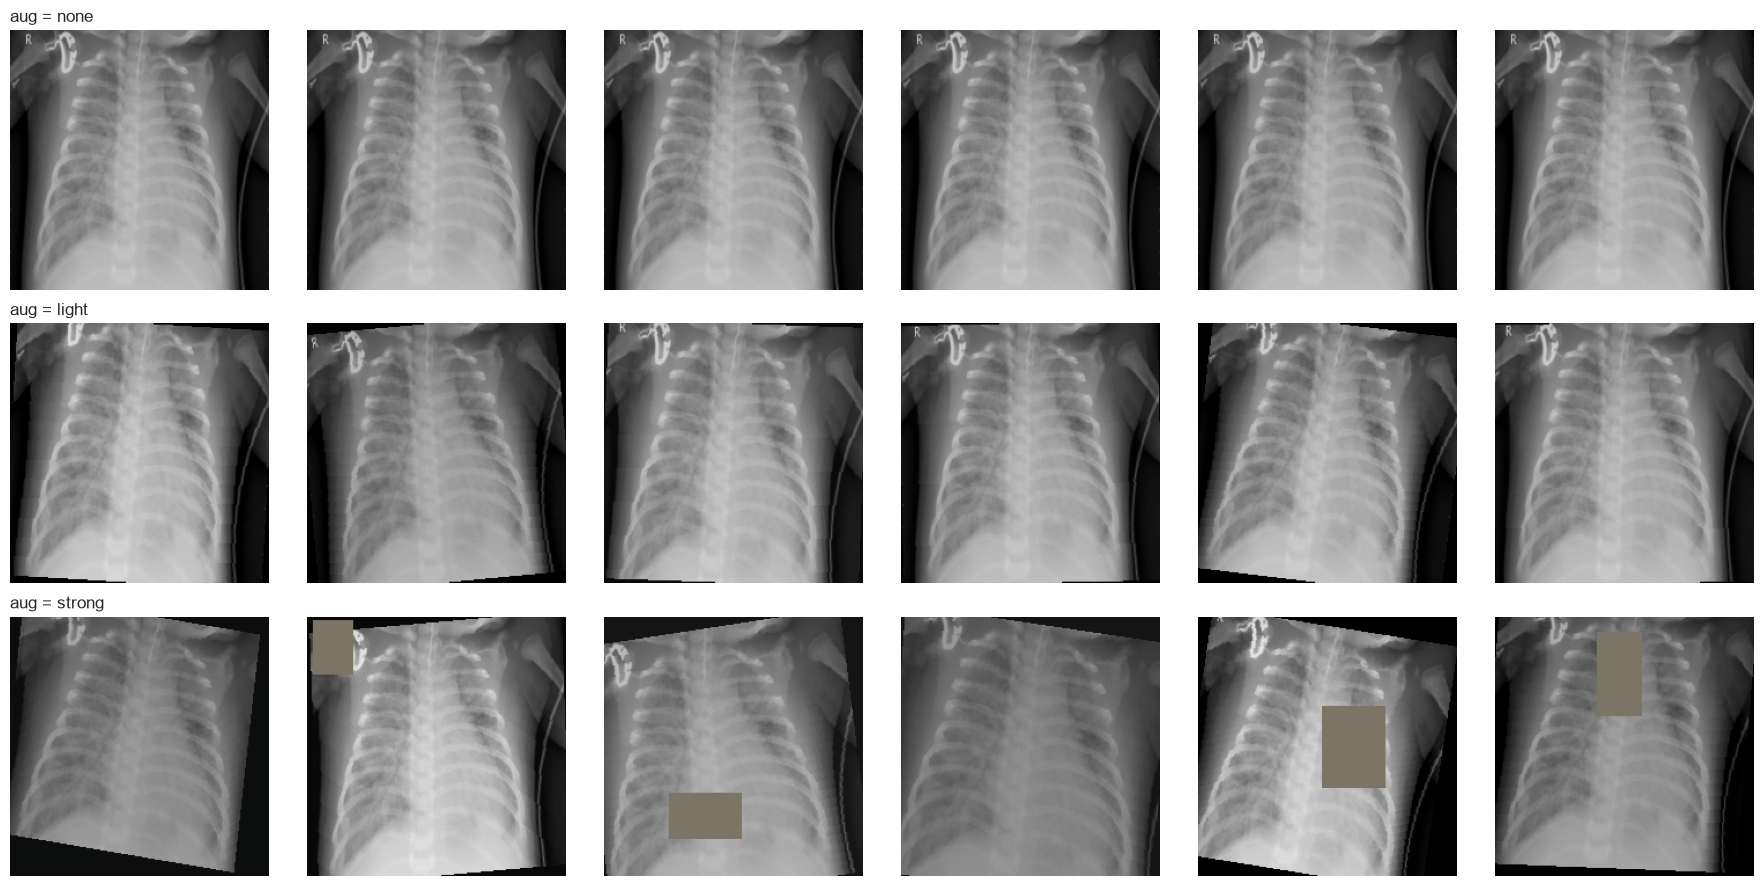

In [ ]:
############################################################################
## 데이터 증강
############################################################################
## 공통 설정
#########################
IMG = CFG["img_size"] #모델 입력 크기 224. 여러 곳에서 쓰므로 변수로 뽑아 둠
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225] #ImageNet 이미지들의 채널별(R, G, B) 평균과 표준편차.
#모든 정책의 마지막에 공통으로 붙는 두 단계를 리스트로 묶어 둔 것
to_tensor_norm = [T.ToTensor(), T.Normalize(MEAN, STD)] 
#- 모든 정책의 공통 마무리 (텐서 변환 + ImageNet 정규화)

## 평가용 변환 eval_tf와 none
eval_tf = T.Compose([T.Resize((IMG, IMG))] + to_tensor_norm)
#- T.Compose([...]): 리스트에 든 변환을 순서대로 이어서 적용하는 하나의 변환을 만듭니다.
#- [Resize] + to_tensor_norm: 파이썬 리스트 덧셈으로 [Resize, ToTensor, Normalize] 세 단계가 됩니다.
#- 무작위 요소가 없어서, 같은 이미지를 넣으면 항상 같은 결과가 나옵니다. 그래서 검증과 테스트에 씁니다.

############################################
## 증강 정책 딕셔너리 AUGS
############################################
#- 딕셔너리로 만든 이유: 실험마다 aug="light"처럼 이름만 바꿔서 정책을 선택하기 위함
#- run_experiment 안의 AUGS[aug]
AUGS = {
    #none은 eval_tf와 같은 객체를 그대로 사용
    "none": eval_tf,
    
    #순서: 크롭, 회전, 밝기 같은 변환은 PIL 이미지 단계에서 합니다(ToTensor 앞).
    "light": T.Compose([
        #RandomResizedCrop: 이미지를 무작귀로 잘라내고(Crop) 크기를 조절(Resize)
        T.RandomResizedCrop(IMG, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
        #- IMG: 최종적으로 출력될 이미지의 크기(가로, 세로 픽셀 수)를 지정 - 224를 넣으면 (224, 224) 크기로.
        #- scale=(0.85, 1.0): 원본 이미지에서 어느 정도 면적 비율로 잘라낼지(Crop) 범위를 결정
        #---- 원본 면적의 85% ~ 100% 사이를 무작위
        #- ratio=(0.9, 1.1): 잘라낼 영역의 종횡비(Aspect Ratio, 가로/세로 비율) 범위
        #---- 0.9에서 1.1 사이의 무작위 비율로 가로나 세로를 살짝 늘리거나 줄입니다
        #RandomRotation: 파이토치(Torchvision)에서 제공하는 이미지 회전 데이터 증강 기법
        T.RandomRotation(7),
        #- 이미지를 최소 -7도에서 최대 +7도 사이의 무작위 각도로 회전시키는 코드
        #ColorJitter는 이미지의 밝기(Brightness), 대비(Contrast), 채도(Saturation), 색조(Hue)를 무작위로 변경
        T.ColorJitter(brightness=0.1, contrast=0.1),
        #- brightness=0.1 원본 이미지의 밝기를 기존의 90%(1.0 - 0.1) ~ 110%(1.0 + 0.1) 사이의 무작위 값으로 변경
        #- contrast=0.1 (명암 대비 조절) 90% ~ 110% 사이에서 무작위로 변경
    ] + to_tensor_norm),
    #순서: 크롭, 회전, 밝기 같은 변환은 PIL 이미지 단계에서 합니다(ToTensor 앞).
    "strong": T.Compose([
        T.RandomResizedCrop(IMG, scale=(0.7, 1.0), ratio=(0.85, 1.15)),
        #- 크기는 RandomResizedCrop(IMG, ...)가 최종적으로 224×224로 만들어 주므로, 
        #- light와 strong에는 따로 Resize가 없습니다.        
        T.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9, 1.1), shear=5),
        T.ColorJitter(brightness=0.2, contrast=0.2),
        T.RandomApply([T.GaussianBlur(3, sigma=(0.1, 1.0))], p=0.2),
        #- 가우시안 블러(Gaussian Blur)는 이미지의 노이즈를 제거하거나 부드럽게(흐리게) 만들 때 사용하는 필터
        #- 3 (Kernel Size): 이미지를 흐리게 만들 때 참고할 주변 영역(커널)의 크기를 의미
        #- sigma=(0.1, 1.0): 흐림 효과의 '강도(표준편차)'를 결정하는 범위
        #- T.RandomApply([변환], p=0.2): 안의 변환을 20% 확률로만 적용하는 포장 변환입니다.
        #---- 즉, 데이터셋에서 이미지 10장을 꺼내 모델에 입력하면, 
        #---- 그중 평균 2장 정도만 가우시안 블러가 켜져서 흐릿하게 들어가고, 나머지 8장은 원본 그대로 선명하게 들어갑니다.

    ] + to_tensor_norm + [T.RandomErasing(p=0.25, scale=(0.02, 0.08))]),
            #- RandomErasing은 텐서에만 동작하므로 맨 뒤에 둡니다.
}
############################################
## Dataset 클래스: 이미지 한 장을 꺼내 주는 규칙
############################################
class XrayDataset(Dataset):
    """메모리에 캐시된 흑백 배열 → PIL(RGB 3채널) → transform."""
    def __init__(self, images, labels, transform): #객체 초기 값 #- X_train_raw, y_train
        self.images, self.labels, self.transform = images, labels, transform
    def __len__(self): # 전체 이미지 수 반환
        return len(self.images)
    def __getitem__(self, i): # "i번째를 어떻게 꺼내는지 정의
        img = Image.fromarray(self.images[i]).convert("RGB")
        return self.transform(img), int(self.labels[i])
############################################
## DataLoader 생성 함수: 배치로 묶어 공급
############################################
# CFG = {
#     "seed": 42,
#     "cache_size": 256,          # 디스크 → 메모리 캐시할 때의 해상도
#     "img_size": 224,            # 모델 입력 해상도 (ImageNet 표준)
#     "batch_size": 32,
#     "num_workers": 0 if os.name == "nt" else 2,
#     "patience": 4,              # EarlyStopping patience (val loss 기준)
#     "epochs": {"baseline": 15, "aug": 8, "frozen": 10, "partial": 12, "full": 12, "improved": 15},
# }
# make_loader 배치로 묶고 섞어서 모델에 공급
def make_loader(images, labels, tf, shuffle):
    # XrayDataset 꺼낼 때마다 실시간 그 자리에서 무작위 증강 적용
    return DataLoader(XrayDataset(images, labels, tf), batch_size=CFG["batch_size"], shuffle=shuffle,
                      num_workers=CFG["num_workers"], pin_memory=device.type == "cuda",
                      persistent_workers=CFG["num_workers"] > 0)
#- num_workers	증강을 별도 프로세스 여러 개가 병렬로 처리해 GPU가 기다리지 않게 함. Windows 노트북에서는 에러 때문에 0
#- pin_memory	GPU를 쓸 때 CPU에서 GPU로 데이터를 옮기는 속도를 높이는 옵션
#- persistent_workers	epoch가 끝나도 작업 프로세스를 유지해 매 epoch 다시 만드는 비용을 줄임
#
############################################
## 시각화: 정책별 결과 확인
#- 정규화된 텐서는 값이 음수도 있어 그대로 그릴 수 없으므로, 정규화를 거꾸로 되돌리는 함수입니다.
############################################
def denorm(t):
    return (t.permute(1, 2, 0).numpy() * STD + MEAN).clip(0, 1)
#- permute(1, 2, 0): (채널, 높이, 너비)를 matplotlib이 쓰는 (높이, 너비, 채널) 순서로 바꿉니다.
#- * STD + MEAN: Normalize의 역연산입니다.
#- .clip(0, 1): 계산 오차로 0~1을 벗어난 값을 잘라냅니다.

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
#- 3행(none, light, strong) × 6열 구성으로, 같은 이미지에 같은 정책을 6번 적용합니다.
sample_img = Image.fromarray(X_train_raw[idx[1]]).convert("RGB")
#- idx[1]은 5-1에서 고른 첫 번째 PNEUMONIA 이미지입니다. 
#- 같은 사진 한 장으로 비교해서 정책 차이 비교.
for r, name in enumerate(["none", "light", "strong"]):
    for c in range(6):
        axes[r, c].imshow(denorm(AUGS[name](sample_img))); axes[r, c].axis("off")
    axes[r, 0].set_title(f"aug = {name}", loc="left", fontsize=12)
plt.tight_layout(); plt.show()

- none 줄의 6장은 모두 같습니다(무작위 요소 없음).
- light 줄은 조금씩 다름
- strong 줄은 더 크게 다름. 회전 모서리의 검은 영역, 흐림, 회색 사각형(RandomErasing)도 보입니다.

### 5-3. 클래스 불균형 대응 — 가중 손실함수
`weight_c = N / (2 × N_c)` 로 적은 클래스(NORMAL)의 손실에 더 큰 가중치를 준다. 샘플을 버리는 언더샘플링과 달리 데이터를 모두 활용하면서, 모델이 다수 클래스(PNEUMONIA)로 쏠리는 것을 막는다.

In [106]:
display(split_summary)

,images,patients,NORMAL,PNEUMONIA,PNEUMONIA 비율
train,4484.0000,2509.0000,1156.0000,3328.0000,0.7422
val(new),748.0000,419.0000,193.0000,555.0000,0.7420
test,624.0000,431.0000,234.0000,390.0000,0.6250


In [16]:
counts = np.bincount(y_train, minlength=2)
class_weights = torch.tensor(len(y_train) / (2 * counts), dtype=torch.float32, device=device)
print("train 클래스 수:", dict(zip(CLASS_NAMES, counts)))
print("클래스 가중치  :", dict(zip(CLASS_NAMES, class_weights.cpu().numpy().round(3))))

train 클래스 수: {'NORMAL': np.int64(1156), 'PNEUMONIA': np.int64(3328)}
클래스 가중치  : {'NORMAL': np.float32(1.939), 'PNEUMONIA': np.float32(0.674)}


- 학습 설계 시 손실 함수(Loss Function)에 적용
    - 예> 
        - criterion = nn.CrossEntropyLoss(weight=class_weights,label_smoothing=label_smoothing)
        - eval_crit = nn.CrossEntropyLoss(weight=class_weights)  

---
## 6. 학습 / 평가 공통 유틸

### 6-1. 평가 지표
양성 = 폐렴(1) 기준으로 계산한다.

| 지표 | 식 | 의미 (이 문제에서) |
|---|---|---|
| Accuracy | (TP+TN)/전체 | 전체 정답률. **불균형 데이터에서는 과대평가**되기 쉬움 |
| Precision | TP/(TP+FP) | "폐렴"이라 한 것 중 진짜 폐렴 비율. 낮으면 정상인을 불필요하게 추가검사 |
| **Recall (Sensitivity)** | TP/(TP+FN) | 실제 폐렴 중 찾아낸 비율. **낮으면 환자를 놓침 → 의료에서 가장 중요** |
| Specificity | TN/(TN+FP) | 실제 정상 중 정상으로 맞힌 비율 (NORMAL 의 recall) |
| F1-score | Precision·Recall 조화평균 | 두 지표의 균형 |
| ROC-AUC | 임계값 전 구간 | 임계값과 무관한 **순위(판별) 능력**. 모델 자체의 분리 능력 비교에 적합 |

In [ ]:
#########################################################################################
## 평가 지표 함수
#########################################################################################
def compute_metrics(y, p, thr=0.5): #(y= 정답, p=모델의 예측값, thr=확율을 자를 기준)
    pred = (p >= thr).astype(int) #예측 확률을 int클래스로 바꿉니다. 예를 들어 0.73이면 1(폐렴), 0.21이면 0(정상)입니다.
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel() 
                         #- .ravel() 메서드는 다차원 배열을 1차원 배열로 평평하게 펴주는(flatten) 함수
    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        #- zero_division=0: 예를 들어 폐렴을 한 번도 예측하지 않으면 Precision의 분모가 0이 되는데, 이때 에러 대신 0을 돌려줍니다.
        "recall": recall_score(y, pred, zero_division=0),
        #Specificity는 scikit-learn에 전용 함수가 없어서 TN / (TN + FP)로 직접 계산
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0, 
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
        "pr_auc": average_precision_score(y, p),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    }

### 6-2. 학습 루프 · 조기 종료 · 예측
- **AdamW** + 파라미터 그룹별 학습률(Discriminative LR) : 새로 붙인 분류 헤드는 크게, 사전학습된 층은 작게 학습해 ImageNet 에서 배운 특징을 망가뜨리지 않는다.
- **ReduceLROnPlateau** : val loss 가 정체하면 학습률을 0.3배로 감소.
- **EarlyStopping** : val loss 가 `patience` epoch 동안 개선되지 않으면 중단하고 **가장 좋았던 가중치로 복원** → 과적합 구간의 가중치를 쓰지 않는다.
- **Frozen 된 층의 BatchNorm 은 eval 모드로 고정** : 가중치를 얼려도 BN 의 running mean/var 는 train 모드에서 계속 갱신되어 사전학습 통계가 망가지므로 이를 막는다.
- `predict(..., tta=True)` : 원본 + 중앙 확대(92%, 85%) 3개 뷰의 확률을 평균하는 **TTA(Test-Time Augmentation)** (11장에서 사용).

In [ ]:
############################################################################
## 얼린 층의 BatchNorm 보호
############################################################################
#- 전이 학습(Transfer Learning)에서 배치 정규화(BatchNorm, Batch Normalization)는 사전 학습된 모델의 지식을 온전히 
#  보존하면서 안정적으로 새로운 태스크에 적응시키기 위해 반드시 주의 깊게 다뤄야 하는 핵심 레이어
#- <전이 학습에서 BatchNorm이 유독 문제가 되는 이유>
#  전이 학습을 할 때 흔히 사전 학습된 가중치들을 고정(requires_grad = False)합니다.
#  이때 일반적인 Convolution 레이어는 완벽하게 얼어붙지만, BatchNorm은 모델이 model.train() 상태(학습 모드)에 있다면 
#  가중치는 고정될지언정 통계치(Running Mean/Var)는 새로운 데이터셋에 맞춰 계속 변경됩니다
def freeze_bn_of_frozen(model):
    for m in model.modules():
        if isinstance(m, nn.modules.batchnorm._BatchNorm):
            #- BatchNorm 층은 학습 가중치 외에 **"지금까지 본 데이터의 평균·분산(running mean/var)"**을 따로 저장합니다. 
            #- 이 값은 역전파가 아니라 train 모드일 때 자동으로 갱신됩니다.
            #- 그래서 Frozen 모드에서 가중치를 얼려도 model.train() 상태면 ImageNet 통계가 X-ray 통계로 조금씩 덮어써져 사전학습 특징이 흔들립니다.
            if not any(p.requires_grad for p in m.parameters()):
                #- 이 함수는 가중치가 얼려진 BN 층만 골라 eval 모드로 되돌려 통계 갱신을 막습니다. 
                #- 학습 대상인 BN 층은 그대로 train 모드입니다.
                m.eval()

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train(); freeze_bn_of_frozen(model) #학습모드 실행으로 Dropout을 켜고 BN을 학습 모드로 전환
    
    tot_loss, correct, n = 0.0, 0, 0
    for x, y in loader:                         # 배치 32장씩
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True) 
        #- 배치를 GPU로 옮김. non_blocking은 복사와 계산을 겹쳐 속도를 높임
        optimizer.zero_grad(set_to_none=True)   # ① 이전 기울기 지우기 -PyTorch는 기울기를 누적하므로 매 배치마다 초기화해야 함
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            #- AMP(Mixed Precision): 가능한 연산을 16비트로 해서 속도와 메모리 절약. GPU일 때만 켬 
            logits = model(x)                   # ② 순전파 (FP16)
            loss = criterion(logits, y)         # ③ 손실 계산
        scaler.scale(loss).backward()           # ④ 역전파 - 16비트에서는 아주 작은 기울기가 0으로 사라질 수 있어, 손실에 큰 수를 곱한 뒤 역전파
        scaler.step(optimizer); scaler.update() # ⑤ 가중치 갱신 -기울기를 원래 크기로 되돌려 가중치를 갱신하고, 곱하는 배율을 자동 조정
        tot_loss += loss.item() * len(y)
        #- 배치 평균 손실에 배치 크기를 곱해 합산 → 마지막에 전체 개수로 나눠 정확한 epoch 평균 리포트 용도.
        correct += (logits.argmax(1) == y).sum().item(); n += len(y)
        #- argmax(1): 두 출력 중 큰 쪽이 예측 클래스
    return tot_loss / n, correct / n

# 배치의 이미지를 중앙 92%, 85%만 잘라 다시 224로 확대한 2개 뷰를 만듭니다.
def tta_views(x):
    H = x.shape[-1]; views = []
    for ratio in (0.92, 0.85):
        c = int(H * ratio)
        o = (H - c) // 2 #o는 가운데를 자르기 위한 시작 위치
        views.append(F.interpolate(x[..., o:o + c, o:o + c], size=(H, H), mode="bilinear", align_corners=False))
        #- x[..., o:o+c, o:o+c]는 모든 이미지·채널에서 높이와 너비 방향으로 가운데 부분만 잘라냅니다.
    return views

@torch.no_grad() #함수전체에서 역전파를 하지 않으므로 기울기 계산을 끔. 메모리와 시간 절약
def predict(model, loader, criterion=None, tta=False):
    """반환: (정답, 폐렴 확률, 평균 loss)"""
    model.eval() #Dropout을 끄고 BN이 저장된 통계를 사용. 같은 입력이면 항상 같은 출력
    ys, ps, tot_loss, n = [], [], 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(x).float()
            prob = F.softmax(logits, 1) #출력 2개를 합이 1인 확률 [정상 확률, 폐렴 확률]로 변환
            if tta:  #tta=True 이면	원본과 확대 뷰 2개, 총 3개의 확률을 stack으로 쌓고 mean(0)으로 평균
                prob = torch.stack([prob] + [F.softmax(model(v).float(), 1) for v in tta_views(x)]).mean(0)
        if criterion is not None:  #criterion 넘겨주면 손실도 계산 (TTA와 무관하게 원본 뷰 기준)
            tot_loss += criterion(logits, y).item() * len(y)
        ys.append(y.cpu().numpy())
        ps.append(prob[:, 1].cpu().numpy()) #폐렴 확률만 꺼냄.
        #- prob[:, 1]	폐렴 확률만 꺼냄. 지표와 임계값이 모두 폐렴 기준이라서
        n += len(y)
    return np.concatenate(ys), np.concatenate(ps), tot_loss / n
    #- 반환값	(정답 배열,     폐렴 확률 배열,     평균 손실)

def fit(model, param_groups, train_loader, val_loader, epochs, name,
        patience=CFG["patience"], label_smoothing=0.0):
    #criterion	학습용 손실. Label Smoothing은 11장 개선 실험에서만 켬
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    #eval_crit	검증용 손실. Label Smoothing 없이 모든 실험에서 같은 기준이라 val loss를 공정하게 비교 가능
    eval_crit = nn.CrossEntropyLoss(weight=class_weights)   # val loss 는 모든 실험에서 동일 기준
    #AdamW(param_groups)파라미터 그룹별로 다른 학습률을 적용(6-3에서 만든 그룹)
    optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
    #- .weight_decay는 가중치가 너무 커지지 않게 하는 규제
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.3, patience=1)
    #- val loss가 1 epoch 동안 개선되지 않으면 학습률을 0.3배로 낮춤
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "val_f1", "val_auc", "lr"]}
    best_loss, best_state, wait = np.inf, copy.deepcopy(model.state_dict()), 0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, scaler) # 학습
        yv, pv, vl = predict(model, val_loader, eval_crit)                          # 검증
        m = compute_metrics(yv, pv) #평가 지표
        lr = optimizer.param_groups[0]["lr"]        # val loss로 학습률 조정
        scheduler.step(vl)
        #매 epoch의 train/val 손실, 정확도, F1, AUC, 학습률을 hist에 기록해 두었다가 나중에 학습곡선을 그립니다.
        for k, v in zip(hist, [tl, ta, vl, m["accuracy"], m["f1"], m["roc_auc"], lr]):
            hist[k].append(v)
        flag = ""
        if vl < best_loss - 1e-4:  # 개선됐으면 (1e-4: 아주 미세한 개선은 개선으로 치지 않기 위한 여유값)
            best_loss, best_state, wait, flag = vl, copy.deepcopy(model.state_dict()), 0, " *best" 
            #- 출력 줄 끝의 *best 표시는 그 epoch에서 최고 기록이 갱신됐다는 뜻
        else:
            wait += 1              # 개선 없음 다음 카운트
        print(f"[{name}] ep{ep:02d} | train loss {tl:.4f} acc {ta:.4f} | val loss {vl:.4f} "
              f"acc {m['accuracy']:.4f} f1 {m['f1']:.4f} auc {m['roc_auc']:.4f} | lr {lr:.1e} | {time.time()-t0:.0f}s{flag}")
        if wait >= patience:        # 조기 종료
            #조기 종료(EarlyStopping): 4 epoch(patience) 연속으로 개선이 없으면 멈춥니다.
            print(f"[{name}] EarlyStopping at epoch {ep} (best val loss {best_loss:.4f})")
            break
    model.load_state_dict(best_state) ## 최고 시점으로 복원
    #- 최고 시점 저장: val loss가 가장 낮았던 순간의 가중치를 deepcopy로 따로 보관합니다. 
    #  복사하지 않으면 모델이 계속 학습되면서 저장본도 함께 바뀌기 때문입니다.
    return model, hist

### 6-3. 모델 생성 함수 설계 — Frozen / Partial / Full 을 한 함수로

`build_model(arch, mode)` 한 함수로 모든 전략을 만든다. 분류 헤드는 `Dropout(0.3) + Linear(→2)` 로 교체한다.

| mode | 학습되는 층 | 학습률 (head / 마지막 블록 / 나머지) | 의도 |
|---|---|---|---|
| `frozen` | 분류 헤드만 | 1e-3 / – / – | 사전학습 특징을 그대로 사용 (**Feature Extractor**) |
| `partial` | 헤드 + 마지막 블록 (ResNet `layer4`) | 1e-3 / 1e-4 / – | 고수준 특징만 X-ray 에 맞게 조정 |
| `full` | 전체 | 1e-3 / 1e-4 / 3e-5 | 저수준 특징(에지·질감)까지 도메인 적응 |

ImageNet(자연 이미지)과 흉부 X-ray 는 **도메인 차이가 크다**. 따라서 이론적으로는 Frozen 보다 Partial/Full 이 유리하지만, 학습 파라미터가 많아질수록 과적합 위험도 커진다 → 이 트레이드오프를 실험 3에서 확인한다.

In [ ]:
##########################################################################
## Baseline 모델 
##########################################################################
class SimpleCNN(nn.Module):
    """Baseline: 사전학습 없이 처음부터 학습하는 4-block CNN."""
    def __init__(self):
        super().__init__()
        def block(i, o):
            #Conv3×3 → BN → ReLU → Conv3×3 → BN → ReLU → MaxPool(2)
            #-   224 → 112 → 56 → 28 → 14
            #Conv2d 학습 레이어, 작은 크기의 필터(Kernel)가 이미지를 훑으며 연산을 수행하여, 이미지 공간의 지역적인 특징(선, 면, 질감 등)을 효과적으로 학습
            #BatchNorm2d 정규화(Regularization) 레이어, 입력받은 미니배치(Mini-batch) 데이터의 채널별 평균과 분산을 계산하여 데이터 분포를 일정하게 맞춰줌
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                                 nn.Conv2d(o, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                                 nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 256))
        #- 블록마다 채널은 2배로 늘고 크기는 절반이 됩니다. 앞쪽은 에지 같은 단순 특징을, 뒤쪽은 복잡한 패턴을 배웁니다.
        self.pool = nn.AdaptiveAvgPool2d(1) # 14×14 → 1×1 (채널 256개 평균)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, 2))
    def forward(self, x):
        return self.head(self.pool(self.features(x)))

##########################################################################
## build_model: Frozen / Partial / Full을 한 함수로
##########################################################################
def build_model(arch, mode="full", pretrained=None, lr_head=1e-3, lr_mid=1e-4, lr_base=3e-5):
    pretrained = PRETRAINED if pretrained is None else pretrained
    if arch == "simple_cnn":
        m = SimpleCNN() #사전학습 없이 무작위 초기값에서 시작
        return m.to(device), [{"params": list(m.parameters()), "lr": lr_head}]
    if arch == "resnet50":
        # ① 사전학습 모델 로드
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)  
        # ② 헤드 교체 (1000 → 2 클래스)
        m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, 2))
        #- m.fc.in_features	기존 fc의 입력 크기 2048을 그대로 가져옴. 몸통의 출력 크기와 맞아야 하므로
        #- nn.Linear(2048, 2) 2048개 특징 → 2개 점수 [정상 점수, 폐렴 점수]
        #- nn.Dropout(0.3)	학습 중에 2048개 특징 중 무작위 30%를 0으로 만들어, 특정 특징에만 의존하지 않게 하는 규제 (과적합 억제)
        #- nn.Sequential(...)	두 층을 순서대로 묶어 하나의 층처럼 사용
        # ③ 역할별 층 지정
        head, mid = m.fc, [m.layer4] 
        #- ResNet-50의 전체 50층 구조는 크게 1개의 입력부(Stem), 4개의 메인(m.layer4) 스테이지, 1개의 출력부(m.fc)
        # < fc를 바꾸는 이유> 
        # - 원래 fc는 ImageNet 1000개 클래스(개, 고양이, 자동차 …)의 점수를 내도록 학습되어 있습니다. 
        # - 우리 문제는 NORMAL과 PNEUMONIA 2개 클래스이므로 출력 개수가 맞지 않습니다. 
        # - 그래서 몸통은 사전학습된 그대로 두고, 머리만 우리 문제에 맞는 새 층으로 교체합니다.
        # - 새 헤드는 무작위 값에서 시작하기 때문에 학습률을 가장 크게(1e-3) 주고, 11장 개선 실험에서는 헤드만 먼저 학습하는 warm-up을 합니다.
    elif arch == "densenet121": 
        # ① 사전학습 모델 로드
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None)
        # ② 헤드 교체 (1000 → 2 클래스)
        m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.classifier.in_features, 2))
        # ③ 역할별 층 지정
        head, mid = m.classifier, [m.features.denseblock4, m.features.norm5]
        #- # 1개의 입력부(Stem), 4개의 Dense Block, 3개의 Transition Layer, 1개의 출력부로 구성
    else:
        raise ValueError(arch)

    #얼리기와 풀기: requires_grad가 False인 파라미터는 역전파로 갱신되지 않습니다.
    head_params = list(head.parameters())
    mid_params = [p for b in mid for p in b.parameters()]
    for p in m.parameters():   
        p.requires_grad = (mode == "full")   # 전체: full일 때만 전체 레이어 학습 True
    for p in mid_params:       
        p.requires_grad = mode in ("partial", "full") # layer4: partial/full 때만 학습 True
    for p in head_params:       
        p.requires_grad = True  # 헤드: 항상 학습 True
    # 층	            frozen	        partial	        full
    # conv1 ~ layer3	얼림	        얼림	        학습 (lr 3e-5)
    # layer4	        얼림	        학습 (lr 1e-4)	학습 (lr 1e-4)
    # 헤드(fc)	         학습 (lr 1e-3)	 학습 (lr 1e-3)	 학습 (lr 1e-3)

    #파라미터 그룹 (Discriminative LR)
    #- 새로 붙인 헤드는 무작위 값에서 시작하므로 크게(1e-3), 사전학습된 층은 이미 좋은 값이므로 작게(1e-4, 3e-5) 조정합니다. 
    # - 사전학습 특징을 망가뜨리지 않고 조금씩 X-ray에 맞추려는 것입니다.
    groups = [{"params": head_params, "lr": lr_head}] # 항상
    if mode in ("partial", "full"):
        groups.append({"params": mid_params, "lr": lr_mid})
    if mode == "full":
        used = {id(p) for p in head_params + mid_params}
        groups.append({"params": [p for p in m.parameters() if id(p) not in used], "lr": lr_base})
        #- id(p)는 파라미터 객체의 고유 번호입니다. 
        # - 헤드와 layer4에 이미 넣은 파라미터를 빼고 나머지만 세 번째 그룹에 넣어, 같은 파라미터가 두 그룹에 중복되지 않게 합니다.
    return m.to(device), groups

##########################################################################
## 파라미터 개수와 학습 파라미터 비율을 확인하는 함수
##########################################################################
def count_params(model):
    tot = sum(p.numel() for p in model.parameters())
    #- numel()은 텐서의 원소 개수
    trn = sum(p.numel() for p in model.parameters() if p.requires_grad)
    #- 전체 파라미터 수와 requires_grad=True인 수를 세고, 셀 아래 반복문이 세 모드의 학습 파라미터 비율을 출력합니다.
    return trn, tot



In [26]:
for mode in ["frozen", "partial", "full"]:
    _m, _ = build_model("resnet50", mode, pretrained=False)
    trn, tot = count_params(_m)
    print(f"ResNet50 {mode:8s}: 학습 파라미터 {trn/1e6:6.2f}M / 전체 {tot/1e6:.2f}M ({trn/tot:6.1%})")
del _m

ResNet50 frozen  : 학습 파라미터   0.00M / 전체 23.51M (  0.0%)
ResNet50 partial : 학습 파라미터  14.97M / 전체 23.51M ( 63.7%)
ResNet50 full    : 학습 파라미터  23.51M / 전체 23.51M (100.0%)


### 6-4. 실험 실행 · 기록 · 과적합 진단 함수
`run_experiment()` 가 하나의 실험을 끝까지 수행한다.

1. seed 고정 → 모델 생성 → (선택) **warm-up** : 헤드만 먼저 학습
2. `fit()` 으로 학습 + 조기 종료
3. 학습이 끝난 최적 가중치로 **증강 없는 train 셋**과 val 셋을 다시 평가 → 공정한 train/val 비교
4. 결과를 `RESULTS` 에 저장하고 가중치를 `outputs/<이름>.pt` 로, 모델 구성 정보(arch/mode/prep/aug)를 `outputs/experiments.json` 으로 저장
   → 커널을 재시작해도 **재학습 없이** 가중치만으로 모델을 복원할 수 있다 (15장).

**과적합/과소적합 판정 규칙** (`diagnose`) — 경험적 기준이며 학습곡선과 함께 해석한다.

- **과소적합** : train·val accuracy 가 모두 0.90 미만 → 모델이 train 데이터조차 충분히 학습하지 못함 (용량 부족·학습 부족)
- **과적합** : train–val accuracy 차이 > 5%p, 또는 val loss − train loss > 0.15, 또는 best epoch 이후 val loss 가 15% 이상 다시 상승
- 그 외 **적정 적합**

In [ ]:
RESULTS = {} ## 학습진해 아래 함수정의 수정 후 실행 시 RESULTS 최기화 제외 필요

In [ ]:

META_PATH = OUT_DIR / "experiments.json"

def save_experiment_meta():
    """재학습 없이 모델을 복원하는 데 필요한 구성 정보를 JSON 으로 저장."""
    meta = {n: {k: r[k] for k in ("arch", "mode", "prep", "aug")} for n, r in RESULTS.items()}
    META_PATH.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")

def diagnose(r):
    tr, va, h = r["train_metrics"], r["val_metrics"], r["history"]
    gap_acc = tr["accuracy"] - va["accuracy"]
    gap_loss = va["loss"] - tr["loss"]
    vl = np.array(h["val_loss"]) # epoch별 검증 손실 목록
    best = int(vl.argmin())      # 검증 손실이 가장 낮았던 epoch의 위치 (0부터 셈)
    #**"검증 손실(val loss)이 최저점을 찍은 뒤 다시 뚜렷하게 올라갔는가?"**를 판단
    val_rise = (len(vl) - 1 - best) >= 2 and vl[-1] > vl.min() * 1.15 
    #-- len(vl) - 1	마지막 epoch의 위치
    #-- len(vl) - 1 - best	최저점 이후 몇 epoch 더 학습했는지
    #-- vl[-1]	마지막 epoch의 검증 손실
    #-- vl.min() * 1.15	최저 검증 손실보다 15% 높은 값
    if tr["accuracy"] < 0.90 and va["accuracy"] < 0.90:
        verdict = "과소적합(Underfitting)"
    elif gap_acc > 0.05 or gap_loss > 0.15 or val_rise:
        verdict = "과적합(Overfitting) 경향"
    else:
        verdict = "적정 적합(Good fit)"
    detail = (f"train acc {tr['accuracy']:.4f} / val acc {va['accuracy']:.4f} (gap {gap_acc:+.4f}), "
              f"train loss {tr['loss']:.4f} / val loss {va['loss']:.4f} (gap {gap_loss:+.4f}), "
              f"best epoch {best+1}/{len(vl)}{', val loss 재상승' if val_rise else ''}")
    return verdict, detail

###########################################################################################
## run_experiment: 실험 한 개를 처음부터 끝까지 실행
#  ├─ build_model()      모델 생성 + Frozen/Partial/Full 설정 (6-3)
#  ├─ fit()              epoch 반복 + 조기 종료 (6-2)
#  │   ├─ train_one_epoch()   한 epoch 학습
#  │   └─ predict()           검증셋 예측
#  │        └─ compute_metrics()  지표 계산 (6-1)
#  ├─ diagnose()         과적합/과소적합 판정 (6-4)
#  └─ 결과 저장 (RESULTS, .pt, experiments.json)
###########################################################################################
def run_experiment(name, arch, mode, prep="raw", aug="light", epochs=10, label_smoothing=0.0,
                   warmup_epochs=0, lrs=None):
    seed_everything()                                           # ① 난수 고정 → 실험 간 공정 비교
    model, groups = build_model(arch, mode, **(lrs or {}))      # ② 모델 생성
    Xtr, Xva, _ = IMAGES[prep]                                  # ③ 전처리 선택 (raw / clahe)
    train_loader = make_loader(Xtr, y_train, AUGS[aug], shuffle=True)   # 증강 O
    val_loader = make_loader(Xva, y_val, eval_tf, shuffle=False)        # 증강 X
    t0 = time.time()
    hist = None

    # 점진적 unfreeze: 1단계로 헤드만 학습 # warm-up 
    if warmup_epochs > 0:   #(11장 개선 실험에서만 사용)
        orig = {n: p.requires_grad for n, p in model.named_parameters()}   # 원래 설정 저장

        head_ids = {id(p) for p in groups[0]["params"]}
        for p in model.parameters():
            p.requires_grad = id(p) in head_ids
        #무작위 헤드가 처음부터 큰 기울기를 보내 사전학습 층을 흔드는 것을 막기 위해, 헤드를 먼저 적응시킨 뒤 전체를 풉니다.
        model, hist = fit(model, [groups[0]], train_loader, val_loader, warmup_epochs,
                          f"{name}-warmup", patience=99)                    # 1단계 학습
                          #patience=99는 warm-up 중에는 조기 종료하지 않겠다는 뜻
            
        for n, p in model.named_parameters():
            p.requires_grad = orig[n]                                       # 2단계 준비: requires_grad 원래대로 복원  

    model, h2 = fit(model, groups, train_loader, val_loader, epochs, 
                    name, label_smoothing=label_smoothing)                  # 본 학습
                                                                            
    hist = h2 if hist is None else {k: hist[k] + h2[k] for k in h2}     #기록 + 본 학습 기록 이어 붙이기
    train_time = time.time() - t0

    eval_crit = nn.CrossEntropyLoss(weight=class_weights)
    # 학습 중의 train 정확도는 증강과 Dropout 때문에 실제보다 낮게 나옵니다. 
    # 그래서 최종 가중치로 증강 없이 train을 다시 평가해 val과 같은 조건에서 비교합니다
    ytr, ptr, ltr = predict(model, make_loader(Xtr, y_train, eval_tf, False), eval_crit) ## 증강 없는 train
    yva, pva, lva = predict(model, val_loader, eval_crit)
    trn, tot = count_params(model)
    r = dict(name=name, arch=arch, mode=mode, prep=prep, aug=aug, history=hist,
             train_metrics={**compute_metrics(ytr, ptr), "loss": ltr},
             val_metrics={**compute_metrics(yva, pva), "loss": lva},
             val_probs=pva, trainable=trn, total=tot, time_min=train_time / 60)
    r["verdict"], r["verdict_detail"] = diagnose(r)
    #RESULTS[name]에 설정, 학습 기록, train/val 지표, 
    # - 검증 확률(val_probs, 11장 임계값 계산용), 
    # - 파라미터 수, 학습 시간, 진단 결과를 저장합니다.
    RESULTS[name] = r
    save_experiment_meta() # experiments.json 를 저장합니다.
    torch.save(model.state_dict(), OUT_DIR / f"{name}.pt") #outputs/<이름>.pt(가중치)를 저장합니다.
    print(f"\n▶ {name} | 학습 {r['time_min']:.1f}분 | val F1 {r['val_metrics']['f1']:.4f} "
          f"AUC {r['val_metrics']['roc_auc']:.4f}\n  진단: {r['verdict']} — {r['verdict_detail']} \n")
    del model; gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return r

#구조를 만들고(pretrained=False, ImageNet을 다시 받을 필요 없음) 
# - 저장된 .pt 가중치를 덮어씌워 eval 모드로 반환. 12장 test 평가에서 사용
def load_model(name):
    r = RESULTS[name]
    m, _ = build_model(r["arch"], r["mode"], pretrained=False)
    m.load_state_dict(torch.load(OUT_DIR / f"{name}.pt", map_location=device))
    return m.eval()

#여러 실험의 지표, 정확도 차이, epoch 수, 학습 시간, 진단을 한 표로 정리
def results_table(names, split="val"):
    rows = []
    for n in names:
        r = RESULTS[n]; m = r[f"{split}_metrics"]
        rows.append({"model": n, "prep": r["prep"], "aug": r["aug"], "trainable(M)": r["trainable"] / 1e6,
                     **{k: m[k] for k in ["loss", "accuracy", "precision", "recall", "specificity", "f1", "roc_auc"]},
                     "train_acc": r["train_metrics"]["accuracy"],
                     "gap(train-val acc)": r["train_metrics"]["accuracy"] - r["val_metrics"]["accuracy"],
                     "epochs": len(r["history"]["val_loss"]), "time(min)": r["time_min"], "진단": r["verdict"]})
    return pd.DataFrame(rows).set_index("model")

#실험별 학습곡선 3종(loss, accuracy, val F1)을 겹쳐 그림. 점선은 train, 실선은 val
def plot_histories(names, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))
    for i, n in enumerate(names):
        h = RESULTS[n]["history"]; ep = np.arange(1, len(h["val_loss"]) + 1); c = f"C{i}"
        axes[0].plot(ep, h["train_loss"], "--", color=c); axes[0].plot(ep, h["val_loss"], "-", color=c, label=n)
        axes[1].plot(ep, h["train_acc"], "--", color=c); axes[1].plot(ep, h["val_acc"], "-", color=c, label=n)
        axes[2].plot(ep, h["val_f1"], "-", color=c, label=n)
    for ax, t in zip(axes, ["Loss (dashed=train, solid=val)", "Accuracy (dashed=train, solid=val)", "Val F1"]):
        ax.set_title(t); ax.set_xlabel("epoch"); ax.legend(fontsize=8)
    plt.suptitle(title); plt.tight_layout(); plt.show()

---
## 7. 실험 1 — Baseline CNN (사전학습 없음)

Transfer Learning 의 효과를 판단하려면 **비교 기준선**이 필요하다. 약 1.2M 파라미터의 작은 CNN 을 처음부터 학습한다(`light` 증강, 학습률 1e-3).

[baseline_cnn] ep01 | train loss 0.2980 acc 0.8724 | val loss 0.3657 acc 0.8382 f1 0.8798 auc 0.9702 | lr 1.0e-03 | 556s *best
[baseline_cnn] ep02 | train loss 0.2315 acc 0.9108 | val loss 1.8979 acc 0.5521 f1 0.5677 auc 0.9695 | lr 1.0e-03 | 488s
[baseline_cnn] ep03 | train loss 0.2083 acc 0.9190 | val loss 0.2087 acc 0.9278 f1 0.9507 auc 0.9690 | lr 1.0e-03 | 507s *best
[baseline_cnn] ep04 | train loss 0.1846 acc 0.9269 | val loss 0.1782 acc 0.9305 f1 0.9519 auc 0.9802 | lr 1.0e-03 | 467s *best
[baseline_cnn] ep05 | train loss 0.2074 acc 0.9231 | val loss 0.1943 acc 0.9225 f1 0.9457 auc 0.9820 | lr 1.0e-03 | 470s
[baseline_cnn] ep06 | train loss 0.1673 acc 0.9309 | val loss 0.1521 acc 0.9372 f1 0.9579 auc 0.9816 | lr 1.0e-03 | 610s *best
[baseline_cnn] ep07 | train loss 0.1681 acc 0.9344 | val loss 0.5200 acc 0.8476 f1 0.8862 auc 0.9748 | lr 1.0e-03 | 645s
[baseline_cnn] ep08 | train loss 0.1799 acc 0.9302 | val loss 0.3489 acc 0.8770 f1 0.9096 auc 0.9879 | lr 1.0e-03 | 562s
[baselin

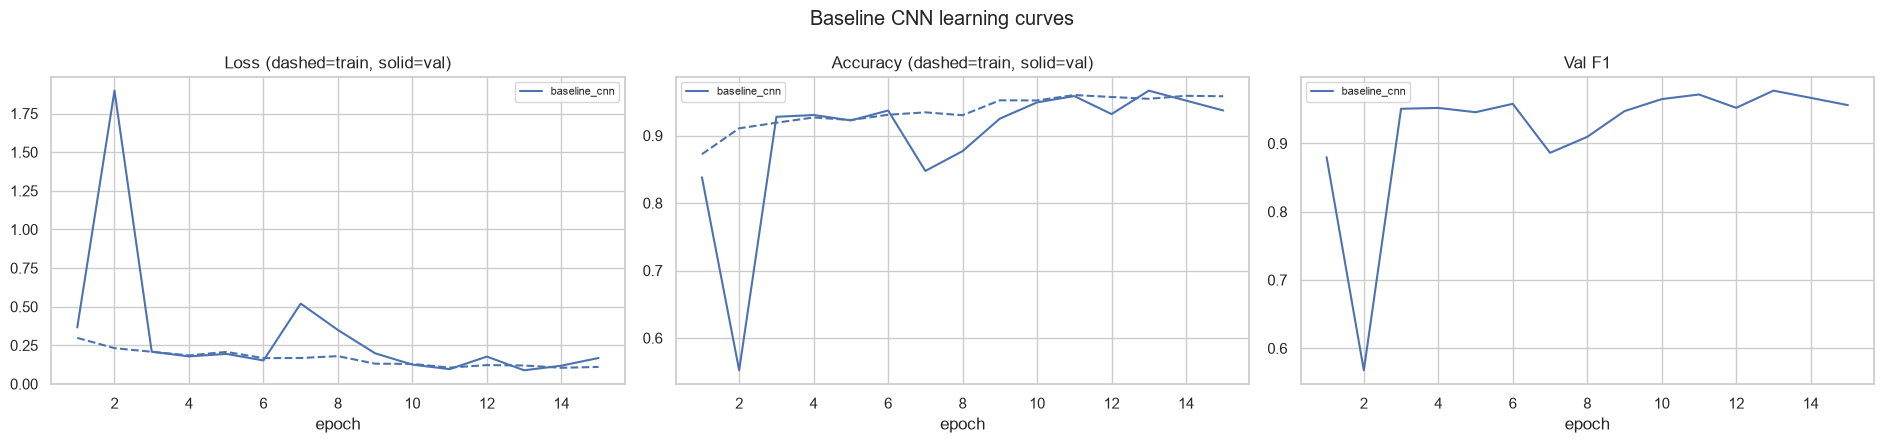

In [ ]:
run_experiment("baseline_cnn", "simple_cnn", "full", prep="raw", aug="light", epochs=CFG["epochs"]["baseline"])
#-- "baseline_cnn"	실험 이름. RESULTS의 키이자 outputs/baseline_cnn.pt 파일 이름
#-- "simple_cnn", "full"	사전학습 없는 작은 CNN, 전체 학습 (얼릴 층이 없음)
#-- prep="raw", aug="light"	원본 이미지 + 약한 증강
#-- epochs=15	최대 15 epoch (조기 종료로 더 일찍 끝날 수 있음)
plot_histories(["baseline_cnn"], "Baseline CNN learning curves")
#-- 실험별 학습곡선 3종(loss, accuracy, val F1)을 겹쳐 그림. 점선은 train, 실선은 val

**해석 포인트**
- 처음부터 학습하는 CNN 은 초반 epoch 의 val loss 가 크게 요동치는 경우가 많다(작은 배치에서 BN 통계가 불안정하고, 특징을 0부터 배워야 하므로).
- 위 `진단` 결과와 train/val 곡선의 간격으로 과소/과적합 여부를 확인한다. 이 모델의 val F1·AUC 가 이후 Transfer Learning 모델이 넘어야 할 **최저 기준**이 된다.



### Baseline CNN 재실험 (Result 변수에 저장된 결과값 실수로 삭제됨)

[baseline_cnn] ep01 | train loss 0.2980 acc 0.8724 | val loss 0.3657 acc 0.8382 f1 0.8798 auc 0.9702 | lr 1.0e-03 | 908s *best
[baseline_cnn] ep02 | train loss 0.2315 acc 0.9108 | val loss 1.8979 acc 0.5521 f1 0.5677 auc 0.9695 | lr 1.0e-03 | 919s
[baseline_cnn] ep03 | train loss 0.2083 acc 0.9190 | val loss 0.2087 acc 0.9278 f1 0.9507 auc 0.9690 | lr 1.0e-03 | 984s *best
[baseline_cnn] ep04 | train loss 0.1846 acc 0.9269 | val loss 0.1782 acc 0.9305 f1 0.9519 auc 0.9802 | lr 1.0e-03 | 1037s *best
[baseline_cnn] ep05 | train loss 0.2074 acc 0.9231 | val loss 0.1943 acc 0.9225 f1 0.9457 auc 0.9820 | lr 1.0e-03 | 837s
[baseline_cnn] ep06 | train loss 0.1673 acc 0.9309 | val loss 0.1521 acc 0.9372 f1 0.9579 auc 0.9816 | lr 1.0e-03 | 722s *best
[baseline_cnn] ep07 | train loss 0.1681 acc 0.9344 | val loss 0.5200 acc 0.8476 f1 0.8862 auc 0.9748 | lr 1.0e-03 | 836s
[baseline_cnn] ep08 | train loss 0.1799 acc 0.9302 | val loss 0.3489 acc 0.8770 f1 0.9096 auc 0.9879 | lr 1.0e-03 | 852s
[baseli

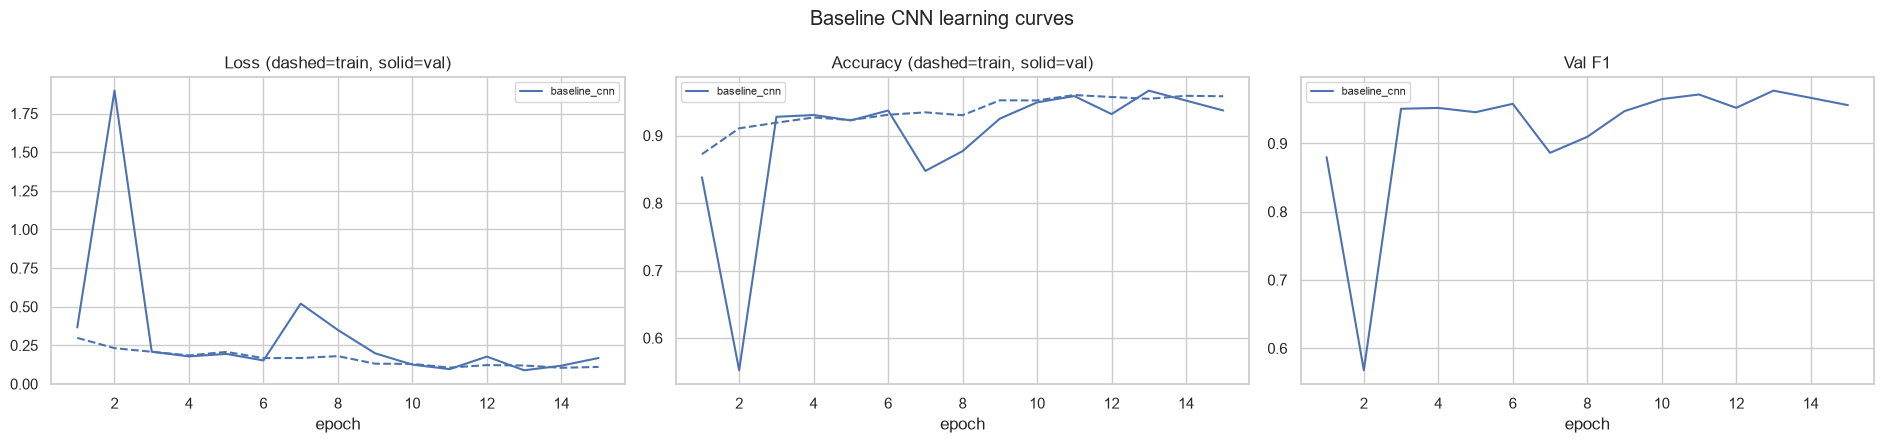

In [118]:
run_experiment("baseline_cnn", "simple_cnn", "full", prep="raw", aug="light", epochs=CFG["epochs"]["baseline"])
plot_histories(["baseline_cnn"], "Baseline CNN learning curves")

---
## 8. 실험 2 — 데이터 전처리 · 증강 기법 비교

- 1000가지 클래스의 이미지가 기본 학습된 **ResNet50** 모델을 불러와 엑스레이 데이터셋을 모델에 맞게 224*224로 조정 및 정규화를 처리하여 사용
**통제 조건** : ResNet50 **Partial Fine-Tuning**(layer4 + head), 동일 epoch·seed. 전처리/증강만 바꿔 효과를 분리해서 본다.

| 실험명 | 전처리 | 증강 | 확인하려는 것 |
|---|---|---|---|
| `aug_none` | raw | none | 증강 없이 학습 시 과적합 정도 |
| `aug_light` | raw | light | 약한 증강 효과 |
| `aug_strong` | raw | strong | 강한 증강의 규제 효과 vs 정보 손실 |
| `clahe_light` | CLAHE | light | 대비 향상 전처리 효과 |

**CLAHE**(Contrast Limited Adaptive Histogram Equalization)는 이미지를 작은 구역으로 나눠 구역별로 대비를 높이되, 너무 과하게 높아지지 않도록 제한 하는대비 향상 기법

In [ ]:
#딕셔너리에 실험 이름: (전처리, 증강)을 정의하고 반복문으로 4번 실행합니다.
AUG_EXPS = {"aug_none": ("raw", "none"), "aug_light": ("raw", "light"),
            "aug_strong": ("raw", "strong"), "clahe_light": ("clahe", "light")}
#-- 모델(ResNet50 Partial), epoch, 학습률, seed는 모두 같게 고정하고 전처리와 증강만 바꿉니다. 
# -- 그래야 성능 차이를 전처리·증강 효과로 볼 수 있습니다(통제 실험).
for name, (prep, aug) in AUG_EXPS.items():
    run_experiment(name, "resnet50", "partial", prep=prep, aug=aug, epochs=CFG["epochs"]["aug"],
                   lrs=dict(lr_head=1e-3, lr_mid=1e-4))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\dsbang/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 53.4MB/s]


[aug_none] ep01 | train loss 0.1461 acc 0.9463 | val loss 0.0757 acc 0.9706 f1 0.9800 auc 0.9963 | lr 1.0e-03 | 360s *best
[aug_none] ep02 | train loss 0.0226 acc 0.9931 | val loss 0.0497 acc 0.9826 f1 0.9883 auc 0.9981 | lr 1.0e-03 | 363s *best
[aug_none] ep03 | train loss 0.0056 acc 0.9980 | val loss 0.1235 acc 0.9679 f1 0.9780 auc 0.9965 | lr 1.0e-03 | 368s
[aug_none] ep04 | train loss 0.0044 acc 0.9989 | val loss 0.0472 acc 0.9826 f1 0.9883 auc 0.9983 | lr 1.0e-03 | 386s *best
[aug_none] ep05 | train loss 0.0034 acc 0.9987 | val loss 0.0569 acc 0.9840 f1 0.9892 auc 0.9979 | lr 1.0e-03 | 387s
[aug_none] ep06 | train loss 0.0040 acc 0.9989 | val loss 0.0915 acc 0.9773 f1 0.9846 auc 0.9951 | lr 1.0e-03 | 372s

▶ aug_none | 학습 37.3분 | val F1 0.9883 AUC 0.9983
  진단: 과적합(Overfitting) 경향 — train acc 1.0000 / val acc 0.9826 (gap +0.0174), train loss 0.0007 / val loss 0.0472 (gap +0.0465), best epoch 4/6, val loss 재상승
[aug_light] ep01 | train loss 0.1771 acc 0.9360 | val loss 0.1187 acc 0.9

In [ ]:
##--학습결과 저장한 RESULTS 에 문제가 없는지 확인
print("RESULTS 에 있는 실험:", list(RESULTS.keys()))
print("저장된 가중치     :", sorted(p.name for p in OUT_DIR.glob("*.pt")))

RESULTS 에 있는 실험: []
저장된 가중치     : ['aug_light.pt', 'aug_none.pt', 'aug_strong.pt', 'baseline_cnn.pt', 'clahe_light.pt']


In [ ]:
########################################################################
## 필요시만 실행 ==========================================
########################################################################
## ── 저장된 가중치로 RESULTS 데이터 복구 (재학습 없음) ──
def recover_experiment(name, arch, mode, prep, aug):
    model, _ = build_model(arch, mode, pretrained=False)
    model.load_state_dict(torch.load(OUT_DIR / f"{name}.pt", map_location=device))
    eval_crit = nn.CrossEntropyLoss(weight=class_weights)
    Xtr, Xva, _ = IMAGES[prep]
    ytr, ptr, ltr = predict(model, make_loader(Xtr, y_train, eval_tf, False), eval_crit)
    yva, pva, lva = predict(model, make_loader(Xva, y_val, eval_tf, False), eval_crit)
    tm, vm = compute_metrics(ytr, ptr), compute_metrics(yva, pva)
    trn, tot = count_params(model)
    hist = {"train_loss": [ltr], "train_acc": [tm["accuracy"]], "val_loss": [lva], "val_acc": [vm["accuracy"]],
            "val_f1": [vm["f1"]], "val_auc": [vm["roc_auc"]], "lr": [np.nan]}
    r = dict(name=name, arch=arch, mode=mode, prep=prep, aug=aug, history=hist,
             train_metrics={**tm, "loss": ltr}, val_metrics={**vm, "loss": lva}, val_probs=pva,
             trainable=trn, total=tot, time_min=np.nan)
    r["verdict"], r["verdict_detail"] = diagnose(r)
    RESULTS[name] = r
    print(f"✔ {name:13s} 복구 | val F1 {vm['f1']:.4f} AUC {vm['roc_auc']:.4f} | {r['verdict']}")
    del model

# # 7장 Baseline -- 필요 시 사용
# #- .pt 가중치로 지표와 진단을 재학습 없이 다시 계산해 RESULTS에 넣음 (학습곡선은 복구 불가)
# recover_experiment("baseline_cnn", "simple_cnn", "full", "raw", "light")

# # 8장 전처리·증강 실험 4개 -- 필요 시 사용
# #   - #.pt 가중치로 지표와 진단을 재학습 없이 다시 계산해 RESULTS에 넣음 (학습곡선은 복구 불가)
# for n, (prep, aug) in AUG_EXPS.items():
#     recover_experiment(n, "resnet50", "partial", prep, aug)



✔ baseline_cnn  복구 | val F1 0.9773 AUC 0.9956 | 적정 적합(Good fit)
✔ aug_none      복구 | val F1 0.9883 AUC 0.9983 | 적정 적합(Good fit)
✔ aug_light     복구 | val F1 0.9864 AUC 0.9984 | 적정 적합(Good fit)
✔ aug_strong    복구 | val F1 0.9656 AUC 0.9966 | 적정 적합(Good fit)
✔ clahe_light   복구 | val F1 0.9789 AUC 0.9984 | 적정 적합(Good fit)


NameError: name 'json' is not defined

In [50]:
if "save_experiment_meta" in globals():
    save_experiment_meta()          # experiments.json 도 5개 실험 기준으로 다시 저장
print("\nRESULTS:", list(RESULTS.keys()))


RESULTS: ['baseline_cnn', 'aug_none', 'aug_light', 'aug_strong', 'clahe_light']


### ResNet50 **Partial Fine-Tuning**(layer4 + head)에포크를 8회로 설정 후 다시 학습

In [ ]:
AUG_EXPS = {"aug_none": ("raw", "none"), "aug_light": ("raw", "light"),
            "aug_strong": ("raw", "strong"), "clahe_light": ("clahe", "light")}
for name, (prep, aug) in AUG_EXPS.items():
    run_experiment(name, "resnet50", "partial", prep=prep, aug=aug, epochs=CFG["epochs"]["aug"],
                   lrs=dict(lr_head=1e-3, lr_mid=1e-4))

##if gap_acc > 0.05 or gap_loss > 0.15 or val_rise:
##        verdict = "과적합(Overfitting) 경향"

[aug_none] ep01 | train loss 0.1461 acc 0.9463 | val loss 0.0757 acc 0.9706 f1 0.9800 auc 0.9963 | lr 1.0e-03 | 378s *best
[aug_none] ep02 | train loss 0.0226 acc 0.9931 | val loss 0.0497 acc 0.9826 f1 0.9883 auc 0.9981 | lr 1.0e-03 | 377s *best
[aug_none] ep03 | train loss 0.0056 acc 0.9980 | val loss 0.1235 acc 0.9679 f1 0.9780 auc 0.9965 | lr 1.0e-03 | 370s
[aug_none] ep04 | train loss 0.0044 acc 0.9989 | val loss 0.0472 acc 0.9826 f1 0.9883 auc 0.9983 | lr 1.0e-03 | 391s *best
[aug_none] ep05 | train loss 0.0034 acc 0.9987 | val loss 0.0569 acc 0.9840 f1 0.9892 auc 0.9979 | lr 1.0e-03 | 411s
[aug_none] ep06 | train loss 0.0040 acc 0.9989 | val loss 0.0915 acc 0.9773 f1 0.9846 auc 0.9951 | lr 1.0e-03 | 394s
[aug_none] ep07 | train loss 0.0034 acc 0.9989 | val loss 0.0662 acc 0.9786 f1 0.9854 auc 0.9984 | lr 3.0e-04 | 372s
[aug_none] ep08 | train loss 0.0008 acc 1.0000 | val loss 0.0625 acc 0.9773 f1 0.9845 auc 0.9982 | lr 3.0e-04 | 373s
[aug_none] EarlyStopping at epoch 8 (best val 

,prep,aug,trainable(M),loss,accuracy,precision,recall,specificity,f1,roc_auc,train_acc,gap(train-val acc),epochs,time(min),진단
model,,,,,,,,,,,,,,,
aug_none,raw,none,14.9688,0.0472,0.9826,0.9892,0.9874,0.9689,0.9883,0.9983,1.0000,0.0174,8,51.1020,과적합(Overfitting) 경향
aug_light,raw,light,14.9688,0.0515,0.9799,0.9963,0.9766,0.9896,0.9864,0.9990,0.9969,0.0169,8,51.8265,적정 적합(Good fit)
aug_strong,raw,strong,14.9688,0.0918,0.9626,0.9962,0.9532,0.9896,0.9742,0.9979,0.9757,0.0131,8,52.2449,적정 적합(Good fit)
clahe_light,clahe,light,14.9688,0.0599,0.9773,0.9909,0.9784,0.9741,0.9846,0.9979,0.9971,0.0198,8,51.7580,적정 적합(Good fit)


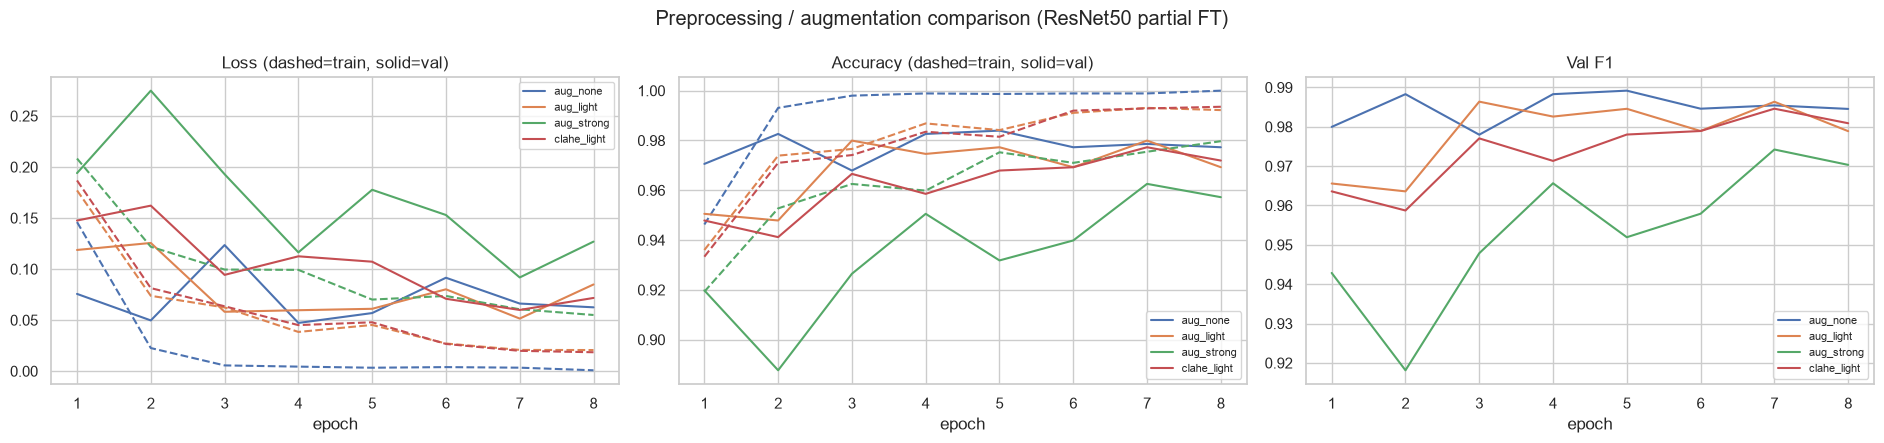


선택된 전처리/증강: aug_none → prep='raw', aug='none' (score 0.9933)
model
aug_none       0.0000
aug_light     -0.0006
aug_strong    -0.0072
clahe_light   -0.0020


In [ ]:

aug_tbl = results_table(list(AUG_EXPS)) 
display(aug_tbl)
plot_histories(list(AUG_EXPS), "Preprocessing / augmentation comparison (ResNet50 partial FT)")

# 선택 기준: 임계값에 덜 민감한 ROC-AUC 와 F1 의 평균 (검증셋 기준) 
aug_score = (aug_tbl["roc_auc"] + aug_tbl["f1"]) / 2 
#-- 선택 기준 점수 = (ROC_AUC + F1) / 2: AUC는 임계값과 무관한 판별 능력
#-- F1은 실제 임계값 0.5에서의 성능입니다. 둘을 평균해 한쪽에 치우치지 않게 했습니다.
BEST_AUG_EXP = aug_score.idxmax()  #idxmax(): 점수가 가장 높은 행의 이름(예: "aug_light")을 돌려줍니다.
BEST_PREP, BEST_AUG = AUG_EXPS[BEST_AUG_EXP] #AUG_EXPS[...]로 그 이름의 (prep, aug)를 꺼내 BEST_PREP, BEST_AUG에 저장
print(f"\n선택된 전처리/증강: {BEST_AUG_EXP} → prep='{BEST_PREP}', aug='{BEST_AUG}' (score {aug_score.max():.4f})")
print((aug_score - aug_score["aug_none"]).rename("score 개선폭(vs 증강 없음)").to_string())

##if gap_acc > 0.05 or gap_loss > 0.15 or val_rise:
##        verdict = "과적합(Overfitting) 경향"

**분석 방법**
- `gap(train-val acc)` 열과 학습곡선 : 
    - 증강이 없으면(`aug_none`) train accuracy 는 빠르게 1.0 에 가까워지고 val loss 는 일찍 바닥을 찍은 뒤 다시 오르는 **과적합 패턴**이 나타나기 쉽다. 
    - 증강은 매 epoch 다른 이미지를 보게 해서 이 간격을 줄인다.
- `strong` 증강은 규제 효과가 가장 크지만, 짧은 학습(6 epoch)에서는 train 성능이 덜 올라와 **약간의 과소적합**처럼 보일 수 있다. → 이후 epoch 을 더 길게 쓰는 11장 개선 실험에서 다시 활용한다.
- CLAHE 는 대비를 키워 음영을 강조하지만, 동시에 노이즈도 키울 수 있어 효과는 데이터에 따라 다르다. 위 score 개선폭으로 판단한다.
- 검증셋이 약 800장이므로 **AUC·F1 의 0.005 이하 차이는 난수 수준의 차이**일 수 있다는 점을 감안한다.

이후 실험 3은 여기서 선택된 `BEST_PREP`, `BEST_AUG` 를 사용한다.



---
## 9. 실험 3 — Transfer Learning & Fine-Tuning 비교 (ResNet50)

ImageNet 으로 사전학습된 **ResNet50** 에 세 가지 Fine-Tuning 전략을 적용한다. 전처리·증강·seed 는 동일하게 두고 **"어디까지 학습하느냐"만** 바꾼다.

In [ ]:
#이번에는 반대로 전처리·증강을 고정(8장에서 고른 것)하고 학습 범위(mode)만 바꿉니다.
#-- lrs는 모드에 필요한 학습률만 넘깁니다. 
#--    Frozen은 헤드만 학습하니 lr_head 하나, Full은 세 그룹 모두입니다.
FT_EXPS = {
    "resnet50_frozen":  dict(mode="frozen",  epochs=CFG["epochs"]["frozen"],  lrs=dict(lr_head=1e-3)),
    "resnet50_partial": dict(mode="partial", epochs=CFG["epochs"]["partial"], lrs=dict(lr_head=1e-3, lr_mid=1e-4)),
    "resnet50_full":    dict(mode="full",    epochs=CFG["epochs"]["full"],    lrs=dict(lr_head=1e-3, lr_mid=1e-4, lr_base=3e-5)),
}
for name, kw in FT_EXPS.items():
    print("=" * 110) #print("=" * 110)은 실험 사이에 구분선을 출력해 로그를 읽기 쉽게 합니다.
    run_experiment(name, "resnet50", kw["mode"], prep=BEST_PREP, aug=BEST_AUG, epochs=kw["epochs"], lrs=kw["lrs"])

[resnet50_frozen] ep01 | train loss 0.2755 acc 0.8925 | val loss 0.1798 acc 0.9385 f1 0.9575 auc 0.9829 | lr 1.0e-03 | 289s *best
[resnet50_frozen] ep02 | train loss 0.1629 acc 0.9298 | val loss 0.1454 acc 0.9519 f1 0.9670 auc 0.9875 | lr 1.0e-03 | 289s *best
[resnet50_frozen] ep03 | train loss 0.1399 acc 0.9436 | val loss 0.1541 acc 0.9412 f1 0.9591 auc 0.9901 | lr 1.0e-03 | 295s
[resnet50_frozen] ep04 | train loss 0.1279 acc 0.9498 | val loss 0.1441 acc 0.9425 f1 0.9600 auc 0.9912 | lr 1.0e-03 | 310s *best
[resnet50_frozen] ep05 | train loss 0.1145 acc 0.9547 | val loss 0.1183 acc 0.9572 f1 0.9706 auc 0.9926 | lr 1.0e-03 | 308s *best
[resnet50_frozen] ep06 | train loss 0.1084 acc 0.9583 | val loss 0.1063 acc 0.9626 f1 0.9745 auc 0.9930 | lr 1.0e-03 | 294s *best
[resnet50_frozen] ep07 | train loss 0.1022 acc 0.9628 | val loss 0.1003 acc 0.9599 f1 0.9727 auc 0.9937 | lr 1.0e-03 | 298s *best
[resnet50_frozen] ep08 | train loss 0.1055 acc 0.9587 | val loss 0.1016 acc 0.9599 f1 0.9726 auc

---
## 10. 검증셋 기준 모델 비교 · 과적합/과소적합 진단  
###  - Baseline CNN + **ResNet50** 세 가지 Fine-Tuning 

,prep,aug,trainable(M),loss,accuracy,precision,recall,specificity,f1,roc_auc,train_acc,gap(train-val acc),epochs,time(min),진단
model,,,,,,,,,,,,,,,
baseline_cnn,raw,light,1.1737,0.0884,0.9666,0.9871,0.9676,0.9637,0.9773,0.9956,0.9732,0.0067,15,207.6143,과적합(Overfitting) 경향
resnet50_frozen,raw,none,0.0041,0.0953,0.9666,0.9889,0.9658,0.9689,0.9772,0.9944,0.9757,0.0091,10,49.5035,적정 적합(Good fit)
resnet50_partial,raw,none,14.9688,0.0472,0.9826,0.9892,0.9874,0.9689,0.9883,0.9983,1.0000,0.0174,8,49.7113,과적합(Overfitting) 경향
resnet50_full,raw,none,23.5121,0.0547,0.9840,0.9874,0.9910,0.9637,0.9892,0.9981,0.9987,0.0147,6,86.6313,과적합(Overfitting) 경향


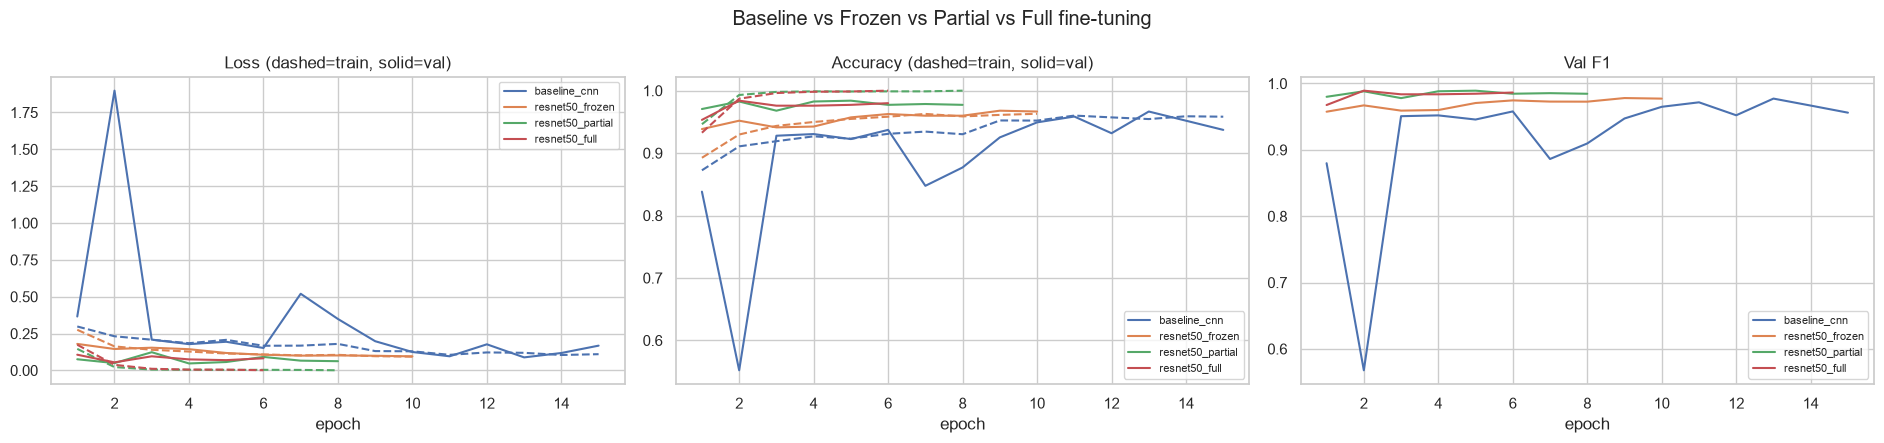

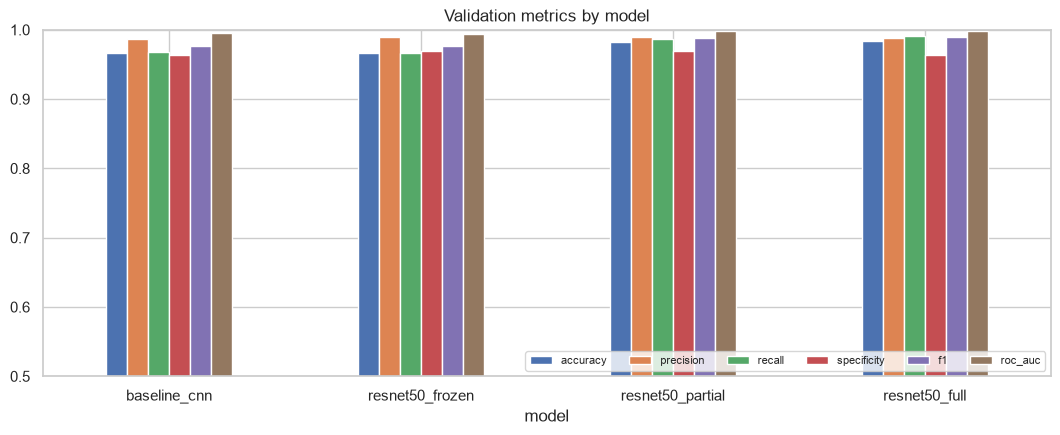


[과적합/과소적합 진단]
 - baseline_cnn      : 과적합(Overfitting) 경향
   train acc 0.9732 / val acc 0.9666 (gap +0.0067), train loss 0.0770 / val loss 0.0884 (gap +0.0114), best epoch 13/15, val loss 재상승
 - resnet50_frozen   : 적정 적합(Good fit)
   train acc 0.9757 / val acc 0.9666 (gap +0.0091), train loss 0.0708 / val loss 0.0953 (gap +0.0245), best epoch 10/10
 - resnet50_partial  : 과적합(Overfitting) 경향
   train acc 1.0000 / val acc 0.9826 (gap +0.0174), train loss 0.0007 / val loss 0.0472 (gap +0.0465), best epoch 4/8, val loss 재상승
 - resnet50_full     : 과적합(Overfitting) 경향
   train acc 0.9987 / val acc 0.9840 (gap +0.0147), train loss 0.0070 / val loss 0.0547 (gap +0.0477), best epoch 2/6, val loss 재상승


In [119]:
#핵심 비교 대상 4개(Baseline, Frozen, Partial, Full)를 한 표, 한 학습곡선, 한 막대그래프로 봅니다.
MAIN_EXPS = ["baseline_cnn"] + list(FT_EXPS)
main_tbl = results_table(MAIN_EXPS) #여러 실험의 지표, 정확도 차이, epoch 수, 학습 시간, 진단을 한 표로 정리
display(main_tbl)
plot_histories(MAIN_EXPS, "Baseline vs Frozen vs Partial vs Full fine-tuning")

metric_cols = ["accuracy", "precision", "recall", "specificity", "f1", "roc_auc"]
main_tbl[metric_cols].plot.bar(figsize=(13, 4.5), rot=0, ylim=(0.5, 1.0)) 
#-- metric_cols는 이후 장에서도 계속 쓰는 지표 목록 변수입니다.
#-- plot.bar: 모델별로 6개 지표 막대를 나란히 그립니다.
#-- ylim=(0.5, 1.0)은 차이가 잘 보이도록 y축을 0.5부터 시작한 것입니다.

plt.title("Validation metrics by model"); plt.legend(ncol=6, fontsize=8, loc="lower right"); plt.show()

print("\n[과적합/과소적합 진단]")
for n in MAIN_EXPS:
    print(f" - {n:18s}: {RESULTS[n]['verdict']}\n   {RESULTS[n]['verdict_detail']}")

### 결과 해석 가이드 (지표 → 판단 근거)

**1) Transfer Learning 효과 (Baseline vs ResNet50)**
- 같은 데이터·증강에서 사전학습 모델의 **ROC-AUC / F1 이 Baseline 보다 높고 수렴도 빠르다면**, ImageNet 에서 배운 에지·질감 등 범용 특징이 X-ray 에도 유효하다는 근거가 된다. 적은 데이터(약 4.5천 장)에서는 처음부터 학습하는 것보다 사전학습 특징을 재사용하는 편이 효율적이다.

**2) Frozen vs Partial vs Full**
- **Frozen** : 학습 파라미터가 헤드뿐(약 0.02%)이라 train accuracy 자체가 다른 모델보다 낮게 머무는 경향 → 자연 이미지 특징만으로는 X-ray 의 미세한 음영 차이를 충분히 표현하지 못함. train·val 이 모두 낮으면 **과소적합(용량 부족)**, 대신 train-val 차이는 작다.
- **Partial** : 고수준 블록(layer4)만 X-ray 에 맞추므로 성능이 크게 오르면서도 과적합 위험은 중간 수준.
- **Full** : 표현력이 가장 커서 train accuracy 가 1.0 에 가깝게 올라간다. val 지표도 가장 좋을 수 있지만, **train-val 차이·val loss 재상승이 나타나면 과적합** 신호다(조기 종료가 막아 주는지 확인).
- 결론은 표의 `f1`, `roc_auc`, `gap(train-val acc)`, `진단` 을 함께 보고 내린다: **"val 성능이 높으면서 gap 이 작은 모델"** 이 일반화가 좋은 모델이다.

**3) Precision vs Recall**
- 클래스 가중치를 줬기 때문에 두 지표가 비교적 균형을 이룬다. 의료 스크리닝에서는 폐렴을 놓치는 FN 이 더 치명적이므로 **Recall 을 우선**하되, Specificity 가 너무 낮으면 정상인을 과잉 진단하게 된다.



---
## 11. 성능 개선 조치

### 11-1. 진단 → 개선 방향
10장의 결과에서 흔히 드러나는 문제와 이에 대응하는 조치를 정리했다. 아래 셀은 실제 결과를 읽어 **어떤 문제가 관찰됐는지 자동으로 출력**한다.

| 관찰된 문제 | 원인 | 조치 |
|---|---|---|
| Full FT 의 train–val 격차 / val loss 재상승 (과적합) | 파라미터 2천만+ 전체를 소량 데이터로 학습 | **강한 증강(strong)** + **Label Smoothing(0.1)** + 조기 종료 |
| Full FT 초반 val loss 불안정 | 무작위 초기화된 헤드의 큰 gradient 가 사전학습 가중치를 망가뜨림 | **점진적 unfreeze** : 헤드만 2 epoch warm-up 후 전체 학습 |
| Frozen 과소적합 | ImageNet 특징과 X-ray 도메인 차이 | 도메인 적응이 되는 (Full) FT 사용 |
| 한 모델의 예측 분산 | 모델 구조별 편향 | 흉부 X-ray 에 널리 쓰이는 **DenseNet121**(CheXNet 구조) 추가 + **앙상블** |
| 임계값 0.5 가 최적이 아님 | 가중 손실·분포 차이로 확률 보정이 어긋남 | 검증셋에서 **Youden's J(= Recall + Specificity − 1) 최대 임계값** 선택 |
| 입력 위치·크기에 민감 | 단일 뷰 예측 | **TTA** (확대 뷰 평균) |

In [120]:
print("[자동 진단 요약]")
for n in MAIN_EXPS:
    r = RESULTS[n]
    print(f" - {n:18s} {r['verdict']:20s} | val F1 {r['val_metrics']['f1']:.4f} AUC {r['val_metrics']['roc_auc']:.4f} "
          f"| recall {r['val_metrics']['recall']:.4f} specificity {r['val_metrics']['specificity']:.4f}")

best_ft = max(FT_EXPS, key=lambda n: RESULTS[n]["val_metrics"]["roc_auc"])
# -- max(..., key=...): 세 Fine-Tuning 전략 중 검증 AUC가 가장 높은 이름을 고릅니다.
print(f"\n→ Fine-Tuning 전략 중 val ROC-AUC 최고: {best_ft}")
overfit = [n for n in MAIN_EXPS if "과적합" in RESULTS[n]["verdict"]]
underfit = [n for n in MAIN_EXPS if "과소적합" in RESULTS[n]["verdict"]]
print("→ 과적합 경향 모델:", overfit or "없음", "| 과소적합 모델:", underfit or "없음")
#-- 판정 문자열에 "과적합" 또는 "과소적합"이 들어간 모델을 모아 출력합니다. 개선 조치의 근거를 코드 결과로 보여 주는 부분입니다.

[자동 진단 요약]
 - baseline_cnn       과적합(Overfitting) 경향  | val F1 0.9773 AUC 0.9956 | recall 0.9676 specificity 0.9637
 - resnet50_frozen    적정 적합(Good fit)      | val F1 0.9772 AUC 0.9944 | recall 0.9658 specificity 0.9689
 - resnet50_partial   과적합(Overfitting) 경향  | val F1 0.9883 AUC 0.9983 | recall 0.9874 specificity 0.9689
 - resnet50_full      과적합(Overfitting) 경향  | val F1 0.9892 AUC 0.9981 | recall 0.9910 specificity 0.9637

→ Fine-Tuning 전략 중 val ROC-AUC 최고: resnet50_partial
→ 과적합 경향 모델: ['baseline_cnn', 'resnet50_partial', 'resnet50_full'] | 과소적합 모델: 없음


### 11-2. 개선 A/B — 점진적 unfreeze + 강한 증강 + Label Smoothing (ResNet50, DenseNet121)

- 모드는 **Full Fine-Tuning** (도메인 적응 효과가 가장 큼)
- 1단계 : 헤드만 2 epoch warm-up (lr 1e-3) → 2단계 : 전체 unfreeze, Discriminative LR
- `strong` 증강 + Label Smoothing 0.1 로 과적합 억제, 최대 15 epoch + 조기 종료
- 전처리는 실험 2에서 선택된 `BEST_PREP` 사용

[resnet50_improved-warmup] ep01 | train loss 0.3773 acc 0.8432 | val loss 0.2623 acc 0.8917 f1 0.9220 auc 0.9770 | lr 1.0e-03 | 376s *best
[resnet50_improved-warmup] ep02 | train loss 0.2396 acc 0.9092 | val loss 0.2740 acc 0.8810 f1 0.9130 auc 0.9829 | lr 1.0e-03 | 335s
[resnet50_improved] ep01 | train loss 0.4039 acc 0.8979 | val loss 0.3344 acc 0.8824 f1 0.9141 auc 0.9874 | lr 1.0e-03 | 933s *best
[resnet50_improved] ep02 | train loss 0.3576 acc 0.9405 | val loss 0.2177 acc 0.9278 f1 0.9491 auc 0.9935 | lr 1.0e-03 | 960s *best
[resnet50_improved] ep03 | train loss 0.3366 acc 0.9532 | val loss 0.2149 acc 0.9305 f1 0.9509 auc 0.9948 | lr 1.0e-03 | 879s *best
[resnet50_improved] ep04 | train loss 0.3256 acc 0.9563 | val loss 0.2909 acc 0.9078 f1 0.9337 auc 0.9938 | lr 1.0e-03 | 910s
[resnet50_improved] ep05 | train loss 0.3219 acc 0.9596 | val loss 0.1946 acc 0.9479 f1 0.9637 auc 0.9959 | lr 1.0e-03 | 882s *best
[resnet50_improved] ep06 | train loss 0.3174 acc 0.9636 | val loss 0.1965 

100%|██████████| 30.8M/30.8M [00:00<00:00, 44.8MB/s]


[densenet121_improved-warmup] ep01 | train loss 0.3917 acc 0.8260 | val loss 0.2969 acc 0.8663 f1 0.9022 auc 0.9754 | lr 1.0e-03 | 275s *best
[densenet121_improved-warmup] ep02 | train loss 0.2714 acc 0.8918 | val loss 0.2177 acc 0.9091 f1 0.9358 auc 0.9799 | lr 1.0e-03 | 272s *best
[densenet121_improved] ep01 | train loss 0.4848 acc 0.8664 | val loss 0.2705 acc 0.8997 f1 0.9277 auc 0.9905 | lr 1.0e-03 | 836s *best
[densenet121_improved] ep02 | train loss 0.3985 acc 0.9146 | val loss 0.2995 acc 0.8997 f1 0.9275 auc 0.9933 | lr 1.0e-03 | 861s
[densenet121_improved] ep03 | train loss 0.3802 acc 0.9260 | val loss 0.2015 acc 0.9345 f1 0.9540 auc 0.9950 | lr 1.0e-03 | 842s *best
[densenet121_improved] ep04 | train loss 0.3542 acc 0.9449 | val loss 0.2055 acc 0.9425 f1 0.9598 auc 0.9959 | lr 1.0e-03 | 923s
[densenet121_improved] ep05 | train loss 0.3443 acc 0.9492 | val loss 0.2501 acc 0.9345 f1 0.9539 auc 0.9966 | lr 1.0e-03 | 826s
[densenet121_improved] ep06 | train loss 0.3381 acc 0.9541 

,prep,aug,trainable(M),loss,accuracy,precision,recall,specificity,f1,roc_auc,train_acc,gap(train-val acc),epochs,time(min),진단
model,,,,,,,,,,,,,,,
resnet50_full,raw,none,23.5121,0.0547,0.9840,0.9874,0.9910,0.9637,0.9892,0.9981,0.9987,0.0147,6,86.6313,과적합(Overfitting) 경향
resnet50_improved,raw,strong,23.5121,0.1817,0.9519,0.9962,0.9387,0.9896,0.9666,0.9971,0.9737,0.0218,13,177.6333,적정 적합(Good fit)
densenet121_improved,raw,strong,6.9559,0.2015,0.9345,0.9961,0.9153,0.9896,0.9540,0.9950,0.9496,0.0151,9,108.5496,적정 적합(Good fit)


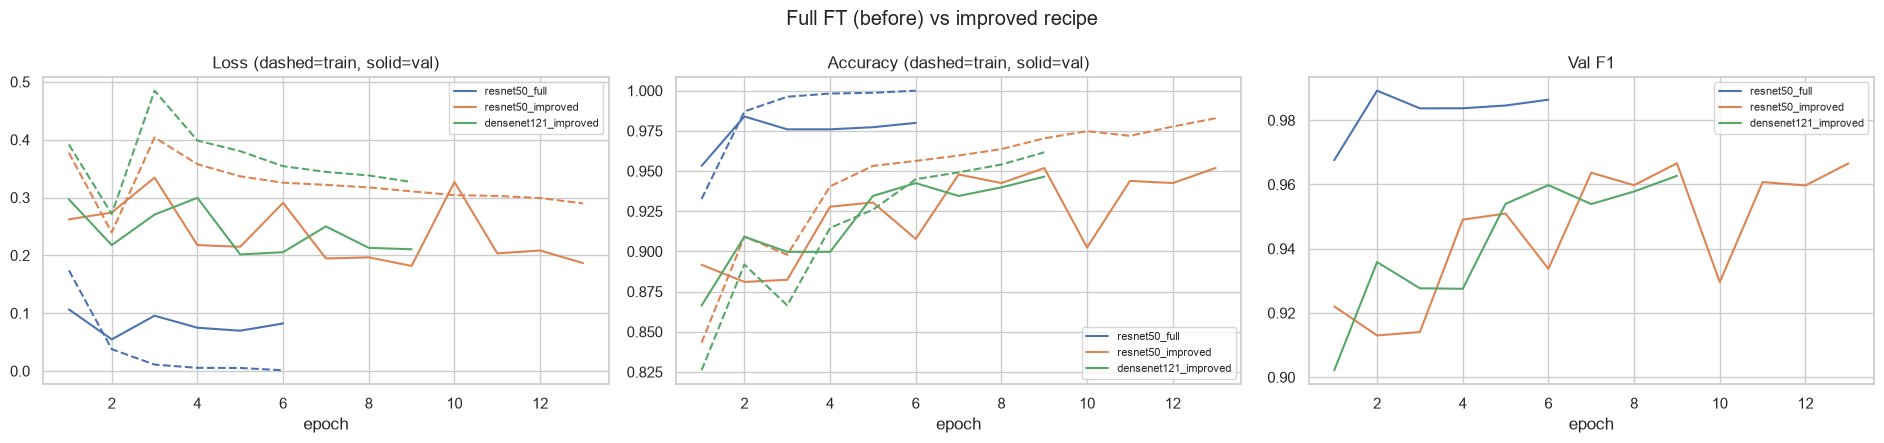

In [ ]:
IMPROVED_AUG = "strong" #데이터 증강 강하게 = 과적합 억제
IMPROVED = {
    "resnet50_improved": dict(arch="resnet50", lrs=dict(lr_head=1e-3, lr_mid=1e-4, lr_base=3e-5)),
    "densenet121_improved": dict(arch="densenet121", lrs=dict(lr_head=1e-3, lr_mid=1e-4, lr_base=3e-5)),
}
for name, kw in IMPROVED.items():
    print("=" * 110)
    run_experiment(name, kw["arch"], "full", prep=BEST_PREP, aug=IMPROVED_AUG, #데이터 증강 강하게
                   epochs=CFG["epochs"]["improved"], label_smoothing=0.1,  #Label Smoothing 0.1 : 정답을 100%가 아니라 90%로 학습시켜 과신 방지 /최대 epoch 15
                   warmup_epochs=0 if QUICK_MODE else 2, lrs=kw["lrs"])  #warm-up 헤드만 2 epoch 먼저	초반 학습 불안정 방지

cmp_names = ["resnet50_full"] + list(IMPROVED)
display(results_table(cmp_names))
plot_histories(cmp_names, "Full FT (before) vs improved recipe")

**해석** : `resnet50_full`(개선 전)과 `resnet50_improved` 를 비교한다. 개선 레시피가 의도대로 동작했다면
- `gap(train-val acc)` 가 줄고 `진단` 이 '적정 적합' 쪽으로 이동 (강한 증강·Label Smoothing 의 규제 효과)
- 학습곡선 초반의 val loss 스파이크가 줄어듦 (warm-up 효과)
- val ROC-AUC / F1 유지 또는 향상

※ Label Smoothing 은 train loss 를 원래 0 까지 내려가지 않게 만드므로, 과적합 판단은 증강 없는 train 셋을 다시 평가한 `train_acc` 와 val 지표의 차이로 한다(표의 값이 그렇게 계산됨).

### 11-3. 개선 C/D — 임계값 최적화 · TTA · 앙상블 (검증셋에서 결정)

- 모든 결정(임계값, 최종 모델 선택)은 **검증셋에서만** 내리고 test 에는 그대로 적용한다 → test 정보 누수 방지.
- 최종 모델 선택 기준은 **val ROC-AUC** : 임계값을 val 에 맞춰 튜닝하면 val F1 은 낙관적으로 부풀려지므로, 임계값과 무관한 AUC 로 고른다.

In [ ]:
#################################
## Youden 임계값 함수
#################################
def youden_threshold(y, p):
    #Youden's J = TPR − FPR = Recall + Specificity − 1이 가장 큰 임계값을 고릅니다.
    #-- 폐렴을 잘 찾으면서 정상도 잘 맞히는 균형점입니다.
    fpr, tpr, thr = roc_curve(y, p) 
    #-- roc_curve는 임계값을 바꿔 가며 각 임계값에서의 FPR(1 − Specificity)과 TPR(Recall)을 돌려줍니다.
    return float(np.clip(thr[np.argmax(tpr - fpr)], 0.01, 0.99))
    #-- np.clip(0.01, 0.99): roc_curve의 첫 임계값은 무한대(inf)라서, 극단값이 선택되지 않도록 범위를 제한합니다.

eval_crit = nn.CrossEntropyLoss(weight=class_weights)

#################################
## 검증셋 TTA 확률 계산
#################################
# 저장된 가중치를 불러와 TTA(원본 + 확대 2뷰의 평균) 확률을 계산합니다. 
# TTA 없는 확률은 이미 RESULTS[n]["val_probs"]에 있습니다.
VAL_TTA = {}
for n in IMPROVED:
    m = load_model(n)
    _, Xva, _ = IMAGES[RESULTS[n]["prep"]]
    _, VAL_TTA[n], _ = predict(m, make_loader(Xva, y_val, eval_tf, False), tta=True)
    del m

#################################
## 후보 7개 구성
#################################
CANDIDATES = {}   # 이름 -> dict(members, tta, thr, val_probs)

for n in IMPROVED:
    pv = RESULTS[n]["val_probs"]
    #resnet50_improved (thr=0.5),   모델: ResNet50,  TTA: X  , 임계값: 0.5
    #DenseNet121 동일
    CANDIDATES[f"{n} (thr=0.5)"] = dict(members=[n], tta=False, thr=0.5, val_probs=pv) 
    #resnet50_improved +Youden,     모델: ResNet50,  TTA: X  , 임계값: 검증셋 Youden
    #DenseNet121 동일
    CANDIDATES[f"{n} +Youden"] = dict(members=[n], tta=False, thr=youden_threshold(y_val, pv), val_probs=pv)
    #resnet50_improved +TTA+Youden, 모델: ResNet50,  TTA: O  , 임계값: 검증셋 Youden
    #DenseNet121 동일
    CANDIDATES[f"{n} +TTA+Youden"] = dict(members=[n], tta=True, thr=youden_threshold(y_val, VAL_TTA[n]), val_probs=VAL_TTA[n])

#Ensemble +TTA+Youden, 모델: 두 모델 확률 평균,  TTA: O  , 임계값: 검증셋 Youden
ens_val = np.mean([VAL_TTA[n] for n in IMPROVED], axis=0)
CANDIDATES["Ensemble(ResNet50+DenseNet121) +TTA+Youden"] = dict(
    members=list(IMPROVED), tta=True, thr=youden_threshold(y_val, ens_val), val_probs=ens_val)

#################################
## 최종 선택
#################################
cand_val = pd.DataFrame({k: {"thr": v["thr"], **compute_metrics(y_val, v["val_probs"], v["thr"])}
                         for k, v in CANDIDATES.items()}).T
display(cand_val[["thr"] + metric_cols])
FINAL = cand_val["roc_auc"].astype(float).idxmax()
# 후보 구성(멤버·TTA·임계값)도 저장 → 15장에서 재학습 없이 복원
CAND_PATH = OUT_DIR / "candidates.json"
CAND_PATH.write_text(json.dumps({k: {"members": v["members"], "tta": v["tta"], "thr": v["thr"]}
                                 for k, v in CANDIDATES.items()}, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"최종 선택 (val ROC-AUC 최고): {FINAL}  | 임계값 {CANDIDATES[FINAL]['thr']:.3f}")

,thr,accuracy,precision,recall,specificity,f1,roc_auc
resnet50_improved (thr=0.5),0.5000,0.9519,0.9962,0.9387,0.9896,0.9666,0.9971
resnet50_improved +Youden,0.2875,0.9719,0.9963,0.9658,0.9896,0.9808,0.9971
resnet50_improved +TTA+Youden,0.3188,0.9786,0.9963,0.9748,0.9896,0.9854,0.9980
densenet121_improved (thr=0.5),0.5000,0.9345,0.9961,0.9153,0.9896,0.9540,0.9950
densenet121_improved +Youden,0.2408,0.9666,0.9889,0.9658,0.9689,0.9772,0.9950
densenet121_improved +TTA+Youden,0.4314,0.9679,1.0000,0.9568,1.0000,0.9779,0.9975
Ensemble(ResNet50+DenseNet121) +TTA+Youden,0.3375,0.9813,0.9945,0.9802,0.9845,0.9873,0.9983


최종 선택 (val ROC-AUC 최고): Ensemble(ResNet50+DenseNet121) +TTA+Youden  | 임계값 0.337


**해석** : Youden 임계값은 Recall 과 Specificity 를 동시에 고려하므로, 0.5 대비 두 지표의 균형이 좋아지는지를 본다. TTA 와 앙상블은 여러 예측을 평균해 분산을 줄이므로 주로 **ROC-AUC 가 소폭 상승**하는 형태로 나타난다. 여기서 선택된 `FINAL` 구성을 test 에서 그대로 평가한다.

---
## 12. 최종 테스트 — Kaggle 공식 test 셋 (624장)

지금까지 한 번도 사용하지 않은 **Kaggle 제공 test 폴더**로 모든 모델을 평가한다.
- 개선 전 모델(Baseline, 증강 실험, Frozen/Partial/Full) : 임계값 0.5
- 개선 후 후보 : 11장에서 **검증셋으로 정한** 임계값·TTA 설정 그대로 적용

In [ ]:
##############################################################
#모든 실험의 가중치를 차례로 불러와 test 폐렴 확률을 계산합니다.
##############################################################
TEST_PROBS, TEST_PROBS_TTA = {}, {}
for n in RESULTS:
    m = load_model(n)
    Xte = IMAGES[RESULTS[n]["prep"]][2] 
    #-- IMAGES[prep][2]: 학습 때 CLAHE를 썼으면 test도 CLAHE 버전을 써야 하므로, 실험마다 자기 전처리의 test 배열을 씁니다.
    loader = make_loader(Xte, y_test, eval_tf, False)
    _, TEST_PROBS[n], _ = predict(m, loader)
    if n in IMPROVED:       # resnet50_improved, densenet121_improved
        _, TEST_PROBS_TTA[n], _ = predict(m, loader, tta=True) #개선 모델 2개는 TTA 확률도 따로 계산합니다.  
    del m
    if device.type == "cuda":
        torch.cuda.empty_cache()

# 후보 설정대로 test 확률을 만듭니다.
def candidate_test_probs(c):
    src = TEST_PROBS_TTA if c["tta"] else TEST_PROBS 
    #-- TTA 여부에 따라 출처를 고르고, 멤버가 2개(앙상블)면 평균, 1개면 그대로 반환합니다.
    return np.mean([src[n] for n in c["members"]], axis=0) ## 앙상블은 members가 2개 → 평균

test_rows = {}
for n in RESULTS:
    #개선 전 실험(before)은 임계값 0.5, 개선 후보(improved)는 검증셋에서 정한 임계값을 그대로 적용합니다.
    test_rows[n] = {"stage": "before", "thr": 0.5, **compute_metrics(y_test, TEST_PROBS[n]), #**compute_metrics(...): 딕셔너리를 풀어 지표들을 같은 행에 합칩니다.
                    "val_f1": RESULTS[n]["val_metrics"]["f1"], "val_auc": RESULTS[n]["val_metrics"]["roc_auc"]}
for k, c in CANDIDATES.items():
    vm = compute_metrics(y_val, c["val_probs"], c["thr"])
    test_rows[k] = {"stage": "improved", "thr": c["thr"], **compute_metrics(y_test, candidate_test_probs(c), c["thr"]),
                    "val_f1": vm["f1"], "val_auc": vm["roc_auc"]}
test_tbl = pd.DataFrame(test_rows).T
num_cols = ["thr"] + metric_cols + ["val_f1", "val_auc", "TN", "FP", "FN", "TP"]
test_tbl[num_cols] = test_tbl[num_cols].astype(float)
test_tbl["f1 gap(val-test)"] = test_tbl["val_f1"] - test_tbl["f1"] 
#-- f1 gap(val-test): 검증 F1 − test F1입니다. 크면 test에서 성능이 떨어진 것(일반화 문제나 분포 차이)입니다.
test_tbl.to_csv(OUT_DIR / "test_results.csv")

#highlight_final: 표에서 FINAL 행만 노란색으로 칠합니다.
def highlight_final(row):
    return ["background-color: #fff3bf" if row.name == FINAL else "" for _ in row]

display(test_tbl[["stage", "thr"] + metric_cols + ["val_f1", "f1 gap(val-test)", "FN", "FP"]]
        .style.apply(highlight_final, axis=1).format(precision=4))

,stage,thr,accuracy,precision,recall,specificity,f1,roc_auc,val_f1,f1 gap(val-test),FN,FP
baseline_cnn,before,0.5000,0.8798,0.8462,0.9872,0.7009,0.9112,0.9603,0.9773,0.0660,5.0000,70.0000
aug_none,before,0.5000,0.8446,0.8033,0.9949,0.5940,0.8889,0.9452,0.9883,0.0994,2.0000,95.0000
aug_light,before,0.5000,0.9135,0.8818,0.9949,0.7778,0.9349,0.9808,0.9864,0.0514,2.0000,52.0000
aug_strong,before,0.5000,0.9487,0.9409,0.9795,0.8974,0.9598,0.9884,0.9742,0.0144,8.0000,24.0000
clahe_light,before,0.5000,0.8830,0.8468,0.9923,0.7009,0.9138,0.9821,0.9846,0.0708,3.0000,70.0000
resnet50_frozen,before,0.5000,0.8269,0.7950,0.9744,0.5812,0.8756,0.9514,0.9772,0.1016,10.0000,98.0000
resnet50_partial,before,0.5000,0.8446,0.8033,0.9949,0.5940,0.8889,0.9452,0.9883,0.0994,2.0000,95.0000
resnet50_full,before,0.5000,0.8413,0.7988,0.9974,0.5812,0.8871,0.9527,0.9892,0.1021,1.0000,98.0000
resnet50_improved,before,0.5000,0.9471,0.9429,0.9744,0.9017,0.9584,0.9820,0.9666,0.0082,10.0000,23.0000
densenet121_improved,before,0.5000,0.9359,0.9332,0.9667,0.8846,0.9496,0.9827,0.9540,0.0044,13.0000,27.0000


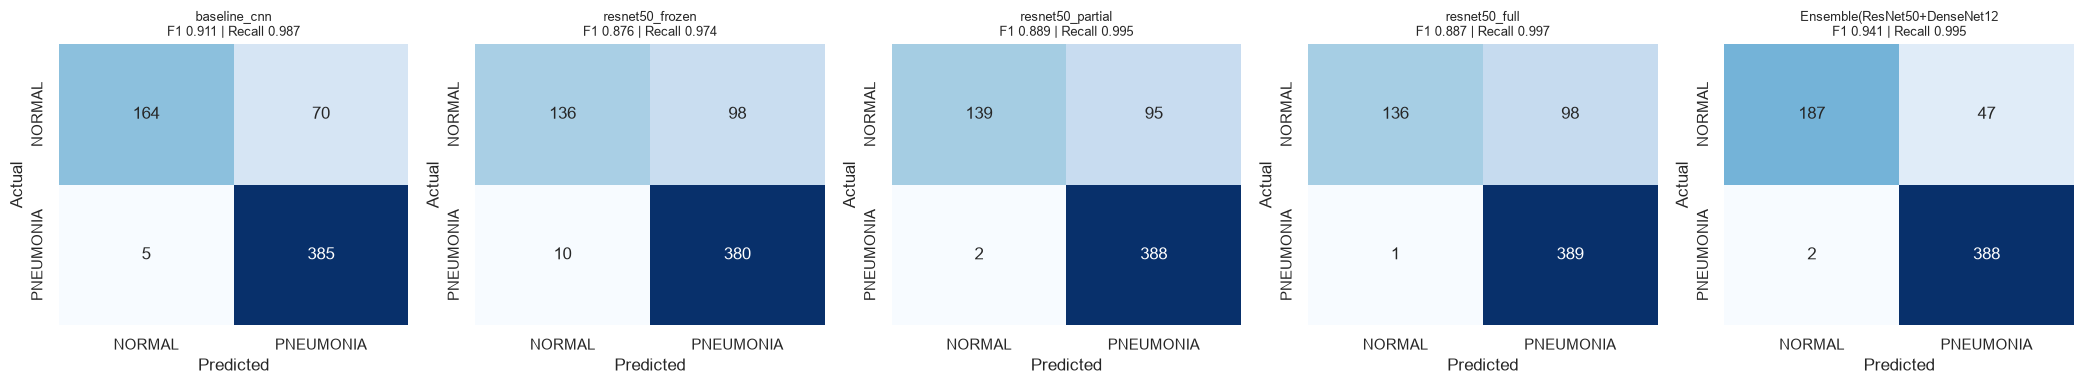

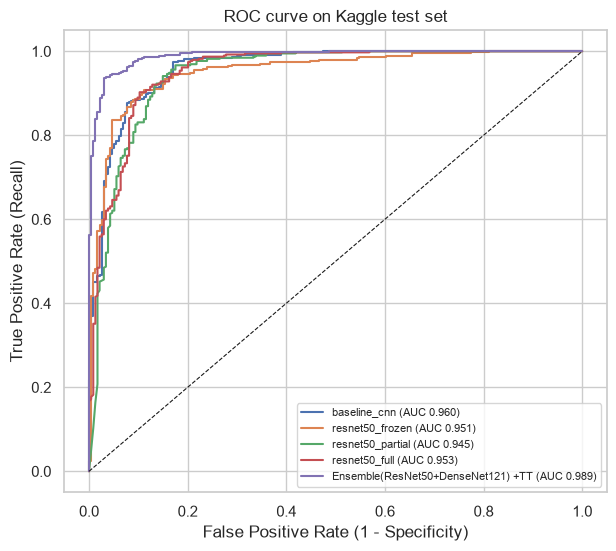

In [59]:
show = ["baseline_cnn", "resnet50_frozen", "resnet50_partial", "resnet50_full", FINAL]
fig, axes = plt.subplots(1, len(show), figsize=(4.2 * len(show), 4))
for ax, n in zip(axes, show):
    row = test_tbl.loc[n]
    cm = np.array([[row.TN, row.FP], [row.FN, row.TP]]).astype(int)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{n[:28]}\nF1 {row.f1:.3f} | Recall {row.recall:.3f}", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 6))
for n in show:
    p = candidate_test_probs(CANDIDATES[n]) if n in CANDIDATES else TEST_PROBS[n]
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f"{n[:34]} (AUC {roc_auc_score(y_test, p):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=.8)
plt.xlabel("False Positive Rate (1 - Specificity)"); plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC curve on Kaggle test set"); plt.legend(fontsize=8); plt.show()

In [ ]:
#최종 모델 분류 리포트
final_c = CANDIDATES[FINAL]
final_p = candidate_test_probs(final_c)
final_pred = (final_p >= final_c["thr"]).astype(int)
print(f"■ 최종 모델: {FINAL} (threshold={final_c['thr']:.3f})\n")
print(classification_report(y_test, final_pred, target_names=CLASS_NAMES, digits=4))
#-- classification_report는 NORMAL과 PNEUMONIA 각각의 precision, recall, f1과 전체 평균을 표로 보여 줍니다. NORMAL 행의 recall이 곧 Specificity입니다.

# (참고용·분석 전용) test 에서 최적인 임계값 — 모델 선택에는 사용하지 않음
oracle_thr = youden_threshold(y_test, final_p)
#test를 보고 구한 최적 임계값입니다. 성능 보고에는 쓰지 않고(test 누수), 검증 임계값과 얼마나 다른지를 보는 분석 전용입니다. 
# -- 차이가 크면 test의 분포가 train과 다르다는 증거입니다.
om = compute_metrics(y_test, final_p, oracle_thr)
print(f"[참고] test 기준 Youden 최적 임계값 {oracle_thr:.3f} → acc {om['accuracy']:.4f}, "
      f"recall {om['recall']:.4f}, specificity {om['specificity']:.4f}, f1 {om['f1']:.4f}")
print("       (test 를 보고 정한 값이므로 성능 보고에는 쓰지 않고, 분포 차이(shift) 크기를 가늠하는 용도로만 사용)")

■ 최종 모델: Ensemble(ResNet50+DenseNet121) +TTA+Youden (threshold=0.337)

              precision    recall  f1-score   support

      NORMAL     0.9894    0.7991    0.8842       234
   PNEUMONIA     0.8920    0.9949    0.9406       390

    accuracy                         0.9215       624
   macro avg     0.9407    0.8970    0.9124       624
weighted avg     0.9285    0.9215    0.9194       624

[참고] test 기준 Youden 최적 임계값 0.778 → acc 0.9487, recall 0.9359, specificity 0.9701, f1 0.9580
       (test 를 보고 정한 값이므로 성능 보고에는 쓰지 않고, 분포 차이(shift) 크기를 가늠하는 용도로만 사용)


### 테스트 결과 해석 가이드

1. **val vs test 격차 (`f1 gap(val-test)`)**
   - 이 데이터셋에서는 대부분의 모델이 **test 에서 Recall 은 높고 Specificity(NORMAL 정답률)는 낮게** 나오는 경향이 있다. 즉, FP(정상을 폐렴으로 오진)가 FN 보다 많다.
   - 원인은 과적합만이 아니라 **분포 차이(distribution shift)** 다: test 의 폐렴 비율(62.5%)이 train(74%)과 다르고, test 이미지가 별도로 수집되어 촬영 조건도 다르다. train/val 은 같은 분포이므로 val 점수는 test 보다 높게 나오는 것이 자연스럽다.
   - 위 `[참고]` 줄에서 test 기준 최적 임계값이 검증셋 임계값과 크게 다르면, 모델의 **판별 능력(AUC)은 유지되지만 확률 보정(calibration)이 test 분포에서 어긋난 것**으로 해석할 수 있다.

2. **개선 전후 비교** : `stage=before` 의 `resnet50_full` 과 `improved` 후보들의 F1 / Specificity / AUC 를 비교해 11장의 조치가 test 에서도 효과가 있었는지 확인한다.

3. **의료 관점** : 최종 모델의 `FN`(놓친 폐렴 수)이 작고 Recall 이 높으면 스크리닝 목적에는 적합하다. 다만 FP 가 많으면 정상 환자의 추가 검사 비용이 늘어나므로, 실제 적용 시에는 운영 목적(선별 vs 확진)에 맞춰 임계값을 정해야 한다.

---
## 13. 모델 해석 — Grad-CAM & 오분류 분석

**Grad-CAM** 은 마지막 합성곱 특징맵에 대한 폐렴 클래스 점수의 gradient 로 "모델이 어디를 보고 판단했는지"를 히트맵으로 보여준다. 모델이 **폐 영역**을 보고 있다면 합리적이고, 글자·마커·몸 밖 영역을 본다면 편향(shortcut learning)을 의심해야 한다.

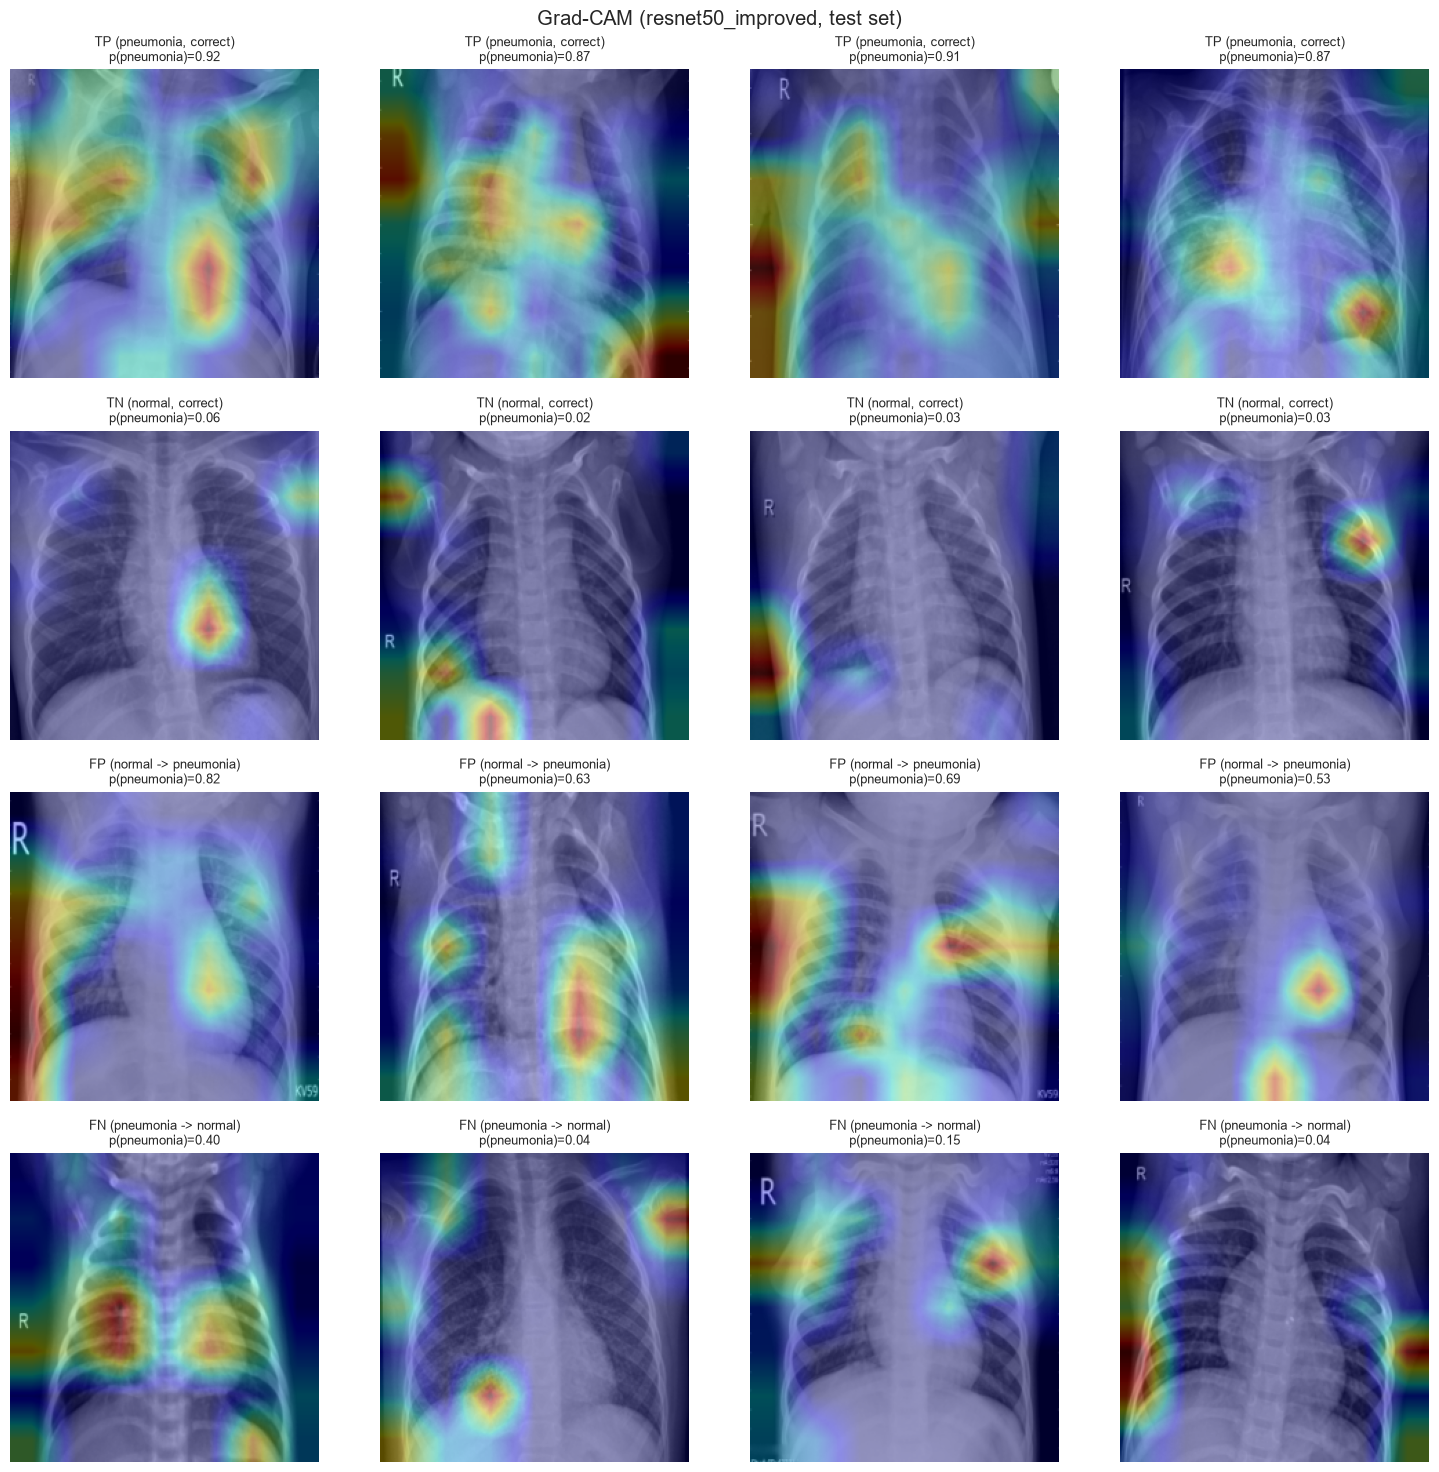

In [ ]:
############################################################################
## GradCAM 클래스 정의
############################################################################
class GradCAM:
    def __init__(self, model, layer):
        self.model, self.acts, self.grads = model, None, None
        #hook은 모델 코드를 고치지 않고 중간 층의 값을 엿보는 장치입니다
        def fwd_hook(_, __, out):  # forward hook: 대상 층(ResNet layer4)을 지날 때 출력 특징맵(2048채널 × 7×7)을 저장합니다.
            self.acts = out                                         ## ① 특징맵 저장
            out.register_hook(lambda g: setattr(self, "grads", g))  # ② 역전파 때 기울기 저장
        self.handle = layer.register_forward_hook(fwd_hook)

    def __call__(self, x, cls=1):
        self.model.eval(); self.model.zero_grad()       
        x = x.clone().requires_grad_(True)
        score = self.model(x)[:, cls].sum()             
        score.backward()                                    # ③ 폐렴 점수로 역전파 : 폐렴 점수(cls=1)가 각 특징맵에 얼마나 민감한지 역전파로 계산
        w = self.grads.mean(dim=(2, 3), keepdim=True)       # ④ 채널별 중요도: 채널별 기울기의 평균 = "이 채널이 폐렴 판단에 얼마나 중요한가"
        cam = F.relu((w * self.acts).sum(1, keepdim=True))  # ⑤ 가중합 + 양수만: 중요도 × 특징맵을 모두 더해 위치별 점수를 만들고, 폐렴 쪽으로 기여한 양수만 남김
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[:, 0]  # ⑥ 7×7 → 224×224 확대
        cam = cam - cam.amin(dim=(1, 2), keepdim=True)
        return (cam / (cam.amax(dim=(1, 2), keepdim=True) + 1e-8)).detach().cpu().numpy()   ## ⑦ 0~1 정규화 :⑥-⑦ 원본 크기로 키우고 0~1로 맞춰 히트맵으로 겹쳐 그리기 좋게 함

## 시각화
 #개선 모델 중 검증 AUC가 높은 단일 모델을 사용합니다. 앙상블은 층이 하나가 아니라 Grad-CAM을 그릴 수 없기 때문입니다.
cam_name = max(IMPROVED, key=lambda n: RESULTS[n]["val_metrics"]["roc_auc"])
cam_model = load_model(cam_name)
target_layer = cam_model.layer4 if RESULTS[cam_name]["arch"] == "resnet50" else cam_model.features.denseblock4
cam = GradCAM(cam_model, target_layer)
Xte_cam = IMAGES[RESULTS[cam_name]["prep"]][2]
p_cam = TEST_PROBS[cam_name]
pred_cam = (p_cam >= 0.5).astype(int)

groups = {"TP (pneumonia, correct)": np.where((y_test == 1) & (pred_cam == 1))[0],
          "TN (normal, correct)": np.where((y_test == 0) & (pred_cam == 0))[0],
          "FP (normal -> pneumonia)": np.where((y_test == 0) & (pred_cam == 1))[0],
          "FN (pneumonia -> normal)": np.where((y_test == 1) & (pred_cam == 0))[0]}
rng = np.random.default_rng(0)
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
for r, (g, ids) in enumerate(groups.items()):
    sel = rng.choice(ids, size=min(4, len(ids)), replace=False) if len(ids) else []
    for c in range(4):
        ax = axes[r, c]; ax.axis("off")
        if c >= len(sel):
            continue
        i = sel[c]
        x = eval_tf(Image.fromarray(Xte_cam[i]).convert("RGB")).unsqueeze(0).to(device)
        heat = cam(x)[0]
        ax.imshow(denorm(x[0].cpu())); ax.imshow(heat, cmap="jet", alpha=0.35)
        ax.set_title(f"{g}\np(pneumonia)={p_cam[i]:.2f}", fontsize=9)
plt.suptitle(f"Grad-CAM ({cam_name}, test set)"); plt.tight_layout(); plt.show()
cam.handle.remove(); del cam_model

**해석 포인트**
- **TP** : 히트맵이 폐 하엽·폐 문 주변의 음영(consolidation) 부위에 집중되면 모델이 의학적으로 타당한 근거를 사용한 것이다.
- **FP** : 정상인데 폐렴으로 예측한 경우. 영상이 전반적으로 흐리거나, 호흡이 얕아 폐 음영이 짙게 보이는 소아 영상이 많다 → 사람도 헷갈리는 경계 사례가 포함됨.
- **FN** : 음영이 작거나 희미한 초기/경미 폐렴이 많다. 이런 사례를 줄이려면 더 높은 해상도(예: 384px) 입력이 도움이 될 수 있다.
- 히트맵이 폐 밖(어깨, 글자 마커, 영상 가장자리)에 강하게 나타난다면 데이터 편향을 학습한 것이므로, 폐 영역 crop(segmentation) 전처리를 추가 개선 과제로 고려한다.

---
## 14. 결론

In [62]:
summary = pd.concat([
    test_tbl.loc[["baseline_cnn", "resnet50_frozen", "resnet50_partial", "resnet50_full"], metric_cols],
    test_tbl.loc[[FINAL], metric_cols]])
display(summary.style.highlight_max(axis=0, color="#d3f9d8").format(precision=4))

b, f = test_tbl.loc["baseline_cnn"], test_tbl.loc[FINAL]
best_ft_test = max(FT_EXPS, key=lambda n: test_tbl.loc[n, "roc_auc"])
print("■ 자동 요약")
print(f" 1) 전처리/증강 실험 선택: {BEST_AUG_EXP} (prep={BEST_PREP}, aug={BEST_AUG})")
print(f" 2) Fine-Tuning 전략 비교(test AUC): " +
      ", ".join(f"{n.split('_')[1]} {test_tbl.loc[n, 'roc_auc']:.4f}" for n in FT_EXPS) + f" → 최고 {best_ft_test}")
print(f" 3) 검증셋 진단: " + ", ".join(f"{n}={RESULTS[n]['verdict']}" for n in MAIN_EXPS + list(IMPROVED)))
print(f" 4) 최종 모델: {FINAL}")
print(f"    test Accuracy {f.accuracy:.4f} | Precision {f.precision:.4f} | Recall {f.recall:.4f} | "
      f"Specificity {f.specificity:.4f} | F1 {f.f1:.4f} | AUC {f.roc_auc:.4f}")
print(f"    Baseline CNN 대비: F1 {f.f1 - b.f1:+.4f}, AUC {f.roc_auc - b.roc_auc:+.4f}, "
      f"Accuracy {f.accuracy - b.accuracy:+.4f}")
print(f"    놓친 폐렴(FN) {int(f.FN)}건 / 과잉진단(FP) {int(f.FP)}건 (test {len(y_test)}장)")

,accuracy,precision,recall,specificity,f1,roc_auc
baseline_cnn,0.8798,0.8462,0.9872,0.7009,0.9112,0.9603
resnet50_frozen,0.8269,0.7950,0.9744,0.5812,0.8756,0.9514
resnet50_partial,0.8446,0.8033,0.9949,0.5940,0.8889,0.9452
resnet50_full,0.8413,0.7988,0.9974,0.5812,0.8871,0.9527
Ensemble(ResNet50+DenseNet121) +TTA+Youden,0.9215,0.8920,0.9949,0.7991,0.9406,0.9889


■ 자동 요약
 1) 전처리/증강 실험 선택: aug_none (prep=raw, aug=none)
 2) Fine-Tuning 전략 비교(test AUC): frozen 0.9514, partial 0.9452, full 0.9527 → 최고 resnet50_full
 3) 검증셋 진단: baseline_cnn=적정 적합(Good fit), resnet50_frozen=적정 적합(Good fit), resnet50_partial=과적합(Overfitting) 경향, resnet50_full=과적합(Overfitting) 경향, resnet50_improved=적정 적합(Good fit), densenet121_improved=적정 적합(Good fit)
 4) 최종 모델: Ensemble(ResNet50+DenseNet121) +TTA+Youden
    test Accuracy 0.9215 | Precision 0.8920 | Recall 0.9949 | Specificity 0.7991 | F1 0.9406 | AUC 0.9889
    Baseline CNN 대비: F1 +0.0294, AUC +0.0286, Accuracy +0.0417
    놓친 폐렴(FN) 2건 / 과잉진단(FP) 47건 (test 624장)


### 정리

**1. 데이터 & 전처리**
- 공식 val(16장)을 쓰지 않고 train+val 을 **환자 단위 층화 분할**해 신뢰할 수 있는 검증셋을 만들었다(누수 0).
- 3:1 클래스 불균형은 **가중 손실함수**로 보정했고, 그래서 Accuracy 대신 **Recall / Specificity / F1 / AUC** 를 중심으로 평가했다.
- 해부학적으로 타당한 증강만 사용했으며(반전 제외), CLAHE·증강 강도 비교는 실험 2 표로 근거를 남겼다.

**2. Transfer Learning & Fine-Tuning**
- 사전학습 모델은 Baseline CNN 대비 적은 epoch 으로 더 높은 판별 성능을 보이는지 비교했다.
- **Frozen** 은 학습 파라미터가 적어 과적합은 적지만 도메인 차이로 **과소적합** 경향, **Full** 은 성능 잠재력이 가장 크지만 **과적합** 관리가 필요, **Partial** 은 그 중간 — 이 트레이드오프를 train/val 격차와 학습곡선으로 확인했다.

**3. 성능 개선**
- 진단 결과에 근거해 **점진적 unfreeze, 강한 증강, Label Smoothing**(과적합 대응), **DenseNet121 추가와 앙상블·TTA**(분산 감소), **Youden 임계값**(Recall–Specificity 균형)을 적용했다.
- 모든 선택은 검증셋에서 하고 test 는 마지막에 한 번만 사용했다.

**4. 한계와 다음 단계**
- test 셋은 train 과 분포가 달라 val 보다 Specificity 가 낮게 나오기 쉽다. 실제 적용 전에는 **목표 병원 데이터로 임계값 재보정(calibration)** 이 필요하다.
- 추가 개선 아이디어 : 폐 영역 segmentation 후 crop, 고해상도(384~512px) 입력, K-Fold 교차검증 앙상블, Focal Loss, CheXpert/NIH ChestX-ray14 같은 **흉부 X-ray 전용 사전학습 가중치** 사용.

In [ ]:
# 결과물 저장 확인
summary_all = pd.concat({"val": pd.DataFrame({n: RESULTS[n]["val_metrics"] for n in RESULTS}).T,
                         "train": pd.DataFrame({n: RESULTS[n]["train_metrics"] for n in RESULTS}).T}, axis=1)
summary_all.to_csv(OUT_DIR / "train_val_results.csv")
print("저장된 파일:")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:40s} {p.stat().st_size/1e6:8.1f} MB")

---
## 15. 저장된 최종 가중치로 실험별 혼동행렬 다시 그리기 

학습이 모두 끝난 뒤, **다시 학습하지 않고** 각 실험의 최종(best) 가중치 기준 혼동행렬을 그린다. 아래 함수는 상황에 따라 예측값을 가져오는 방법을 자동으로 고른다.

| 우선순위 | 상황 | 가져오는 방법 | 필요한 것 |
|---|---|---|---|
| ① `memory` | 전체 실행 직후 (같은 커널) | 메모리의 `PRED_PACK` | 없음 |
| ② `file` | 커널 재시작 후 | `outputs/predictions.pkl` 로드 → **추론도 없음** | 1장 셀(import·CFG)만 실행 |
| ③ `weights` | pkl 이 없거나 `source="weights"` 지정 | `outputs/<실험명>.pt` 가중치 + `experiments.json` 으로 모델 복원 → val/test **추론만** 수행 | 1~6장 셀 실행 (데이터 로드·함수 정의, 학습 셀은 건너뜀) |

- 단일 실험은 임계값 0.5, 11장의 개선 후보는 **검증셋에서 정한 임계값·TTA 설정**(`candidates.json`)을 그대로 적용한다.
- 각 칸에는 **건수와 행 기준 비율(%)** 을 함께 표시한다. 행 비율의 대각선이 곧 NORMAL 의 Specificity, PNEUMONIA 의 Recall 이다.
- 그림은 `outputs/confusion_<split>.png` 로 저장된다.

In [63]:
def _pack_from_weights():
    """저장된 .pt 가중치로 모델을 복원해 val/test 예측 확률을 계산 (학습 없음, 추론만)."""
    need = [v for v in ("IMAGES", "y_val", "y_test", "build_model", "predict") if v not in globals()]
    if need:
        raise RuntimeError(f"{need} 가 없습니다. 1~6장 셀(데이터 로드·함수 정의)을 먼저 실행하세요. 학습 셀(7장~)은 건너뛰어도 됩니다.")
    meta = json.loads((OUT_DIR / "experiments.json").read_text(encoding="utf-8"))
    cand_path = OUT_DIR / "candidates.json"
    cands = json.loads(cand_path.read_text(encoding="utf-8")) if cand_path.exists() else {}
    tta_needed = {n for c in cands.values() if c["tta"] for n in c["members"]}
    pack = {"y": {"val": y_val, "test": y_test}, "single": {}, "single_tta": {}, "candidates": cands}
    for n, mt in meta.items():
        w = OUT_DIR / f"{n}.pt"
        if not w.exists():
            print(f"  - {n}: 가중치 파일 없음 → 건너뜀"); continue
        model, _ = build_model(mt["arch"], mt["mode"], pretrained=False)
        model.load_state_dict(torch.load(w, map_location=device)); model.eval()
        _, Xva, Xte = IMAGES[mt["prep"]]
        lv, lt = make_loader(Xva, y_val, eval_tf, False), make_loader(Xte, y_test, eval_tf, False)
        pack["single"][n] = {"val": predict(model, lv)[1], "test": predict(model, lt)[1]}
        if n in tta_needed:
            pack["single_tta"][n] = {"val": predict(model, lv, tta=True)[1], "test": predict(model, lt, tta=True)[1]}
        print(f"  - {n}: 가중치 로드 & 추론 완료")
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    return pack

def get_prediction_pack(source="auto"):
    """source: 'auto' | 'memory' | 'file' | 'weights'"""
    pred_path = OUT_DIR / "predictions.pkl"
    if source in ("auto", "memory") and "PRED_PACK" in globals():
        print("예측값 출처: memory (현재 커널)"); return PRED_PACK
    if source in ("auto", "file") and pred_path.exists():
        print(f"예측값 출처: file ({pred_path})")
        with open(pred_path, "rb") as fp:
            return pickle.load(fp)
    print("예측값 출처: weights (저장된 가중치로 추론)")
    return _pack_from_weights()

def entries_for(pack, split="test"):
    """{표시이름: (확률, 임계값)} — 단일 실험(thr 0.5) + 개선 후보(검증셋 임계값)."""
    entries = {n: (d[split], 0.5) for n, d in pack["single"].items()}
    for k, c in pack["candidates"].items():
        src = pack["single_tta"] if c["tta"] else pack["single"]
        if all(m in src for m in c["members"]):
            entries[k] = (np.mean([src[m][split] for m in c["members"]], axis=0), c["thr"])
    return entries

def plot_confusion_grid(pack, split="test", names=None, ncols=4, save=True):
    y = pack["y"][split]
    entries = entries_for(pack, split)
    names = [n for n in (names or entries) if n in entries]
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.1 * nrows), squeeze=False)
    rows = []
    for ax, n in zip(axes.flat, names):
        p, thr = entries[n]
        cm = confusion_matrix(y, (p >= thr).astype(int), labels=[0, 1])
        pct = cm / cm.sum(axis=1, keepdims=True)
        annot = np.array([[f"{cm[i, j]}\n({pct[i, j]:.1%})" for j in range(2)] for i in range(2)])
        sns.heatmap(pct, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot_kws={"fontsize": 11})
        m = compute_metrics(y, p, thr)
        ax.set_title(f"{n[:40]}  (thr={thr:.2f})\nAcc {m['accuracy']:.3f} | Rec {m['recall']:.3f} | "
                     f"Spec {m['specificity']:.3f} | F1 {m['f1']:.3f}", fontsize=9)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        rows.append({"model": n, "thr": thr, **{k: m[k] for k in ["TN", "FP", "FN", "TP", "accuracy",
                                                                   "precision", "recall", "specificity", "f1", "roc_auc"]}})
    for ax in axes.flat[len(names):]:
        ax.axis("off")
    plt.suptitle(f"Confusion matrices — {split} set (final weights, no retraining)", fontsize=14, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    if save:
        fig.savefig(OUT_DIR / f"confusion_{split}.png", dpi=120, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(rows).set_index("model")

예측값 출처: weights (저장된 가중치로 추론)
  - baseline_cnn: 가중치 로드 & 추론 완료
  - aug_none: 가중치 로드 & 추론 완료
  - aug_light: 가중치 로드 & 추론 완료
  - aug_strong: 가중치 로드 & 추론 완료
  - clahe_light: 가중치 로드 & 추론 완료
  - resnet50_frozen: 가중치 로드 & 추론 완료
  - resnet50_partial: 가중치 로드 & 추론 완료
  - resnet50_full: 가중치 로드 & 추론 완료
  - resnet50_improved: 가중치 로드 & 추론 완료
  - densenet121_improved: 가중치 로드 & 추론 완료


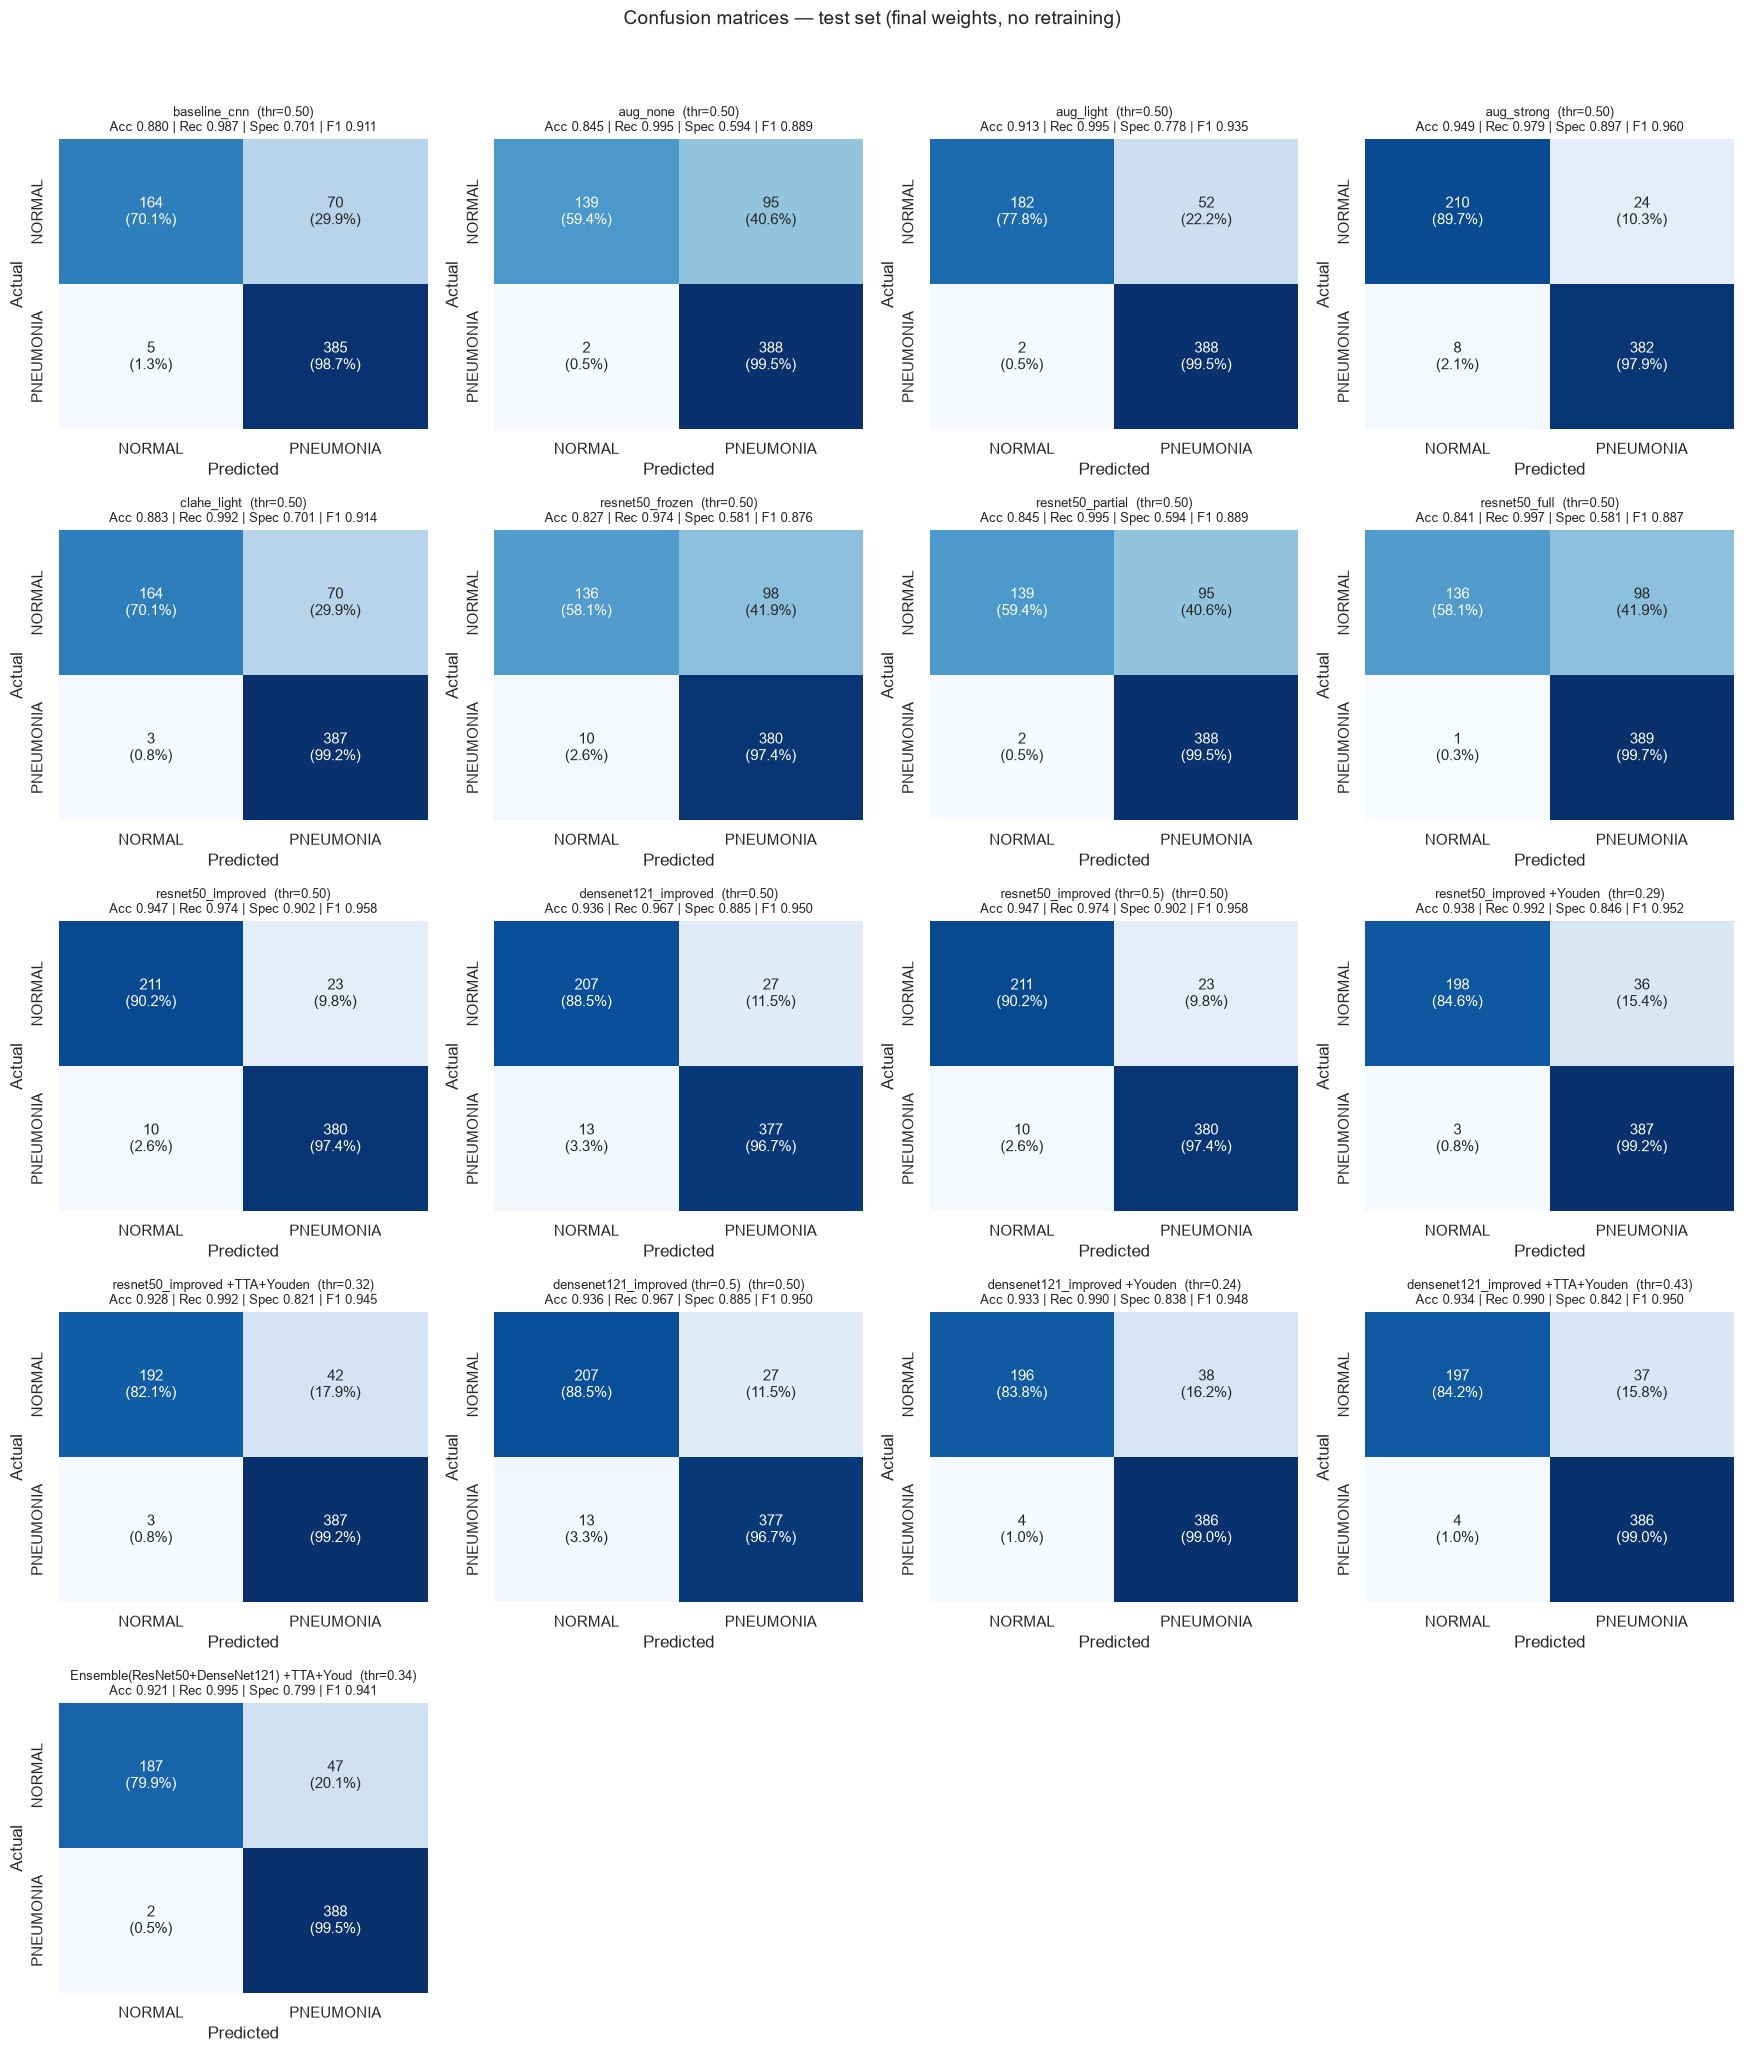

,thr,TN,FP,FN,TP,accuracy,precision,recall,specificity,f1,roc_auc
model,,,,,,,,,,,
baseline_cnn,0.5000,164,70,5,385,0.8798,0.8462,0.9872,0.7009,0.9112,0.9603
aug_none,0.5000,139,95,2,388,0.8446,0.8033,0.9949,0.5940,0.8889,0.9452
aug_light,0.5000,182,52,2,388,0.9135,0.8818,0.9949,0.7778,0.9349,0.9808
aug_strong,0.5000,210,24,8,382,0.9487,0.9409,0.9795,0.8974,0.9598,0.9884
clahe_light,0.5000,164,70,3,387,0.8830,0.8468,0.9923,0.7009,0.9138,0.9821
resnet50_frozen,0.5000,136,98,10,380,0.8269,0.7950,0.9744,0.5812,0.8756,0.9514
resnet50_partial,0.5000,139,95,2,388,0.8446,0.8033,0.9949,0.5940,0.8889,0.9452
resnet50_full,0.5000,136,98,1,389,0.8413,0.7988,0.9974,0.5812,0.8871,0.9527
resnet50_improved,0.5000,211,23,10,380,0.9471,0.9429,0.9744,0.9017,0.9584,0.9820


In [64]:
PACK = get_prediction_pack("auto")      # 'weights' 로 바꾸면 가중치에서 직접 다시 추론

cm_test = plot_confusion_grid(PACK, split="test")
display(cm_test.style.format(precision=4).highlight_max(subset=["f1", "roc_auc"], color="#d3f9d8")
        .highlight_min(subset=["FN"], color="#d3f9d8"))

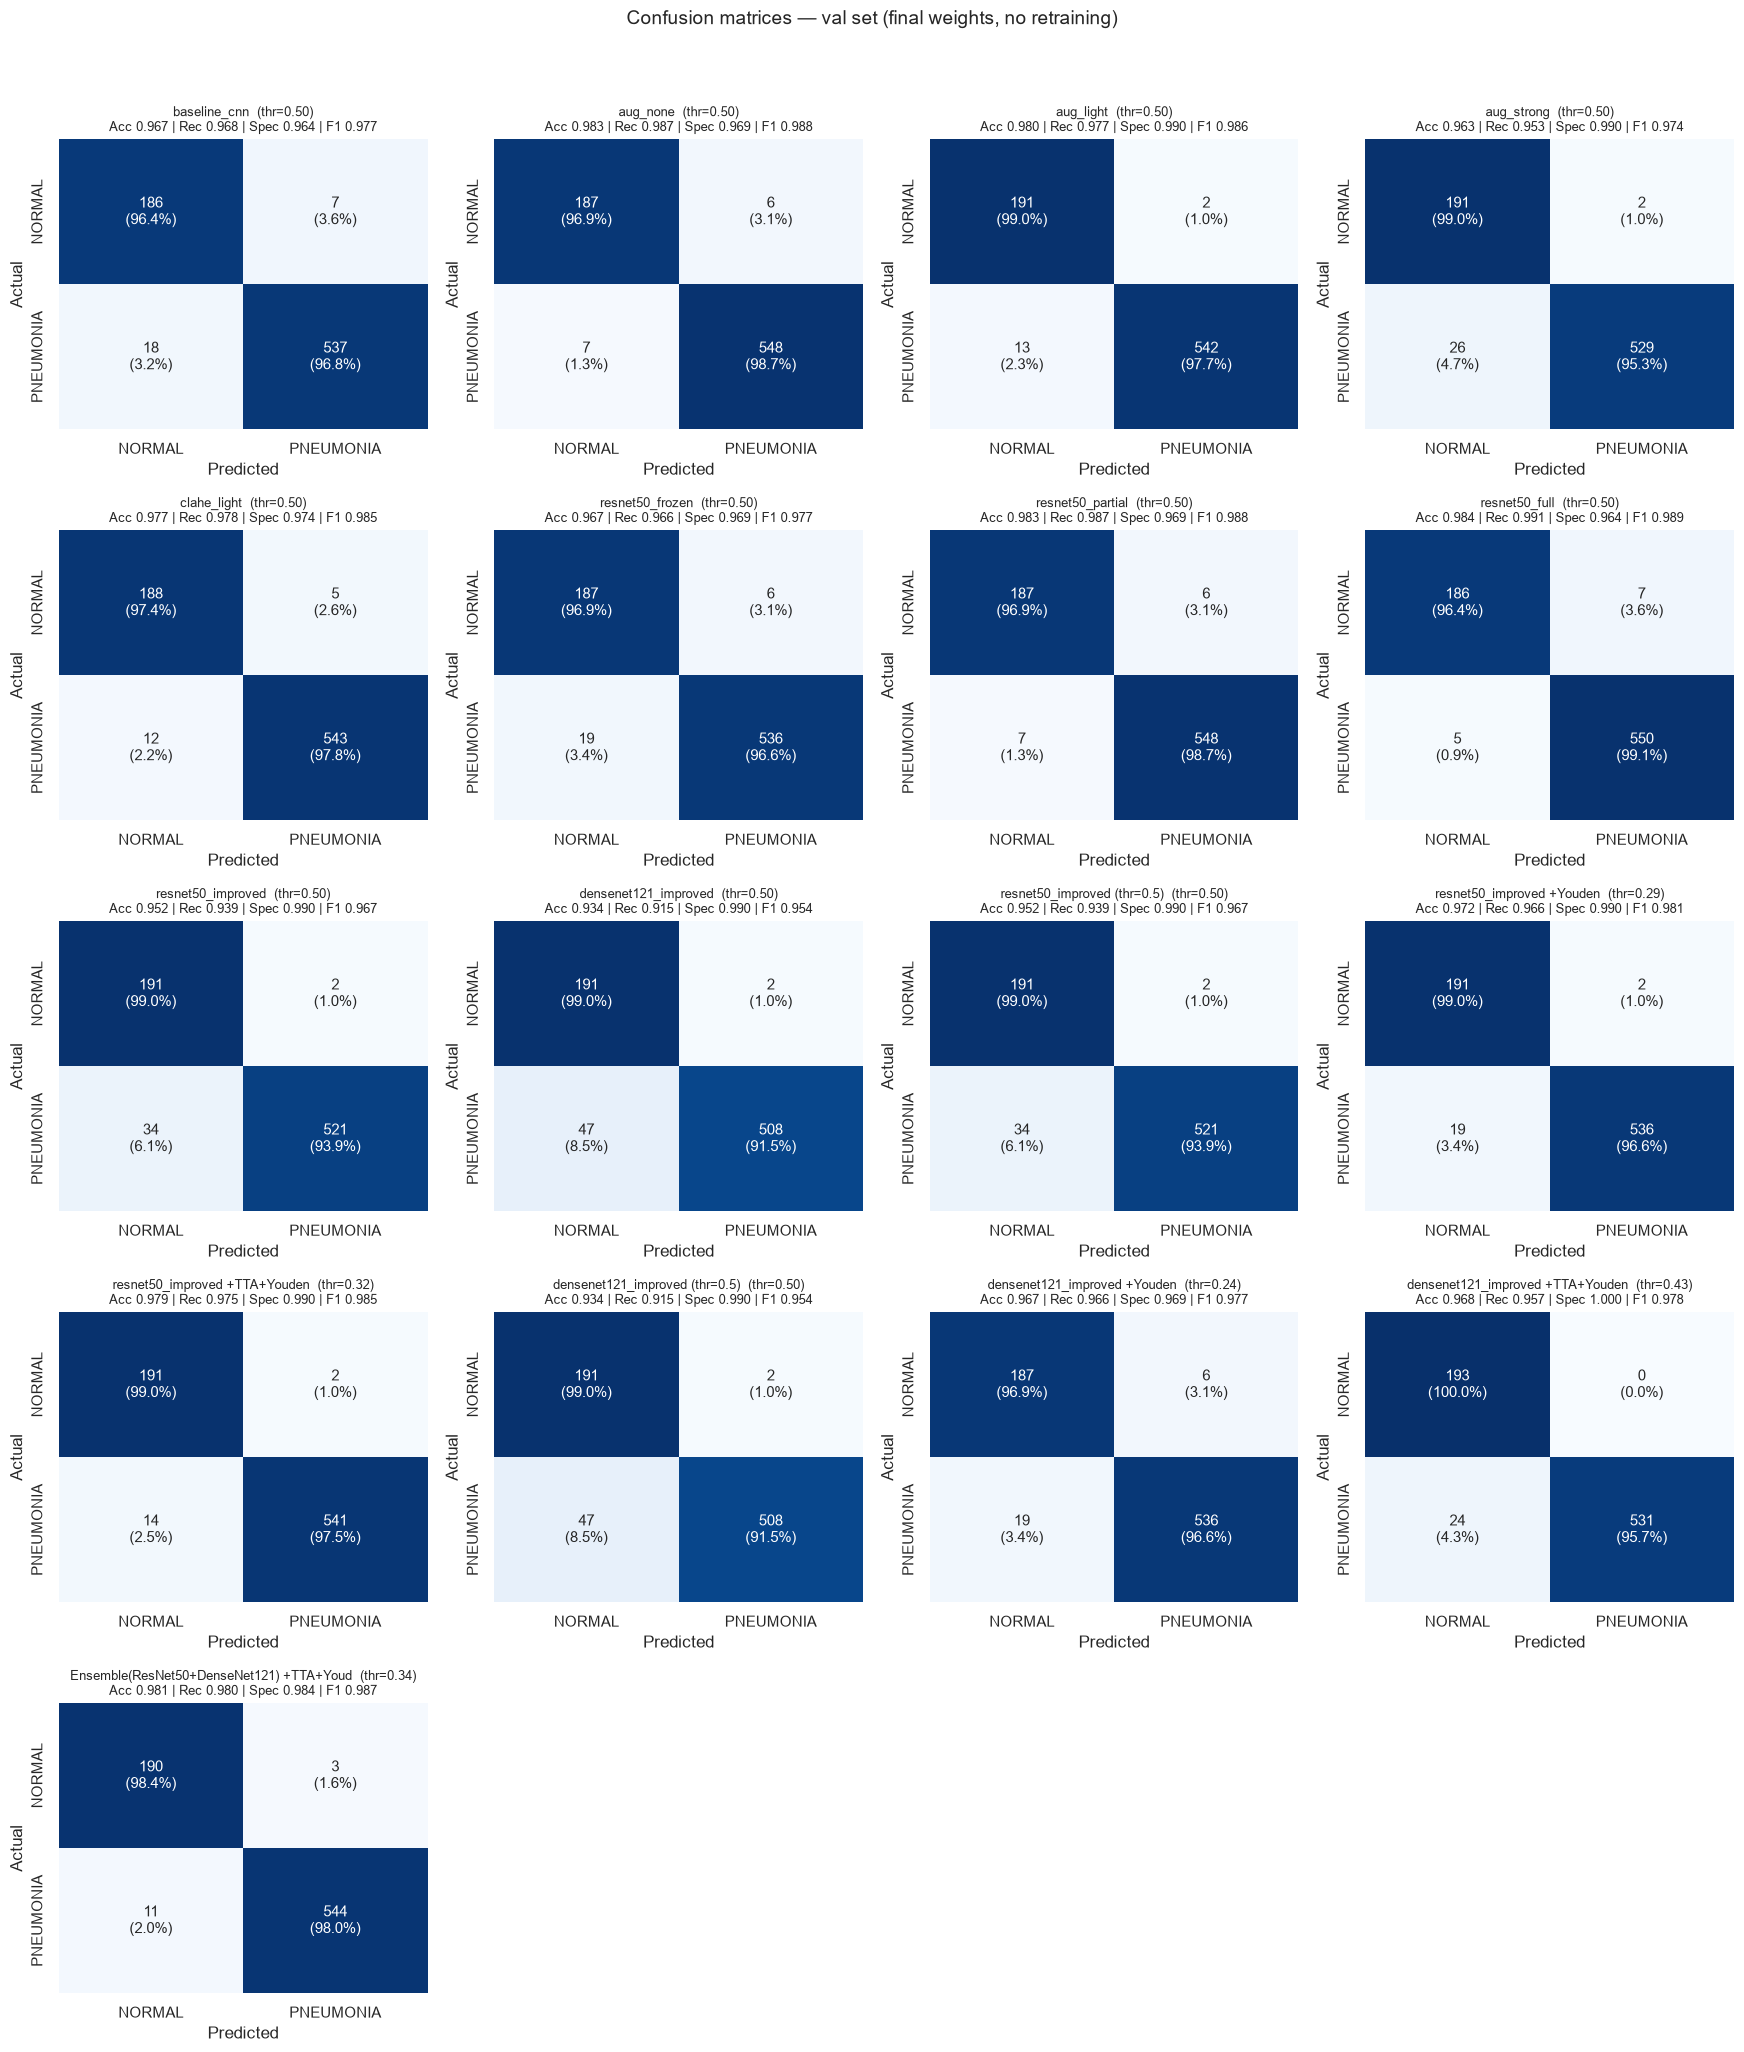

,thr,TN,FP,FN,TP,accuracy,precision,recall,specificity,f1,roc_auc
model,,,,,,,,,,,
baseline_cnn,0.5000,186,7,18,537,0.9666,0.9871,0.9676,0.9637,0.9773,0.9956
aug_none,0.5000,187,6,7,548,0.9826,0.9892,0.9874,0.9689,0.9883,0.9983
aug_light,0.5000,191,2,13,542,0.9799,0.9963,0.9766,0.9896,0.9864,0.9990
aug_strong,0.5000,191,2,26,529,0.9626,0.9962,0.9532,0.9896,0.9742,0.9979
clahe_light,0.5000,188,5,12,543,0.9773,0.9909,0.9784,0.9741,0.9846,0.9979
resnet50_frozen,0.5000,187,6,19,536,0.9666,0.9889,0.9658,0.9689,0.9772,0.9944
resnet50_partial,0.5000,187,6,7,548,0.9826,0.9892,0.9874,0.9689,0.9883,0.9983
resnet50_full,0.5000,186,7,5,550,0.9840,0.9874,0.9910,0.9637,0.9892,0.9981
resnet50_improved,0.5000,191,2,34,521,0.9519,0.9962,0.9387,0.9896,0.9666,0.9971


In [65]:
# 검증셋 기준 혼동행렬 (모델 선택 근거 확인용)
cm_val = plot_confusion_grid(PACK, split="val")
display(cm_val.style.format(precision=4))